# Data Understanding and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
import missingno as msno
from matplotlib.colors import to_hex  
from pandas import IndexSlice as idx
import matplotlib.patches as mpatches
from datetime import datetime
from scipy.stats import skew, kurtosis
from matplotlib.ticker import LogLocator, FuncFormatter
from matplotlib.patches import Rectangle

# Dataset upload

In [3]:
df = pd.read_csv("DM1_game_dataset.csv")
print("Shape:", df.shape)
display(df.head())
df.info()

Shape: (21925, 46)


,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,NaN,NaN,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,NaN,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,NaN,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BGGId                21925 non-null  int64  
 1   Name                 21925 non-null  object 
 2   Description          21924 non-null  object 
 3   YearPublished        21925 non-null  int64  
 4   GameWeight           21925 non-null  float64
 5   ComWeight            21925 non-null  float64
 6   MinPlayers           21925 non-null  int64  
 7   MaxPlayers           21925 non-null  int64  
 8   ComAgeRec            16395 non-null  float64
 9   LanguageEase         16034 non-null  float64
 10  BestPlayers          21925 non-null  int64  
 11  GoodPlayers          21925 non-null  object 
 12  NumOwned             21925 non-null  int64  
 13  NumWant              21925 non-null  int64  
 14  NumWish              21925 non-null  int64  
 15  NumWeightVotes       21925 non-null 

# Check and Removal of Duplicate Records

In [4]:
# Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f"Duplicated rows: {duplicates_count}")
#If duplicates exist, remove them and reset the index
if duplicates_count > 0:
    # drop = True since old index are discarded, not kept as a column
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New DataFrame shape:", df.shape)

Duplicated rows: 0


# Analysis of Missing Values



In [5]:
# --- Calcolo base ---
missing_pct = (df.isna().mean() * 100)
missing_count = df.isna().sum()

# --- Tabella completa (solo colonne con almeno un missing) ---
missing_table = pd.DataFrame({
    "missing_%": missing_pct,
    "missing_count": missing_count
}).sort_values(by="missing_%", ascending=False)

missing_table = missing_table[missing_table["missing_%"] > 0]

# --- Statistiche totali ---
total_rows, total_cols = df.shape
total_missing = int(df.isna().sum().sum())
overall_missing_pct = 100 * total_missing / (total_rows * total_cols)

# Aggiungi riga "TOTAL" in fondo
missing_table.loc["TOTAL"] = [overall_missing_pct, total_missing]

# Index delle sole colonne "reali" (senza TOTAL),
# nello stesso ordine del grafico (ordinato per % decrescente)
non_total_index = missing_table.index.tolist()
non_total_index.remove("TOTAL")

# --- Palette cubehelix blu personalizzata, identica al grafico ---
n = len(non_total_index)
bar_palette = sns.cubehelix_palette(
    start=2.7,
    rot=-0.2,
    light=0.98,
    dark=0.15,
    gamma=0.7,
    n_colors=n
)
bar_palette.reverse()  # come nel barplot: più missing = più scuro

# Mappa indice colonna -> colore
idx_to_color = {
    col_name: to_hex(bar_palette[i])
    for i, col_name in enumerate(non_total_index)
}

def color_missing_column(col: pd.Series):
    """Restituisce uno stile per ogni cella della colonna 'missing_%'."""
    styles = []
    for idx, _ in col.items():
        if idx == "TOTAL":
            styles.append("")  # nessun colore per la riga totale (o scegline uno tu)
        else:
            styles.append(f"background-color: {idx_to_color[idx]}")
    return styles

# --- Styler finale: stessa palette del barplot ---
styled_table = (
    missing_table.style
    .apply(color_missing_column, subset=["missing_%"])   # sfondo blu sulla colonna %
    .format({
        "missing_%": "{:.2f}%",
        "missing_count": "{:,.0f}"
    })
    # testo nero per tutte le righe tranne TOTAL, nella colonna missing_%
    .set_properties(
        subset=idx[missing_table.index != "TOTAL", "missing_%"],
        **{"color": "black"}
    )
    # testo bianco SOLO per TOTAL in missing_%
    .set_properties(
        subset=idx[["TOTAL"], "missing_%"],
        **{"color": "white"}
    )
    # testo bianco per tutta la colonna missing_count (incluso TOTAL)
    .set_properties(
        subset=idx[:, "missing_count"],
        **{"color": "white"}
    )
)

styled_table


,missing_%,missing_count
Family,69.61%,"15,262"
LanguageEase,26.87%,"5,891"
ComAgeRec,25.22%,"5,530"
ImagePath,0.08%,17
Description,0.00%,1
TOTAL,2.65%,"26,701"


## Missing Values Visualization

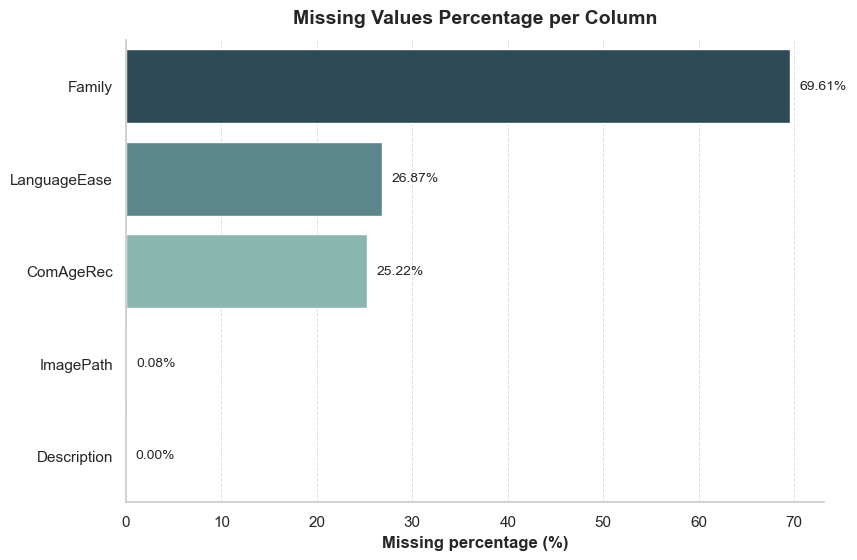

<Figure size 1000x800 with 0 Axes>

In [6]:
def plot_missing_percentages(
    data: pd.DataFrame,
    title: str = "Missing values per column",
    figsize: tuple = (9, 6)
) -> None:
    """
    Plot the percentage of missing values for each column (horizontal bar plot).
    Darker bars correspond to higher missing percentages.
    """

    # Compute missing percentages
    missing_pct = data.isna().mean() * 100
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

    if missing_pct.empty:
        print("No missing values found in the dataset.")
        return

    # ---- global summary ----
    n_rows, n_cols = data.shape
    total_missing_cells = int(data.isna().sum().sum())
    overall_missing_pct = 100 * total_missing_cells / (n_rows * n_cols)

    sns.set_theme(style="whitegrid")

    # ---- Cubehelix blu personalizzata ----
    n = len(missing_pct)
    bar_palette = sns.cubehelix_palette(
        start=2.7,   # blu puro
        rot=-0.2,    # quasi monocromatica
        light=0.98,
        dark=0.15,
        gamma=0.7,
        n_colors=n
    )
    bar_palette.reverse()  # barra più scura = più missing

    fig, ax = plt.subplots(figsize=figsize)

    # Prepare df for seaborn
    df_plot = missing_pct.reset_index()
    df_plot.columns = ["column", "missing_pct"]

    # Assign hue = column to avoid the FutureWarning
    sns.barplot(
        data=df_plot,
        x="missing_pct",
        y="column",
        hue="column",
        palette=bar_palette,
        dodge=False,
        ax=ax,
        legend=False
    )

    # Label each bar with its value
    for i, row in df_plot.iterrows():
        ax.text(
            row["missing_pct"] + 1,
            i,
            f"{row['missing_pct']:.2f}%",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="medium"
        )

    # Styling
    ax.set_xlabel("Missing percentage (%)", fontsize=12, fontweight="bold")
    ax.set_ylabel("")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.xaxis.set_ticks_position("none")

    plt.figure(figsize=(10, 8))
    plt.tight_layout()
    plt.show()

plot_missing_percentages(df, title="Missing Values Percentage per Column")

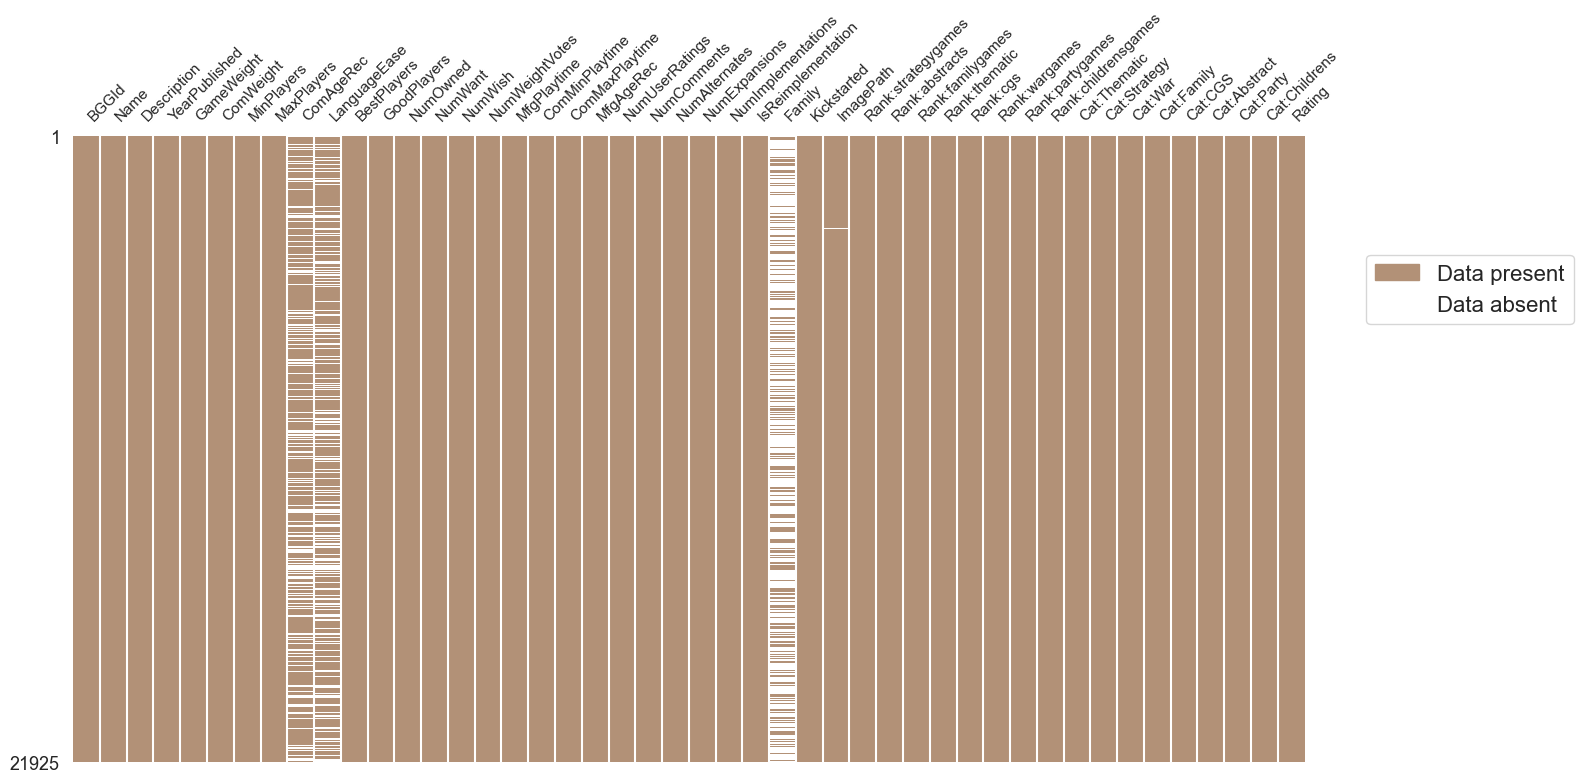

In [7]:
# Visualizza la matrice dei valori mancanti con missingno
msno.matrix(df, sparkline=False, figsize=(16,8), fontsize=11, color=(0.7, 0.57, 0.47))

# Aggiungi una legenda personalizzata per i colori di missingno
gray_patch = mpatches.Patch(color='#B29177', label='Data present')  # Colore per dati presenti
white_patch = mpatches.Patch(color='white', label='Data absent')  # Colore per dati assenti

# Aggiungi la legenda sul lato destro
plt.legend(loc=[1.05, 0.7], handles=[gray_patch, white_patch], fontsize=16)

# Mostra il grafico
plt.tight_layout()
plt.show()

## Correlation of Missing Values

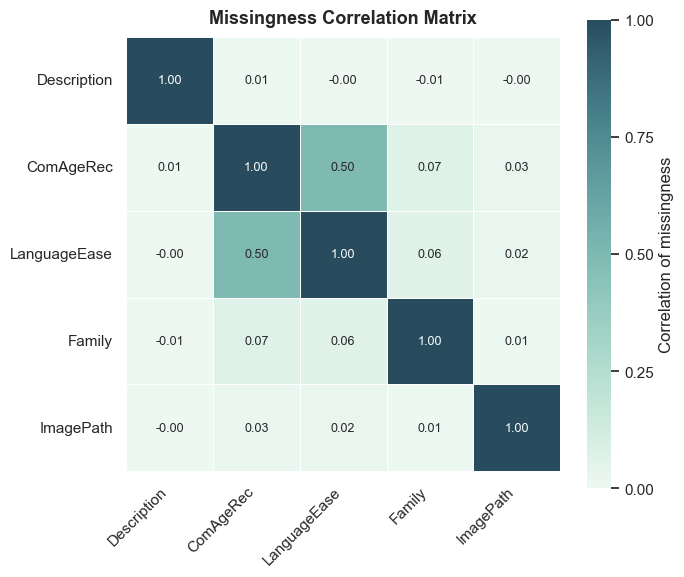

In [8]:
def plot_missing_correlation(
    data: pd.DataFrame,
    title: str = "Missingness correlation matrix",
    figsize: tuple = (7, 6)
) -> None:
    """
    Plot the correlation matrix of missingness between columns,
    with numerical values and colorbar in the range 0–1.
    """
    # Compute missing mask and keep only columns with missing values
    missing_mask = data.isna()
    missing_pct = missing_mask.mean()
    cols_with_missing = missing_pct[missing_pct > 0].index.tolist()

    if len(cols_with_missing) < 2:
        print("Need at least two columns with missing values for a correlation matrix.")
        return

    sub_missing = missing_mask[cols_with_missing].astype(int)

    # Correlation in [0, 1] for missingness
    corr = sub_missing.corr().round(2)

    sns.set_theme(style="white")

    # ---- Cubehelix BLU personalizzato ----
    chroma_palette = sns.cubehelix_palette(
    start=2.7,   # tono blu
    rot=-0.2,    # poca rotazione, palette "quasi monocromatica"
    light=0.94,  # bianco → blu
    dark=0.15,   # blu scuro
    gamma=0.7,
    n_colors=256
    )
    corr_cmap = ListedColormap(chroma_palette)

    fig, ax = plt.subplots(figsize=figsize)

    # Heatmap da 0 → 1, NO percentuali
    hm = sns.heatmap(
        corr,
        ax=ax,
        cmap=corr_cmap,
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 9},
        cbar_kws={"label": "Correlation of missingness"},
        xticklabels=cols_with_missing,
        yticklabels=cols_with_missing,
        square=True,
        linewidths=0.5,
        linecolor="white",
        vmin=0,
        vmax=1
    )

    # Fix colorbar ticks 0 → 1
    cbar = hm.collections[0].colorbar
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])

    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

plot_missing_correlation(df, title="Missingness Correlation Matrix")

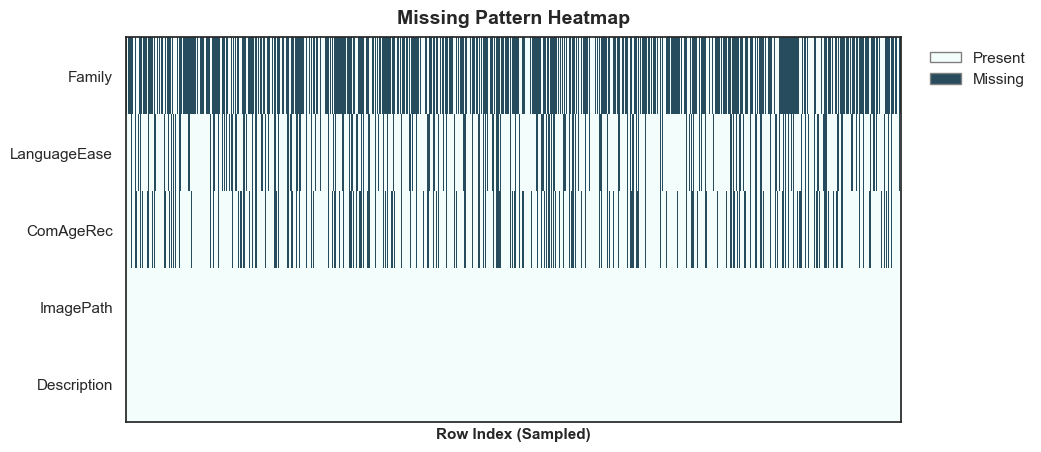

<Figure size 1000x800 with 0 Axes>

In [9]:
def plot_missing_pattern(
    data: pd.DataFrame,
    title: str = "Missing Pattern Heatmap",
    max_rows: int = 2000,
    figsize: tuple = (10, 5)
) -> None:
    """
    Binary heatmap of missing values:
    - y-axis: columns (ordered by % missing, descending)
    - x-axis: rows (sampled if too many)
    0 = Present, 1 = Missing
    """
    # Mask e percentuali
    missing_mask = data.isna()
    missing_pct = missing_mask.mean() * 100

    cols_with_missing = missing_pct[missing_pct > 0].index.tolist()
    if not cols_with_missing:
        print("No missing values found in the dataset.")
        return

    # Ordine coerente: dal più mancante al meno mancante
    cols_with_missing = (
        missing_pct[cols_with_missing]
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    # Subset e sampling righe
    sub_missing = missing_mask[cols_with_missing]
    if len(sub_missing) > max_rows:
        sub_missing = sub_missing.sample(max_rows, random_state=42).sort_index()

    sub_missing_int = sub_missing.astype(int)  # 0 = present, 1 = missing

    sns.set_theme(style="white")

    # --- Colori coerenti con il resto delle tue visualizzazioni ---
    cube_pal = sns.cubehelix_palette(
        start=2.7, rot=-0.2, light=0.98, dark=0.15, gamma=0.7, n_colors=256
    )
    missing_color = cube_pal[-1]        # blu scuro
    present_color = "#f3fdfb"           # azzurro chiaro (ma visibile sul bianco)

    binary_cmap = ListedColormap([present_color, missing_color])

    # Matrice per imshow (colonne sulle righe)
    mat = sub_missing_int.to_numpy().T   # shape: (n_cols_missing, n_rows_sampled)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        mat,
        cmap=binary_cmap,
        vmin=0,
        vmax=1,
        aspect="auto",
        interpolation="nearest"
    )

    # Etichette assi
    ax.set_yticks(np.arange(len(cols_with_missing)))
    ax.set_yticklabels(cols_with_missing)
    ax.set_xticks([])  # troppi punti, niente tick

    ax.set_xlabel("Row Index (Sampled)", fontsize=11, fontweight="bold")
    ax.set_ylabel("")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=10)

    # --- Legenda custom Present / Missing ---
    present_patch = plt.Rectangle((0, 0), 1, 1, facecolor=present_color, edgecolor="gray")
    missing_patch = plt.Rectangle((0, 0), 1, 1, facecolor=missing_color, edgecolor="gray")

    ax.legend(
        handles=[present_patch, missing_patch],
        labels=["Present", "Missing"],
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=False,
        fontsize=11
    )

    plt.figure(figsize=(10, 8))
    plt.tight_layout()
    plt.show()

plot_missing_pattern(df, title="Missing Pattern Heatmap", max_rows=2000)

The heatmap of missing value correlations provides insights into how missing values are distributed across different columns:

1. **Low Correlation Between Most Columns**:
   - The heatmap shows that there is generally **low correlation** between missing values in different columns. Most of the cells are white or light-colored, indicating that when a value is missing in one column, it is **not strongly related** to missing values in other columns.

2. **Independent Missingness**:
   - This suggests that the **missing values** in different columns are mostly **independent** of each other. For example, missing values in `ComAgeRec` are not systematically linked to missing values in `LanguageEase` or other variables.

3. **Weak Positive Correlations**:
   - A few columns, like `LanguageEase` and `ComAgeRec`, show a **moderate positive correlation** in their missing values (around 0.5). This implies that when one column has missing values, the other is somewhat more likely to have missing values as well, but the correlation is **not strong** (far from 1).

4. **No Strong Patterns**:
   - Overall, the heatmap reveals that there are **no strong patterns** of missing values across the dataset. The missingness in one column does not seem to predict missingness in others, which suggests that the missing data is distributed **randomly** across columns.

**Conclusion**:
The missing values in this dataset appear to be mostly **independent** of each other, with only a few moderate correlations between some columns. This means that there are no major dependencies or patterns of missingness that would suggest a need for joint treatment of missing data across multiple columns.


###  `Family`

Poiché Family ha una percentuale molto alta di valori mancanti, qui analizziamo per ciascuna categoria di Family quanti missing totali (su tutte le colonne) sono presenti. Questo ci aiuta a capire se alcune famiglie di giochi sono sistematicamente meno documentate di altre.

In [10]:
def describe_family(
    data: pd.DataFrame,
    col: str = "Family",
    top_n: int = 20,
    rare_threshold: float = 0.01
) -> pd.DataFrame:
    """
    Descriptive analysis of a categorical attribute (default: 'Family').

    Reports (structured in blocks):
    A. Missingness overview:
       - number and percentage of non-missing and missing values
    B. Distribution of non-missing values:
       - number of unique non-missing categories
       - average number of rows per category
    C. Top-N coverage:
       - top `top_n` categories (count + percentage over all rows)
       - cumulative coverage of the top `top_n` categories
    D. Rarity analysis:
       - number of "rare" categories (freq < `rare_threshold`)
       - combined percentage of rows in rare categories

    Returns
    -------
    top_df : pd.DataFrame
        DataFrame with columns:
        ['category', 'count', 'frequency_pct'] for the top `top_n` categories.
    """

    if col not in data.columns:
        raise KeyError(f"Column '{col}' not found in the DataFrame.")

    s = data[col]

    n_rows = len(s)
    n_missing = s.isna().sum()
    n_nonmissing = n_rows - n_missing

    missing_pct = 100 * n_missing / n_rows if n_rows > 0 else 0.0
    nonmissing_pct = 100 * n_nonmissing / n_rows if n_rows > 0 else 0.0

    unique_nonmissing = s.dropna().nunique()
    avg_rows_per_cat = n_nonmissing / unique_nonmissing if unique_nonmissing > 0 else np.nan

    print(f"=== Descriptive summary for '{col}' ===\n")

    # --- A. Missingness overview ------------------------------------------------
    print("A. Missingness overview")
    print(f"Total rows: {n_rows:,}")
    missing_summary = pd.DataFrame(
        {
            "Count": [n_nonmissing, n_missing],
            "Percentage of all rows": [f"{nonmissing_pct:.2f}%", f"{missing_pct:.2f}%"],
        },
        index=["Non-missing values", "Missing values"],
    )
    display(missing_summary)
    print()

    # --- B. Distribution of non-missing values ----------------------------------
    print("B. Distribution of non-missing values")
    dist_summary = pd.DataFrame(
        {
            "Value": [
                f"{unique_nonmissing:,}",
                f"{avg_rows_per_cat:.2f}" if not np.isnan(avg_rows_per_cat) else "NA",
            ]
        },
        index=[
            "Unique non-missing categories",
            "Average rows per category",
        ],
    )
    display(dist_summary)
    print()

    # --- C. Top-N coverage ------------------------------------------------------
    # Value counts for non-missing categories
    vc = s.dropna().value_counts()
    vc_pct = vc / n_rows * 100  # percentages over all rows

    top_n = min(top_n, len(vc))
    top_df = (
        pd.DataFrame(
            {
                "category": vc.index,
                "count": vc.values,
                "frequency_pct": vc_pct.values,
            }
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    print(f"C. Top-{top_n} category coverage")
    display(top_df)
    top_total_count = int(top_df["count"].sum())
    top_total_pct = float(top_df["frequency_pct"].sum())
    print(
        f"The top {top_n} categories account for "
        f"{top_total_count:,} rows "
        f"({top_total_pct:.2f}% of the entire dataset)."
    )
    print()

    # --- D. Rarity analysis ------------------------------------------------------
    print("D. Rarity analysis")
    # rare_threshold is defined on the fraction (e.g. 0.01 = 1%)
    rare_mask = (vc / n_rows) < rare_threshold
    n_rare_categories = int(rare_mask.sum())

    if n_rare_categories > 0:
        rare_total_pct = float(vc_pct[rare_mask].sum())
        rare_summary = pd.DataFrame(
            {
                "Value": [
                    f"{n_rare_categories:,}",
                    f"{rare_total_pct:.2f}%",
                ]
            },
            index=[
                "Number of rare categories",
                "Combined percentage of rows in rare categories",
            ],
        )
        display(rare_summary)
    else:
        print(
            f"No categories with frequency below "
            f"{rare_threshold*100:.2f}% of all rows."
        )

    return top_df

top_family = describe_family(df, col="Family", top_n=20, rare_threshold=0.01)

=== Descriptive summary for 'Family' ===

A. Missingness overview
Total rows: 21,925


,Count,Percentage of all rows
Non-missing values,6663,30.39%
Missing values,15262,69.61%



B. Distribution of non-missing values


,Value
Unique non-missing categories,"1,456"
Average rows per category,4.58



C. Top-20 category coverage


,category,count,frequency_pct
0,18xx,103,0.469783
1,Monopoly (Official),73,0.332953
2,Trivial Pursuit,67,0.305587
3,Werewolf / Mafi,58,0.264538
4,Wallet Games (Button Shy),45,0.205245
5,Two-player games (Kosmos),44,0.200684
6,"Cluedo / Clue (Parker Brothers, et al)",42,0.191562
7,Munchkin,41,0.187001
8,UNO,39,0.177879
9,Monopoly-Lik,39,0.177879


The top 20 categories account for 867 rows (3.95% of the entire dataset).

D. Rarity analysis


,Value
Number of rare categories,"1,456"
Combined percentage of rows in rare categories,30.39%


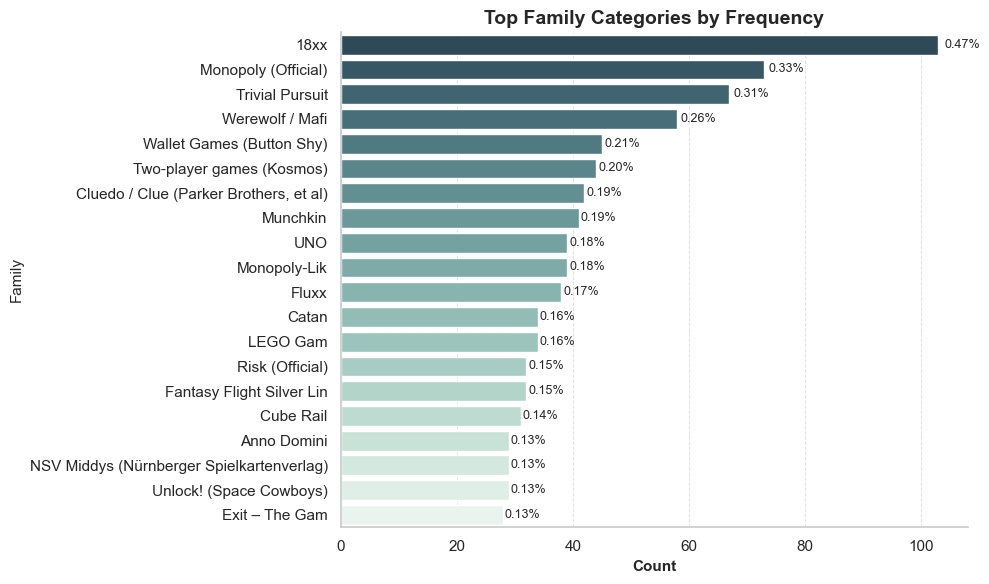

In [11]:
def plot_family_category_frequencies(
    data: pd.DataFrame,
    col: str = "Family",
    top_n: int = 20,
    figsize: tuple = (10, 6),
    title: str = "Top Family Categories by Frequency"
) -> None:
    """
    Plot the Top-N most frequent categories of `col` (default: 'Family').

    - Bars represent the absolute count of each category.
    - Text labels report the percentage (%) over all rows
      (including missing values in `col`).

    This visualization is useful to show how fragmented the distribution is
    and how rare even the most frequent categories are.
    """

    if col not in data.columns:
        raise KeyError(f"Column '{col}' not found in the DataFrame.")

    s = data[col]
    n_rows = len(s)

    vc = s.dropna().value_counts()
    if vc.empty:
        print(f"No non-missing values found in '{col}'.")
        return

    vc_pct = vc / n_rows * 100  # percentages over all rows

    top_n = min(top_n, len(vc))
    top = (
        pd.DataFrame(
            {
                "category": vc.index,
                "count": vc.values,
                "frequency_pct": vc_pct.values,
            }
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    sns.set_theme(style="whitegrid")

    palette = sns.cubehelix_palette(
        start=2.7,
        rot=-0.2,
        light=0.92,
        dark=0.15,
        gamma=0.7,
        n_colors=top_n,
        reverse=True,
    )

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=top,
        x="count",
        y="category",
        hue="category",
        palette=palette,
        dodge=False,
        legend=False,
        ax=ax,
    )

    for i, row in top.iterrows():
        ax.text(
            row["count"] * 1.01,
            i,
            f"{row['frequency_pct']:.2f}%",
            va="center",
            ha="left",
            fontsize=9,
        )

    ax.set_xlabel("Count", fontsize=11, fontweight="bold")
    ax.set_ylabel(col, fontsize=11)
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.xaxis.set_ticks_position("none")

    plt.tight_layout()
    plt.show()


plot_family_category_frequencies(df, col="Family", top_n=20)

In [12]:
def drop_family_column(data: pd.DataFrame, col: str = "Family") -> pd.DataFrame:
    """
    Remove the 'Family' column from the dataset, if present.
    Prints a simple confirmation message.
    """
    
    if col not in data.columns:
        print(f"Column '{col}' not found. Nothing to remove.")
        return data.copy()

    data_new = data.drop(columns=[col]).copy()
    print("Family attribute removed successfully.")
    return data_new

df = drop_family_column(df)

Family attribute removed successfully.


# `Cat:*` and `Rank:*`

To investigate the relationship between the category variables (Cat:*) and the ranking variables (Rank:*), we computed the Spearman rank correlation between every pair of Cat and Rank features.

The variables are:

- All Cat:* one-hot encoded category indicators.

- All Rank:* numerical ranking features.

The analysis proceeded as follows:

1) **Computation of correlation**

Spearman’s ρ was used because Rank features are ordinal and Cat features are binary, making it the most appropriate non-parametric measure.

2) **Visualization**

- A table listing only |ρ| ≥ 0.9, highlighting extremely strong monotonic relationships.

- A heatmap displaying the full Rank × Cat correlation matrix.

This approach allows us to detect redundancy, perfect or near-perfect inversions, and general structural dependencies between categorical labels and ranking metadata.

In [13]:
def get_strong_rank_cat_correlations(
    data: pd.DataFrame,
    rank_prefix: str = "Rank:",
    cat_prefix: str = "Cat:",
    threshold: float = 0.9,
    sort_by_abs: bool = True
) -> pd.DataFrame:
    """
    Build a clean table of strong Spearman correlations between Rank:* and Cat:* features.

    - Selects columns starting with rank_prefix and cat_prefix
    - Computes Spearman correlation
    - Keeps only pairs with |rho| >= threshold
    - Returns a long-format table without extra index column

    Parameters
    ----------
    data : pd.DataFrame
        Input dataset.
    rank_prefix : str
        Prefix for Rank columns (default: "Rank:").
    cat_prefix : str
        Prefix for Cat dummy columns (default: "Cat:").
    threshold : float
        Minimum absolute correlation to keep (default: 0.9).
    sort_by_abs : bool
        If True, sort by absolute correlation; otherwise by raw rho.

    Returns
    -------
    pd.DataFrame
        Table with columns: ['rank_feature', 'cat_feature', 'spearman_corr'].
    """

    # --- Select columns ---
    rank_cols = [c for c in data.columns if c.startswith(rank_prefix)]
    cat_cols  = [c for c in data.columns if c.startswith(cat_prefix)]

    if not rank_cols:
        raise ValueError("No Rank:* columns found.")
    if not cat_cols:
        raise ValueError("No Cat:* columns found.")

    # Ensure numeric
    df_rank = data[rank_cols].apply(pd.to_numeric, errors="coerce")
    df_cat  = data[cat_cols].apply(pd.to_numeric, errors="coerce")

    # Combined DF and full Spearman correlation
    combined = pd.concat([df_rank, df_cat], axis=1)
    corr_full = combined.corr(method="spearman")

    # Submatrix Rank vs Cat
    corr = corr_full.loc[rank_cols, cat_cols]

    # Long format
    corr_long = (
        corr.reset_index()
            .melt(
                id_vars="index",
                value_vars=cat_cols,
                var_name="cat_feature",
                value_name="spearman_corr"
            )
            .rename(columns={"index": "rank_feature"})
    )

    # --- Filter strong correlations ---
    # Se vuoi SOLO positive: usa (corr_long["spearman_corr"] >= threshold)
    mask = corr_long["spearman_corr"].abs() >= threshold
    corr_strong = corr_long[mask].copy()

    # Sorting
    if sort_by_abs:
        corr_strong["abs_corr"] = corr_strong["spearman_corr"].abs()
        corr_strong = corr_strong.sort_values("abs_corr", ascending=False)
        corr_strong = corr_strong.drop(columns=["abs_corr"])
    else:
        corr_strong = corr_strong.sort_values("spearman_corr", ascending=False)

    # Reset index to remove side numbers
    corr_strong = corr_strong.reset_index(drop=True)

    return corr_strong
strong_corr = get_strong_rank_cat_correlations(df, threshold=0.9)
strong_corr

,rank_feature,cat_feature,spearman_corr
0,Rank:cgs,Cat:CGS,-0.999968
1,Rank:partygames,Cat:Party,-0.999854
2,Rank:childrensgames,Cat:Childrens,-0.999720
3,Rank:abstracts,Cat:Abstract,-0.999546
4,Rank:thematic,Cat:Thematic,-0.999450
5,Rank:familygames,Cat:Family,-0.997927
6,Rank:strategygames,Cat:Strategy,-0.997921
7,Rank:wargames,Cat:War,-0.994890


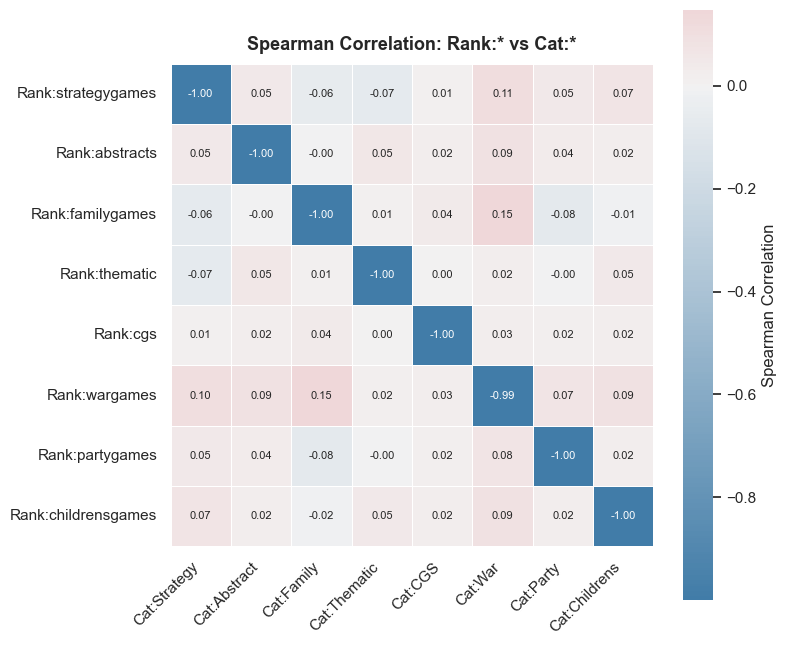

In [14]:
def plot_spearman_rank_cat_reordered(
    data: pd.DataFrame,
    rank_prefix: str = "Rank:",
    cat_prefix: str = "Cat:",
    title: str = "Spearman Correlation: Rank:* vs Cat:*",
    figsize: tuple = (8, 7)
) -> pd.DataFrame:
    """
    Compute and plot the Spearman correlation matrix between Rank:* and Cat:* columns.

    The columns (Cat:*) are reordered so that, for each Rank:* row, the
    column on the diagonal is the one with the largest absolute correlation.

    - Square heatmap
    - Thin white grid separators
    - Diverging palette for positive/negative correlations
    """

    # --- Select columns ---
    rank_cols = [c for c in data.columns if c.startswith(rank_prefix)]
    cat_cols  = [c for c in data.columns if c.startswith(cat_prefix)]

    if not rank_cols:
        raise ValueError("No Rank:* columns found.")
    if not cat_cols:
        raise ValueError("No Cat:* columns found.")

    # Numeric conversion
    df_rank = data[rank_cols].apply(pd.to_numeric, errors="coerce")
    df_cat  = data[cat_cols].apply(pd.to_numeric, errors="coerce")

    # Compute correlation
    combined = pd.concat([df_rank, df_cat], axis=1)
    corr_full = combined.corr(method="spearman")

    # Extract Rank vs Cat submatrix
    corr = corr_full.loc[rank_cols, cat_cols]

    # --- Reorder Cat:* columns to align strongest correlations on the diagonal ---
    used_cols = set()
    new_cat_order = []

    for r in rank_cols:
        # serie con le corr della riga r su tutte le Cat:*
        s = corr.loc[r].abs().copy()

        # escludi col già usate
        s = s.drop(labels=list(used_cols), errors="ignore")

        if s.empty:
            # se abbiamo finito le colonne "libere", interrompi
            break

        best_cat = s.idxmax()
        used_cols.add(best_cat)
        new_cat_order.append(best_cat)

    # aggiungi eventuali Cat:* non ancora usate in fondo
    remaining = [c for c in cat_cols if c not in used_cols]
    new_cat_order.extend(remaining)

    # riordina la matrice
    corr_reordered = corr[new_cat_order]

    # --- Plot ---
    cmap = sns.diverging_palette(240, 10, as_cmap=True)

    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=figsize)

    hm = sns.heatmap(
        corr_reordered,
        ax=ax,
        cmap=cmap,
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 8},
        xticklabels=new_cat_order,
        yticklabels=rank_cols,
        square=True,
        linewidths=0.5,
        linecolor="white",
        center=0,
        cbar_kws={"label": "Spearman Correlation"}
    )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

    return corr_reordered

spearman_corr_reordered = plot_spearman_rank_cat_reordered(df)



These correlations are essentially perfect, meaning:

- Whenever Cat:* = 1, the corresponding Rank:* almost uniquely determines the same information.

- One feature is a deterministic (or nearly deterministic) transformation of the other.

- Keeping both introduces strong multicollinearity, destabilizing many models (e.g., linear models, distance-based models).

The Cat: variables encode the intrinsic thematic categories of each game (e.g., War, Strategy, Abstract).
These binary indicators directly describe what a game is in terms of genre and mechanics, making them meaningful for clustering, pattern mining, and general predictive modeling.

Conversely, the Rank: variables represent the community-driven ranking of each game within those same categories. Since rankings are defined only for games belonging to that category, Rank: and Cat: are almost perfectly correlated (|ρ| ≈ 1). This makes the Rank variables redundant and unsuitable for algorithms that assume independent features. Additionally, rankings capture popularity—not intrinsic game attributes—so they would distort clustering structure and association patterns.

For these reasons, **we retain the Cat: features and remove all Rank: features from the dataset**.

In [15]:
def drop_rank_features(data: pd.DataFrame, rank_prefix: str = "Rank:") -> pd.DataFrame:
#     """
#     Remove all Rank:* features from the dataset.

#     Parameters
#     ----------
#     data : pd.DataFrame
#         Input dataset.
#     rank_prefix : str
#         Prefix used to identify Rank columns (default: "Rank:").

#     Returns
#     -------
#     pd.DataFrame
#         Dataset without Rank:* columns.
#     """
#     # Identify rank columns
    rank_cols = [c for c in data.columns if c.startswith(rank_prefix)]

    if not rank_cols:
        print("No Rank:* columns found — nothing was removed.")
        return data.copy()

     # Drop them
    new_data = data.drop(columns=rank_cols).copy()

    print(f"Removed {len(rank_cols)} Rank:* columns successfully.")
    return new_data


 # Example usage:
df = drop_rank_features(df)

Removed 8 Rank:* columns successfully.


## `Cat:*`: Further Analysis

To better understand the distribution of game categories, we performed a focused analysis of all Cat:* variables.
The procedure consisted of:

**1) Summarizing each Cat:feature by counting how many games belong to that category, with also the percentage over the full dataset**

**2) Visualizing the most common categories through a bar chart to highlight dominant vs. minor categories**

This allows us to assess the relevance, stability, and statistical presence of each category and identify potentially rare or uninformative features.


In [16]:
def summarize_cat(data: pd.DataFrame, prefix: str = "Cat:") -> pd.DataFrame:
    """
    Summarize all dummy columns starting with 'Cat:'.
    Returns count and percentage of 1s for each dummy.
    """
    cat_cols = [c for c in data.columns if c.startswith(prefix)]
    if not cat_cols:
        raise ValueError(f"No columns starting with '{prefix}' found.")

    n = len(data)
    summary = []

    for c in cat_cols:
        s = data[c].fillna(0)
        count_1 = int((s == 1).sum())
        pct_1 = 100 * count_1 / n

        summary.append({
            "Cat:*": c,
            "count": count_1,
            "percentage_%": pct_1,
        })

    summary = pd.DataFrame(summary)
    summary = summary.sort_values("percentage_%", ascending=False).reset_index(drop=True)
    return summary

summary_cat = summarize_cat(df, prefix="Cat:")
summary_cat

,Cat:*,count,percentage_%
0,Cat:War,3530,16.100342
1,Cat:Strategy,2319,10.576967
2,Cat:Family,2316,10.563284
3,Cat:Thematic,1224,5.582668
4,Cat:Abstract,1115,5.085519
5,Cat:Childrens,881,4.018244
6,Cat:Party,640,2.919042
7,Cat:CGS,303,1.381984


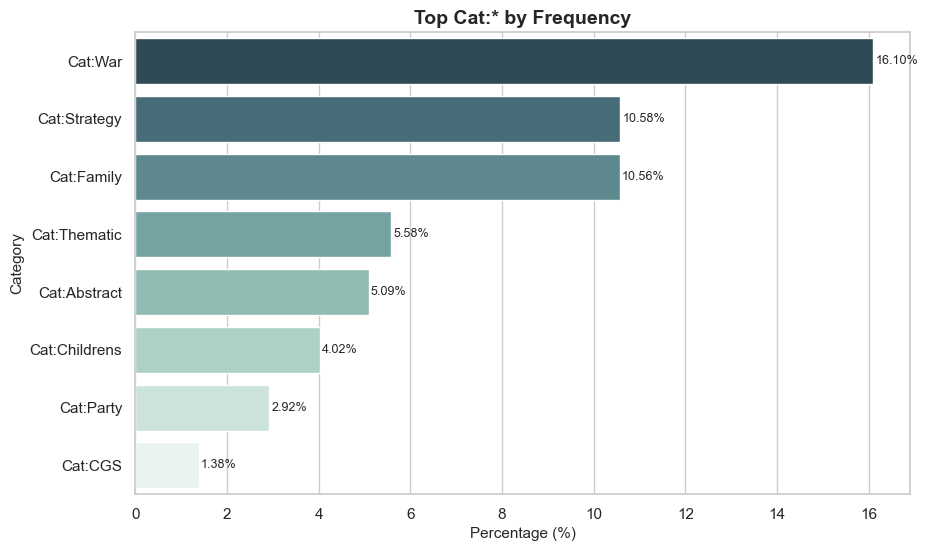

<Figure size 1000x800 with 0 Axes>

In [17]:
def plot_cat_frequencies(data: pd.DataFrame, prefix: str = "Cat:", top_n: int = 20):
    """
    Plot the top-N most frequent Cat:* dummy columns.
    Fixed seaborn FutureWarning by assigning hue=y and disabling legend.
    """

    # Get Cat:* summary
    summary = summarize_cat(data, prefix)
    top = summary.head(top_n)

    sns.set_theme(style="whitegrid")
    palette = sns.cubehelix_palette(
        start=2.7, rot=-0.2, light=0.92, dark=0.15,
        gamma=0.7, n_colors=top_n, reverse=True
    )

    plt.figure(figsize=(10, 6))

    # FIXED: assign hue="Cat:*" and disable legend
    sns.barplot(
        data=top,
        x="percentage_%", 
        y="Cat:*",
        hue="Cat:*",
        palette=palette,
        dodge=False,
        legend=False
    )

    # Add percentage labels
    for i, row in top.iterrows():
        plt.text(
            row["percentage_%"] + 0.05,  # small horizontal offset
            i,
            f"{row['percentage_%']:.2f}%",
            va="center",
            fontsize=9
        )

    plt.xlabel("Percentage (%)", fontsize=11)
    plt.ylabel("Category", fontsize=11)
    plt.title("Top Cat:* by Frequency", fontsize=14, fontweight="bold")

    plt.figure(figsize=(10, 8))
    plt.tight_layout()
    plt.show()

plot_cat_frequencies(df, prefix="Cat:", top_n=8)

# `ComAgeRec`

`ComAgeRec`is a continuous numerical attribute representing the community-recommended minimum age for a game.  
Because the feature contains a substantial amount of missing values (25.22%, 5,530 records), an informed imputation strategy is required.

Before deciding how to fill the missing values, we investigate whether recommended age varies across game categories (`Cat:*`).  
If age recommendations differ significantly between categories, imputing with a single global value would remove meaningful structure.

To assess this, we compute for each `Cat:*`:

- the median of `ComAgeRec`,
- the number of non-missing observations.

A visual comparison of medians allows us to understand whether categories naturally cluster around different recommended ages (e.g., `Cat:Childrens` vs. `Cat:War`).  
Large differences across groups imply that category-aware imputation is preferable over a global approach.

In [18]:
def summarize_comagerec_by_cat(data: pd.DataFrame, prefix: str = "Cat:") -> pd.DataFrame:
    """
    Compute median, IQR and std of ComAgeRec for each Cat:* dummy feature.
    """
    cat_cols = [c for c in data.columns if c.startswith(prefix)]
    results = []

    for col in cat_cols:
        subset = data.loc[data[col] == 1, "ComAgeRec"].dropna()

        if subset.empty:
            continue

        median = subset.median()
        iqr = subset.quantile(0.75) - subset.quantile(0.25)
        std = subset.std()
        count = subset.shape[0]

        results.append({
            "Category": col,
            "median_ComAgeRec": median,
            "IQR": iqr,
            "std": std,
            "non_missing_count": count
        })

    summary = pd.DataFrame(results)
    summary = summary.sort_values("median_ComAgeRec", ascending=False).reset_index(drop=True)
    return summary

summary_stats = summarize_comagerec_by_cat(df)
summary_stats

,Category,median_ComAgeRec,IQR,std,non_missing_count
0,Cat:War,14.000000,4.000000,2.214050,2841
1,Cat:Thematic,11.333333,2.500000,2.049978,1178
2,Cat:Strategy,11.200000,2.333333,1.761948,2248
3,Cat:CGS,11.000000,2.162338,2.118675,259
4,Cat:Party,9.314815,3.418794,2.819989,610
5,Cat:Family,8.000000,2.277311,1.779135,2280
6,Cat:Abstract,8.000000,2.586364,1.976496,870
7,Cat:Childrens,4.630682,1.729167,1.557962,732


In [19]:
# Mostra head di ComAgeRec
df["ComAgeRec"].head(40)

0      8.000000
1      8.000000
2           NaN
3      7.000000
4           NaN
5      8.000000
6           NaN
7           NaN
8      8.000000
9           NaN
10          NaN
11    12.571429
12     8.000000
13          NaN
14     5.555556
15          NaN
16     8.000000
17          NaN
18     4.000000
19    10.923077
20    13.333333
21    11.500000
22     7.000000
23     8.000000
24     9.000000
25    10.000000
26     5.285714
27          NaN
28    12.428571
29    14.666667
30    10.000000
31          NaN
32          NaN
33     8.000000
34          NaN
35    11.333333
36    15.333333
37     7.333333
38          NaN
39          NaN
Name: ComAgeRec, dtype: float64

In [20]:
# Verifica se MfgPlaytime e ComMaxPlaytime sono la stessa feature
comparison = df[["MfgPlaytime", "ComMaxPlaytime"]].dropna()
are_equal = comparison["MfgPlaytime"].equals(comparison["ComMaxPlaytime"])
print(f"MfgPlaytime and ComMaxPlaytime are identical: {are_equal}")

MfgPlaytime and ComMaxPlaytime are identical: True


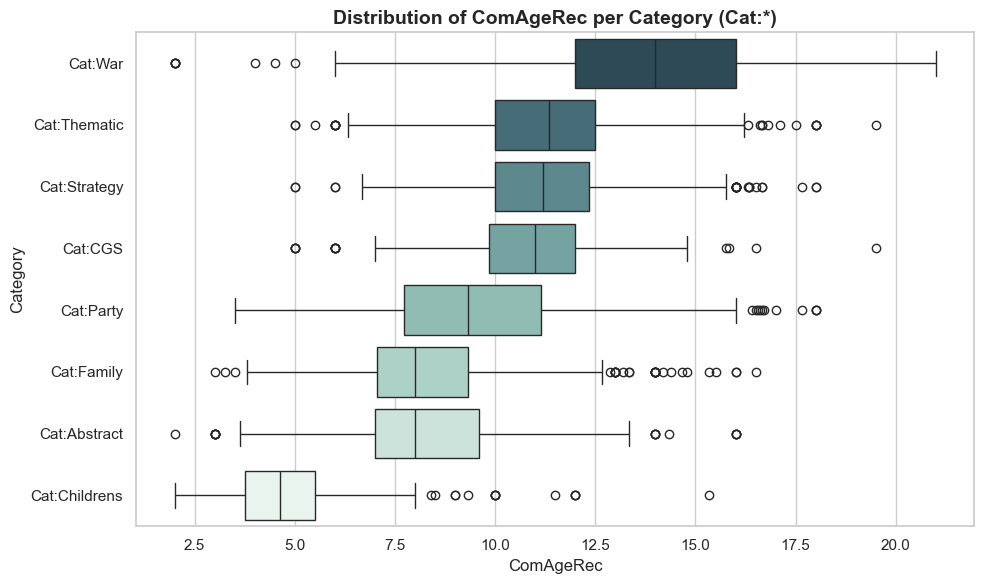

In [21]:
def plot_comagerec_box_by_cat(data: pd.DataFrame, summary_df, target="ComAgeRec"):
    """
    Ordered boxplot of ComAgeRec per Cat:* using a cubehelix palette.
    Highest median category appears on top and gets the darkest color.
    """

    ordered = summary_df["Category"].tolist()

    # Build long-format dataframe
    long_data = []
    vals = pd.to_numeric(data[target], errors="coerce")

    for cat in ordered:
        subset = vals[data[cat] == 1]
        for v in subset.dropna():
            long_data.append({"Category": cat, target: v})

    long_df = pd.DataFrame(long_data)

    # Your requested cubehelix palette
    palette = sns.cubehelix_palette(
        start=2.7, rot=-0.2,
        light=0.92, dark=0.15,
        gamma=0.7, n_colors=len(ordered),
        reverse=True
    )

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=long_df,
        y="Category",
        x=target,
        order=ordered,
        hue="Category",       # FIX: assign hue
        palette=palette,      # apply palette safely
        legend=False          # FIX: remove legend (required)
    )

    plt.title("Distribution of ComAgeRec per Category (Cat:*)", fontsize=14, fontweight="bold")
    plt.xlabel("ComAgeRec")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()

plot_comagerec_box_by_cat(df, summary_stats, target="ComAgeRec")

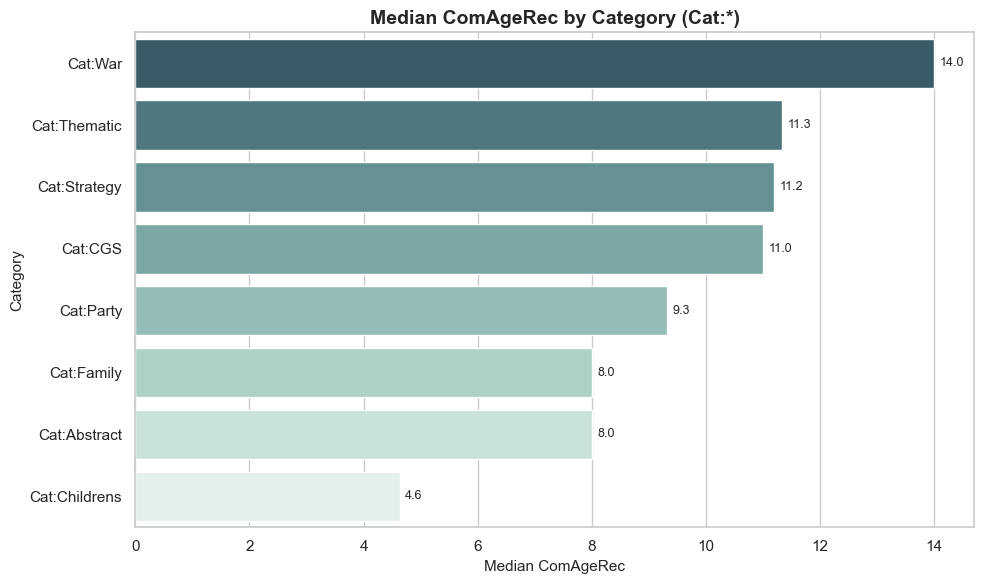

In [22]:
def explore_comagerec_by_cat(
    data: pd.DataFrame,
    age_col: str = "ComAgeRec",
    prefix: str = "Cat:",
    min_non_missing: int = 50,
    figsize: tuple = (10, 6),
    title: str = "Median ComAgeRec by Category (Cat:*)"
) -> None:
    """
    Explore how ComAgeRec varies across Cat:* categories, sorted from highest to lowest median.
    Only plots the result (no summary DataFrame returned).
    """

    # Identify Cat:* columns
    cat_cols = [c for c in data.columns if c.startswith(prefix)]
    if not cat_cols:
        raise ValueError(f"No columns starting with '{prefix}' found.")

    # Ensure ComAgeRec is numeric
    s_age = pd.to_numeric(data[age_col], errors="coerce")

    # Build summary per category
    rows = []
    for c in cat_cols:
        mask = (data[c] == 1) & s_age.notna()
        if mask.sum() == 0:
            continue
        rows.append({
            "Category": c,
            "median_ComAgeRec": float(s_age[mask].median()),
            "non_missing_count": int(mask.sum())
        })

    summary = pd.DataFrame(rows)
    if summary.empty:
        print("No non-missing ComAgeRec values for any Cat:* category.")
        return

    # Minimum support
    summary = summary[summary["non_missing_count"] >= min_non_missing]

    # Sort: highest median ON TOP
    summary = summary.sort_values("median_ComAgeRec", ascending=False).reset_index(drop=True)

    # DARK → LIGHT cubehelix palette
    palette = sns.cubehelix_palette(
        start=2.7, rot=-0.2, light=0.90, dark=0.20,
        gamma=0.7, n_colors=len(summary), reverse=True
    )

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=figsize)

    sns.barplot(
        data=summary,
        x="median_ComAgeRec",
        y="Category",
        hue="Category",
        palette=palette,
        dodge=False,
        legend=False
    )

    # Add text labels
    for i, row in summary.iterrows():
        plt.text(
            row["median_ComAgeRec"] + 0.1,
            i,
            f"{row['median_ComAgeRec']:.1f}",
            va="center",
            fontsize=9
        )

    plt.xlabel("Median ComAgeRec", fontsize=11)
    plt.ylabel("Category", fontsize=11)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

explore_comagerec_by_cat(df)



## Category-based Median Imputation for `ComAgeRec`


In [23]:
def impute_comagerec_by_cat(
    data: pd.DataFrame,
    age_col: str = "ComAgeRec",
    prefix: str = "Cat:",
) -> pd.DataFrame:
    """
    Impute missing ComAgeRec using Cat:* category-specific medians.
    The global median is used ONLY as fallback for rows with no active categories.
    """

    df = data.copy()

    # Identify category columns
    cat_cols = [c for c in df.columns if c.startswith(prefix)]
    if not cat_cols:
        raise ValueError(f"No columns starting with '{prefix}' found.")

    # Convert age to numeric
    df[age_col] = pd.to_numeric(df[age_col], errors="coerce")

    global_median = float(df[age_col].median())

    # Compute medians per category
    cat_medians = {}
    for c in cat_cols:
        values = df.loc[(df[c] == 1) & df[age_col].notna(), age_col]
        if len(values) > 0:
            cat_medians[c] = float(values.median())

    before_na = df[age_col].isna().sum()

    # Row-wise imputation
    def _impute(row):
        if not pd.isna(row[age_col]):
            return row[age_col]

        active = [c for c in cat_cols if row[c] == 1 and c in cat_medians]

        if active:
            # median of group-specific medians
            return float(np.median([cat_medians[c] for c in active]))
        else:
            return global_median

    df[age_col] = df.apply(_impute, axis=1)
    after_na = df[age_col].isna().sum()

    print(
        f"ComAgeRec imputation completed.\n"
        f"Missing before: {before_na:,} → after: {after_na:,}\n"
        f"(global median {global_median:.2f} used only as fallback)"
    )

    return df
df = impute_comagerec_by_cat(df)
df["ComAgeRec"].isna().sum()


ComAgeRec imputation completed.
Missing before: 5,530 → after: 0
(global median 10.00 used only as fallback)


0

# `Rating`: encoding

A quick inspection of the Rating variable shows that it is a categorical feature with three ordered levels: Low, Medium, and High.
There are no missing values, no irregularities in the distribution, and no evidence of multimodality or structural issues that would require additional preprocessing.

=== Distribution of 'Rating' ===
        Count  Percentage
Rating                   
Low      7245       33.04
Medium   9644       43.99
High     5036       22.97


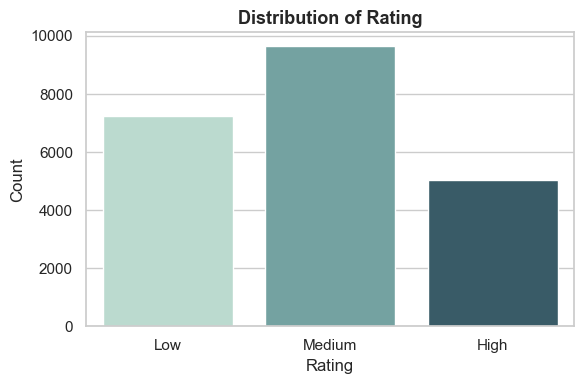

In [24]:
def analyze_rating_distribution(df: pd.DataFrame, col: str = "Rating") -> None:
    """
    Analyze the distribution of an ordinal categorical Rating variable.
    Rating must be one of: ['Low', 'Medium', 'High'].

    Displays:
    - Frequency table (counts + percentages)
    - Barplot with correct ordinal ordering (no seaborn warnings)
    """

    # Expected order
    rating_order = ["Low", "Medium", "High"]

    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in the dataframe.")

    # Convert to ordered categorical
    df[col] = pd.Categorical(df[col], categories=rating_order, ordered=True)

    # Drop missing for counting
    s = df[col].dropna()

    # Frequency table
    freq = s.value_counts().reindex(rating_order)
    pct = (freq / len(df)) * 100

    summary = pd.DataFrame({
        "Count": freq,
        "Percentage": pct.round(2)
    })

    print(f"=== Distribution of '{col}' ===")
    print(summary)

    # --- Plot ---
    sns.set_theme(style="whitegrid")

    palette = sns.cubehelix_palette(
        start=2.7,
        rot=-0.2,
        light=0.75,
        dark=0.20,
        gamma=0.7,
        n_colors=3
    )

    plt.figure(figsize=(6, 4))

    # FIX: assign hue=x and disable legend
    sns.countplot(
        data=df,
        x=col,
        order=rating_order,
        hue=col,        # required fix
        palette=palette,
        legend=False    # suppress automatic legend
    )

    plt.title(f"Distribution of {col}", fontsize=13, fontweight="bold")
    plt.ylabel("Count")
    plt.xlabel("Rating")

    plt.tight_layout()
    plt.show()
analyze_rating_distribution(df, col="Rating")

Because `Rating` is inherently ordinal, its order carries semantic meaning (Low < Medium < High).
To preserve this structure and enable its use in downstream tasks such as classification, clustering, and regression, we convert it into an **integer ordinal scale**:


- Low → 1


- Medium → 2


- High → 3


This encoding maintains the natural ranking of categories, avoids unnecessary one-hot encoding, and provides a compact numeric representation suitable for machine learning algorithms.

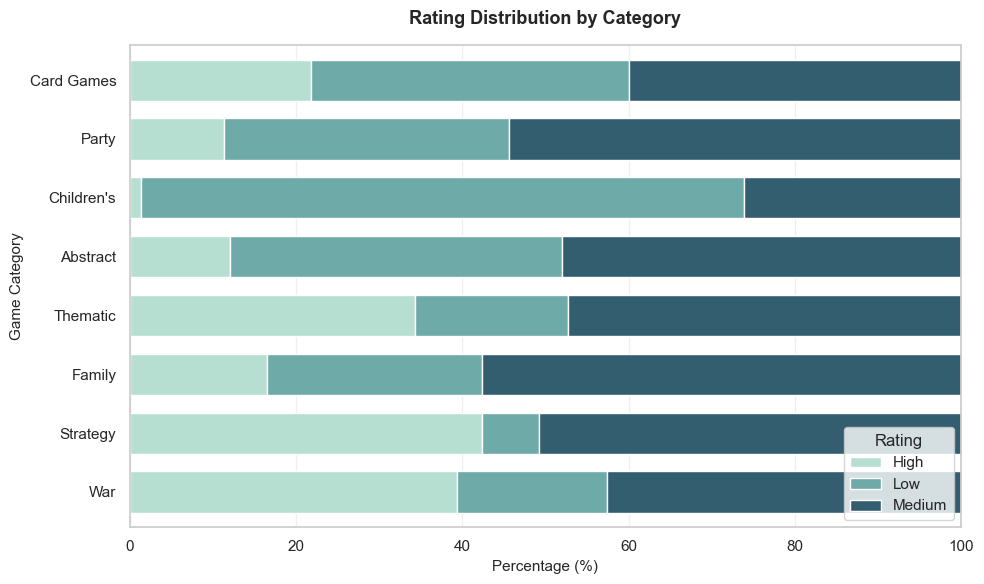


=== Rating Distribution Summary by Category ===

Rating      Total Games    Low  Medium   High
Category                                     
War                3530  18.07   42.61  39.32
Strategy           2319   6.86   50.75  42.39
Family             2316  25.86   57.64  16.49
Thematic           1224  18.46   47.22  34.31
Abstract           1115  39.91   47.98  12.11
Children's          881  72.53   26.11   1.36
Party               640  34.22   54.37  11.41
Card Games          303  38.28   39.93  21.78

Note: Percentages are calculated within each category.


In [25]:
def plot_rating_by_category(df: pd.DataFrame, rating_col: str = "Rating") -> None:
    """
    Plot the distribution of Rating across different game categories.
    Shows proportions within each category (100% stacked bar chart).
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe containing Rating and Cat:* columns
    rating_col : str
        Name of the rating column (default: "Rating")
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Define category columns and their labels
    cat_cols = {
        'Cat:Strategy': 'Strategy',
        'Cat:Family': 'Family',
        'Cat:Thematic': 'Thematic',
        'Cat:War': 'War',
        'Cat:Party': 'Party',
        'Cat:Childrens': 'Children\'s',
        'Cat:Abstract': 'Abstract',
        'Cat:CGS': 'Card Games'
    }
    
    # Expected rating order
    rating_order = ["Low", "Medium", "High"]
    
    # Ensure Rating is categorical with correct order
    df[rating_col] = pd.Categorical(df[rating_col], categories=rating_order, ordered=True)
    
    # Prepare data for plotting
    data_list = []
    
    for cat_col, cat_label in cat_cols.items():
        if cat_col not in df.columns:
            print(f"Warning: Column '{cat_col}' not found, skipping...")
            continue
            
        # Filter games in this category
        cat_df = df[df[cat_col] == 1].copy()
        
        if len(cat_df) == 0:
            continue
            
        # Count ratings
        rating_counts = cat_df[rating_col].value_counts().reindex(rating_order, fill_value=0)
        
        for rating in rating_order:
            data_list.append({
                'Category': cat_label,
                'Rating': rating,
                'Count': rating_counts[rating],
                'Total': len(cat_df)
            })
    
    # Create dataframe
    plot_df = pd.DataFrame(data_list)
    plot_df['Percentage'] = (plot_df['Count'] / plot_df['Total']) * 100
    
    # Sort categories by total count (descending)
    cat_order = plot_df.groupby('Category')['Total'].first().sort_values(ascending=False).index.tolist()
    
    # Color palette
    palette = sns.cubehelix_palette(
        start=2.7,
        rot=-0.2,
        light=0.75,
        dark=0.20,
        gamma=0.7,
        n_colors=3
    )
    colors = {rating: color for rating, color in zip(rating_order, palette)}
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Percentages (stacked 100%)
    pivot_pct = plot_df.pivot(index='Category', columns='Rating', values='Percentage')
    pivot_pct = pivot_pct.reindex(cat_order)
    
    pivot_pct.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        color=[colors[r] for r in rating_order],
        width=0.7
    )
    ax.set_title('Rating Distribution by Category', 
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Percentage (%)', fontsize=11)
    ax.set_ylabel('Game Category', fontsize=11)
    ax.legend(title='Rating', loc='lower right', frameon=True)
    ax.set_xlim(0, 100)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # --- Print summary statistics ---
    print("\n=== Rating Distribution Summary by Category ===\n")
    summary = plot_df.pivot_table(
        index='Category',
        columns='Rating',
        values='Percentage',
        aggfunc='first'
    ).reindex(cat_order)
    
    # Add total games column
    totals = plot_df.groupby('Category')['Total'].first().reindex(cat_order)
    summary['Total Games'] = totals
    
    # Reorder columns
    summary = summary[['Total Games'] + rating_order]
    
    print(summary.round(2))
    print(f"\nNote: Percentages are calculated within each category.")


# Usage
plot_rating_by_category(df, rating_col="Rating")

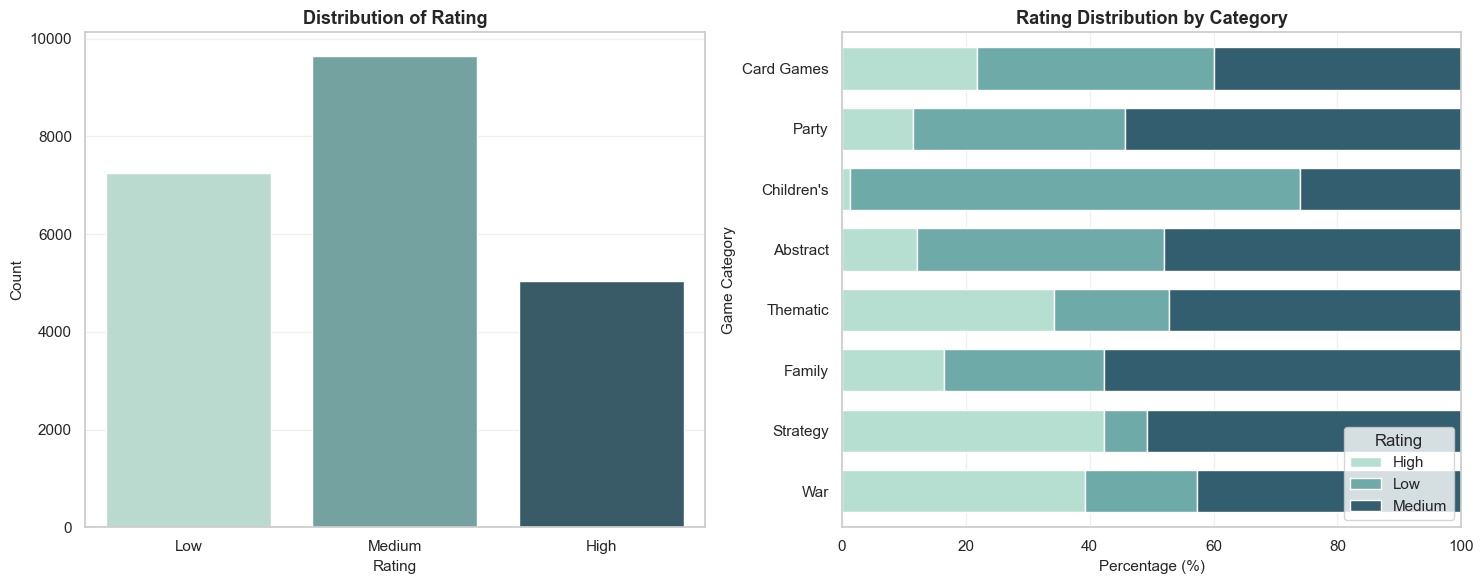


=== Overall Rating Distribution ===
        Count  Percentage
Rating                   
Low      7245       33.04
Medium   9644       43.99
High     5036       22.97

=== Rating Distribution Summary by Category ===

Rating      Total Games    Low  Medium   High
Category                                     
War                3530  18.07   42.61  39.32
Strategy           2319   6.86   50.75  42.39
Family             2316  25.86   57.64  16.49
Thematic           1224  18.46   47.22  34.31
Abstract           1115  39.91   47.98  12.11
Children's          881  72.53   26.11   1.36
Party               640  34.22   54.37  11.41
Card Games          303  38.28   39.93  21.78

Note: Percentages are calculated within each category.


In [26]:
def plot_rating_distributions_combined(df: pd.DataFrame, rating_col: str = "Rating") -> None:
    """
    Create side-by-side plots:
    - Left: Overall Rating distribution
    - Right: Rating distribution by game category (100% stacked)
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe containing Rating and Cat:* columns
    rating_col : str
        Name of the rating column (default: "Rating")
    """
    # Expected order
    rating_order = ["Low", "Medium", "High"]
    
    # Convert to ordered categorical
    df[rating_col] = pd.Categorical(df[rating_col], categories=rating_order, ordered=True)
    
    # Define category columns
    cat_cols = {
        'Cat:Strategy': 'Strategy',
        'Cat:Family': 'Family',
        'Cat:Thematic': 'Thematic',
        'Cat:War': 'War',
        'Cat:Party': 'Party',
        'Cat:Childrens': 'Children\'s',
        'Cat:Abstract': 'Abstract',
        'Cat:CGS': 'Card Games'
    }
    
    # Color palette
    palette = sns.cubehelix_palette(
        start=2.7,
        rot=-0.2,
        light=0.75,
        dark=0.20,
        gamma=0.7,
        n_colors=3
    )
    colors = {rating: color for rating, color in zip(rating_order, palette)}
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # ============= LEFT PLOT: Overall Distribution =============
    sns.countplot(
        data=df,
        x=rating_col,
        order=rating_order,
        hue=rating_col,
        palette=palette,
        legend=False,
        ax=axes[0]
    )
    axes[0].set_title('Distribution of Rating', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].set_xlabel('Rating', fontsize=11)
    axes[0].grid(axis='y', alpha=0.3)
    
    # ============= RIGHT PLOT: By Category =============
    # Prepare data for category plot
    data_list = []
    
    for cat_col, cat_label in cat_cols.items():
        if cat_col not in df.columns:
            continue
            
        cat_df = df[df[cat_col] == 1].copy()
        if len(cat_df) == 0:
            continue
            
        rating_counts = cat_df[rating_col].value_counts().reindex(rating_order, fill_value=0)
        
        for rating in rating_order:
            data_list.append({
                'Category': cat_label,
                'Rating': rating,
                'Count': rating_counts[rating],
                'Total': len(cat_df)
            })
    
    plot_df = pd.DataFrame(data_list)
    plot_df['Percentage'] = (plot_df['Count'] / plot_df['Total']) * 100
    
    # Sort categories by total count
    cat_order = plot_df.groupby('Category')['Total'].first().sort_values(ascending=False).index.tolist()
    
    # Pivot and plot
    pivot_pct = plot_df.pivot(index='Category', columns='Rating', values='Percentage')
    pivot_pct = pivot_pct.reindex(cat_order)
    
    pivot_pct.plot(
        kind='barh',
        stacked=True,
        ax=axes[1],
        color=[colors[r] for r in rating_order],
        width=0.7
    )
    
    axes[1].set_title('Rating Distribution by Category', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Percentage (%)', fontsize=11)
    axes[1].set_ylabel('Game Category', fontsize=11)
    axes[1].legend(title='Rating', loc='lower right', frameon=True)
    axes[1].set_xlim(0, 100)
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n=== Overall Rating Distribution ===")
    freq = df[rating_col].value_counts().reindex(rating_order)
    pct = (freq / len(df)) * 100
    summary = pd.DataFrame({
        "Count": freq,
        "Percentage": pct.round(2)
    })
    print(summary)
    
    print("\n=== Rating Distribution Summary by Category ===\n")
    summary_cat = plot_df.pivot_table(
        index='Category',
        columns='Rating',
        values='Percentage',
        aggfunc='first'
    ).reindex(cat_order)
    
    totals = plot_df.groupby('Category')['Total'].first().reindex(cat_order)
    summary_cat['Total Games'] = totals
    summary_cat = summary_cat[['Total Games'] + rating_order]
    
    print(summary_cat.round(2))
    print(f"\nNote: Percentages are calculated within each category.")


# Usage
plot_rating_distributions_combined(df, rating_col="Rating")

In [27]:
def encode_rating(df: pd.DataFrame, col: str = "Rating") -> pd.DataFrame:
    """
    Encode an ordinal Rating column ('Low', 'Medium', 'High') as integers 1,2,3.
    Includes validation and confirmation prints.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset
    col : str
        Column to encode (default: 'Rating')

    Returns
    -------
    pd.DataFrame
        New dataframe with encoded Rating
    """

    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in the dataframe.")

    # Allowed categories
    mapping = {
        "Low": 1,
        "Medium": 2,
        "High": 3
    }

    # Check unexpected categories
    unique_vals = set(df[col].dropna().unique())
    unexpected = unique_vals - set(mapping.keys())

    if unexpected:
        print("Warning: unexpected categories found in Rating:", unexpected)
        print("They will be encoded as NaN.\n")

    print("Rating values before encoding:", unique_vals)

    # Create encoded version
    df_new = df.copy()
    df_new[col] = df_new[col].map(mapping)

    print("Rating encoding completed:")
    print("   Low → 1, Medium → 2, High → 3")
    print(f"   Missing or unknown categories mapped to NaN")
    print()

    print("Encoded Rating summary:")
    print(df_new[col].value_counts(dropna=False))

    return df_new
df = encode_rating(df, col="Rating")
df["Rating"].head()

Rating values before encoding: {'Low', 'Medium', 'High'}
Rating encoding completed:
   Low → 1, Medium → 2, High → 3
   Missing or unknown categories mapped to NaN

Encoded Rating summary:
Rating
2    9644
1    7245
3    5036
Name: count, dtype: int64


0    1
1    2
2    3
3    1
4    2
Name: Rating, dtype: category
Categories (3, int64): [1 < 2 < 3]

# `LanguageEase`

The variable LanguageEase is described in the dataset documentation as a language requirement indicator. However, the observed values are completely inconsistent with that definition:

- values range from 3 to more than 1200

- many entries contain decimals without semantic meaning (e.g., 19.66, 443.5, 1219.33)

- the distribution shows extremely large variance and no recognizable ordinal structure

- the variable cannot be interpreted in terms of "language dependency" as described in the metadata

These abnormalities indicate that probably **LanguageEase has been corrupted during dataset construction**.
Because the feature no longer reflects its intended semantics, no meaningful imputation strategy exists, and keeping it would only introduce noise into subsequent analyses (clustering, classification, pattern mining).

For these reasons, **LanguageEase is removed entirely from the dataset.**

This decision is supported by additional checks (correlation and distribution analysis) showing that the feature does not contribute any usable structure and is inconsistent with all other game attributes.

=== Summary statistics for LanguageEase ===
count    16034.000000
mean       216.461819
std        236.595136
min          1.000000
25%         24.027778
50%        138.000000
75%        351.000000
max       1757.000000
Name: LanguageEase, dtype: float64


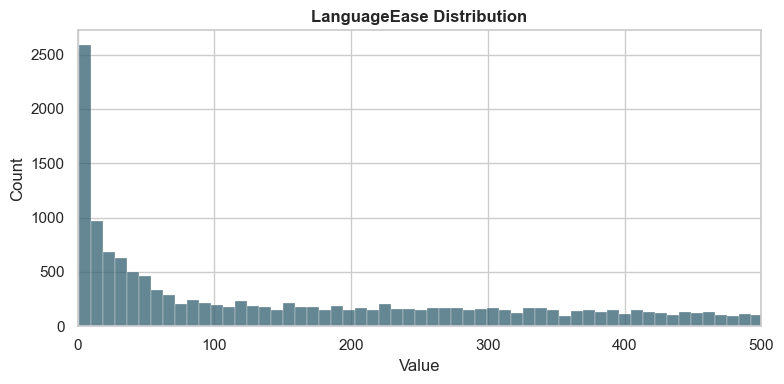


=== Spearman correlations with other numeric features ===
LanguageEase          1.000000
BGGId                 0.248465
YearPublished         0.234378
Kickstarted           0.115394
Cat:War               0.005372
MfgAgeRec             0.000851
IsReimplementation   -0.001693
ComAgeRec            -0.008876
MinPlayers           -0.020224
MaxPlayers           -0.022337
Cat:CGS              -0.022550
Cat:Party            -0.023457
ComWeight            -0.034385
GameWeight           -0.034759
Cat:Abstract         -0.040182
Cat:Childrens        -0.043450
NumExpansions        -0.044011
MfgPlaytime          -0.053506
ComMaxPlaytime       -0.053506
Cat:Thematic         -0.059880
NumImplementations   -0.067361
Cat:Family           -0.073304
NumWish              -0.088577
ComMinPlaytime       -0.089587
NumWant              -0.128452
Cat:Strategy         -0.137592
NumAlternates        -0.146973
NumOwned             -0.160131
NumUserRatings       -0.175718
NumWeightVotes       -0.257611
BestPlayers

In [28]:
def inspect_languageease(data: pd.DataFrame, col: str = "LanguageEase"):
    """
    Quick validation that LanguageEase is corrupted and uninformative:
    - summary statistics
    - histogram
    - Spearman correlations with other variables
    """

    if col not in data.columns:
        print(f"Column '{col}' not found.")
        return

    s = pd.to_numeric(data[col], errors="coerce")

    print("=== Summary statistics for LanguageEase ===")
    print(s.describe(percentiles=[0.25, 0.5, 0.75]))

    # --- Same palette used in rating plot ---
    palette = sns.cubehelix_palette(
        start=2.7,
        rot=-0.2,
        light=0.75,
        dark=0.20,
        gamma=0.7,
        n_colors=3
    )

    darkest_color = palette[2]   # ← il colore più scuro

    # --- Plot distribution ---
    plt.figure(figsize=(8, 4))
    sns.histplot(s, bins=200, kde=False, color=darkest_color)
    plt.title("LanguageEase Distribution", fontweight="bold")
    plt.xlabel("Value")
    plt.xlim(0, 500)
    plt.tight_layout()
    plt.show()

    # --- Correlations ---
    num_cols = data.select_dtypes(include="number").columns
    corr = data[num_cols].corr(method="spearman")[col].sort_values(ascending=False)

    print("\n=== Spearman correlations with other numeric features ===")
    print(corr)

inspect_languageease(df, col="LanguageEase")

In [29]:
def drop_languageease(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove the corrupted 'LanguageEase' attribute from the dataset.

    - Checks if the column exists
    - Drops it safely
    - Returns a cleaned copy of the dataframe
    """

    if "LanguageEase" not in df.columns:
        print("LanguageEase not found in dataframe. Nothing to drop.")
        return df.copy()

    df_clean = df.drop(columns=["LanguageEase"]).copy()
    print("Removed corrupted attribute: 'LanguageEase'")

    return df_clean
df = drop_languageease(df)


Removed corrupted attribute: 'LanguageEase'


# `GameWeight` and `ComWeight`

Both variables represent game complexity on a bounded scale \[1–5\].  
Before analysing their relationship, we inspect each variable individually:

- summary statistics (min, max, quantiles),
- distribution shape,
- semantic validity: values should lie within \[1, 5\].

This step allows us to detect corrupted or out-of-range values.


=== GameWeight: descriptive statistics ===
count    21925.000000
mean         1.982131
std          0.848983
min          0.000000
25%          1.333300
50%          1.968800
75%          2.525200
max          5.000000
Name: GameWeight, dtype: float64

Semantic check for GameWeight (expected domain [1, 5]):
  Total non-missing values : 21925
  Values < 1               : 506
  Values > 5               : 0


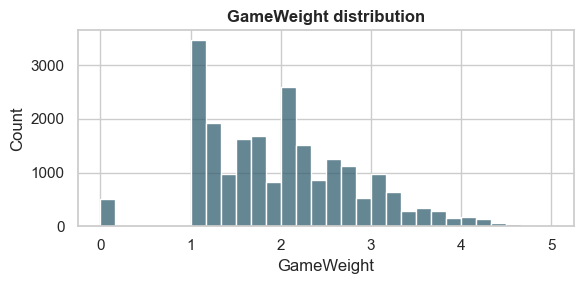


=== ComWeight: descriptive statistics ===
count    21925.000000
mean         2.177479
std          0.861781
min          0.000000
25%          1.513400
50%          2.128000
75%          2.737700
max          5.213200
Name: ComWeight, dtype: float64

Semantic check for ComWeight (expected domain [1, 5]):
  Total non-missing values : 21925
  Values < 1               : 506
  Values > 5               : 13


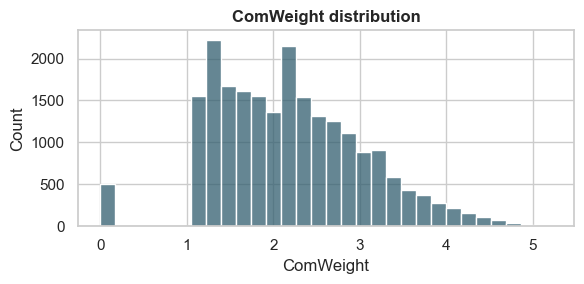


=== Spearman correlation between GameWeight and ComWeight ===
Spearman ρ = 0.9961


0.9960921245584909

In [30]:
def analyze_weight_relationship(df: pd.DataFrame,
                                game_col: str = "GameWeight",
                                com_col: str = "ComWeight") -> float:
    """
    Univariate inspection of GameWeight and ComWeight + Spearman correlation.

    Steps:
    1) For each variable:
       - descriptive statistics (min, max, quantiles)
       - distribution shape (histogram)
       - semantic validity: check 1 <= value <= 5

    2) Compute Spearman correlation between GameWeight and ComWeight.

    Returns
    -------
    rho : float
        Spearman correlation coefficient between the two weights.
    """

    # Define cubehelix palette once (your project style)
    palette = sns.cubehelix_palette(
        start=2.7,
        rot=-0.2,
        light=0.75,
        dark=0.20,
        gamma=0.7,
        n_colors=3
    )
    darkest_color = palette[-1]   # <- correctly select the darkest color

    # ---- 1) Univariate inspection ----
    for col in [game_col, com_col]:
        if col not in df.columns:
            print(f"Column '{col}' not found in dataframe.")
            return float("nan")

        s = pd.to_numeric(df[col], errors="coerce")

        print(f"\n=== {col}: descriptive statistics ===")
        print(s.describe(percentiles=[0.25, 0.5, 0.75]))
        print()

        # Semantic validity within [1, 5]
        below_1 = (s < 1).sum()
        above_5 = (s > 5).sum()
        n_total = s.notna().sum()

        print(f"Semantic check for {col} (expected domain [1, 5]):")
        print(f"  Total non-missing values : {n_total}")
        print(f"  Values < 1               : {below_1}")
        print(f"  Values > 5               : {above_5}")

        # --- Histogram with correct color ---
        plt.figure(figsize=(6, 3))
        sns.histplot(s, bins=30, color=darkest_color)
        plt.title(f"{col} distribution", fontweight="bold")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

    # ---- 2) Spearman correlation ----
    s_game = pd.to_numeric(df[game_col], errors="coerce")
    s_com = pd.to_numeric(df[com_col], errors="coerce")

    valid_mask = s_game.notna() & s_com.notna()
    rho = s_game[valid_mask].corr(s_com[valid_mask], method="spearman")

    print("\n=== Spearman correlation between GameWeight and ComWeight ===")
    print(f"Spearman ρ = {rho:.4f}")

    return rho
analyze_weight_relationship(df)

To assess how similar the two weight measures are, we also have computed the **Spearman
correlation**, which is appropriate for bounded, ordinal-like scores.

Since the correlation between `GameWeight` and `ComWeight` is extremely high,
we conclude that the two variables are redundant.  
`ComWeight` also contains more out-of-range values (values > 5), therefore we
retain only `GameWeight` for the analysis and drop `ComWeight`.


In [31]:
def drop_comweight(df, com_col="ComWeight"):
    """
    Drop ComWeight after verifying redundancy and anomalies.
    """
    if com_col in df.columns:
        return df.drop(columns=[com_col])
    return df
df = drop_comweight(df)

In [32]:
df.columns

Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'BestPlayers', 'GoodPlayers',
       'NumOwned', 'NumWant', 'NumWish', 'NumWeightVotes', 'MfgPlaytime',
       'ComMinPlaytime', 'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings',
       'NumComments', 'NumAlternates', 'NumExpansions', 'NumImplementations',
       'IsReimplementation', 'Kickstarted', 'ImagePath', 'Cat:Thematic',
       'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract',
       'Cat:Party', 'Cat:Childrens', 'Rating'],
      dtype='object')

Both `GameWeight` and `ComWeight` contain 506 zero values (~2.31%).  
These zeros occur **in the same rows and in both variables**.

Since the BGG weight scale is defined on \[1–5\], a value of 0 does not represent
a real complexity score: it indicates that the game has received no weight votes.
Therefore, zeros are treated as **missing values**, even though they remain
numerically encoded as 0.

Because missing values appear in both weight variables simultaneously, one
cannot be used to impute the other. Instead, we rely on the observation that
complexity strongly depends on game genre.

Using the `Cat:*` binary attributes, we estimate a typical `GameWeight` for each
category. Games with missing weights are then imputed using the medians of the
categories to which they belong. If no category provides a meaningful median,
the global median of `GameWeight` is used as fallback.

This approach preserves meaningful differences between game types and only
affects a very small portion of the dataset.

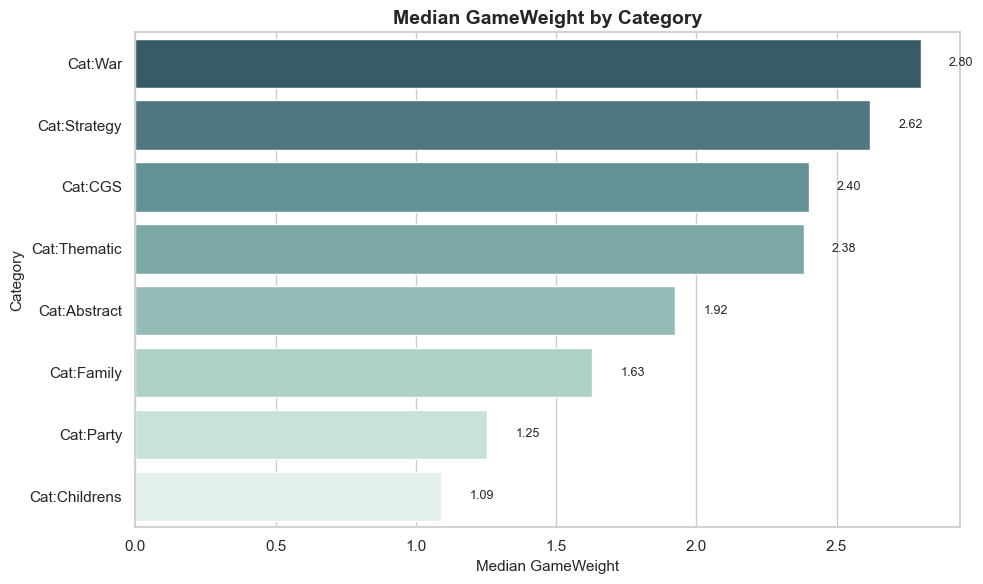

In [33]:
def explore_gameweight_by_cat(
    data: pd.DataFrame,
    weight_col: str = "GameWeight",
    prefix: str = "Cat:",
    min_non_missing: int = 50,
    figsize: tuple = (10, 6),
    title: str = "Median GameWeight by Category"
) -> None:
    """
    Explore how GameWeight varies across Cat:* categories, sorted from highest to lowest median.
    Zeros in GameWeight are treated as missing (ignored), but NOT modified in the dataframe.
    """

    # Identify Cat:* columns
    cat_cols = [c for c in data.columns if c.startswith(prefix)]
    if not cat_cols:
        raise ValueError(f"No columns starting with '{prefix}' found.")

    # Ensure weights are numeric
    s_w = pd.to_numeric(data[weight_col], errors="coerce")

    # Build summary
    rows = []
    for c in cat_cols:
        mask = (data[c] == 1) & (s_w > 0)  # zero = missing
        if mask.sum() == 0:
            continue
        rows.append({
            "Category": c,
            "median_GameWeight": float(s_w[mask].median()),
            "non_missing_count": int(mask.sum())
        })

    summary = pd.DataFrame(rows)
    if summary.empty:
        print("No non-missing GameWeight values for any Cat:* category.")
        return

    # Minimum support
    summary = summary[summary["non_missing_count"] >= min_non_missing]

    # Sort highest → lowest
    summary = summary.sort_values("median_GameWeight", ascending=False).reset_index(drop=True)

    # Cubehelix palette (darkest = highest median)
    palette = sns.cubehelix_palette(
        start=2.7, rot=-0.2, light=0.90, dark=0.20,
        gamma=0.7, n_colors=len(summary), reverse=True
    )

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=summary,
        x="median_GameWeight",
        y="Category",
        hue="Category",          # <–– REQUIRED to avoid warning
        palette=palette,
        dodge=False,
        legend=False             # hide legend (categories already on y–axis)
    )

    # Add labels
    for i, row in summary.iterrows():
        ax.text(
            row["median_GameWeight"] + 0.1,
            i,
            f"{row['median_GameWeight']:.2f}",
            va="center",
            fontsize=9
        )

    plt.xlabel("Median GameWeight", fontsize=11)
    plt.ylabel("Category", fontsize=11)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
explore_gameweight_by_cat(df)

In [34]:
def impute_gameweight_by_category(
    df: pd.DataFrame,
    weight_col: str = "GameWeight",
    cat_prefix: str = "Cat:"
) -> pd.DataFrame:
    """
    Category-based imputation for GameWeight.

    Zeros in `weight_col` are treated as missing values.
    For rows where GameWeight == 0:

    - Use Cat:* columns to impute a plausible complexity:
        * compute per-category medians on non-zero GameWeight values;
        * for each game, take all active categories and impute with the
          median of their medians;
        * if no valid category median is available, use the global median
          of GameWeight (computed on non-zero values).

    Returns a cleaned copy of the dataframe.
    """

    cleaned = df.copy()

    # Ensure numeric
    cleaned[weight_col] = pd.to_numeric(cleaned[weight_col], errors="coerce")

    # Rows with missing complexity (0)
    mask_missing = cleaned[weight_col] == 0
    print(f"Rows with {weight_col} equal to 0 (treated as missing): {mask_missing.sum()}")

    # Category columns
    cat_cols = [c for c in cleaned.columns if c.startswith(cat_prefix)]

    # Per-category medians of GameWeight (ignoring zeros)
    cat_medians = {}
    for cat in cat_cols:
        vals = cleaned.loc[(cleaned[cat] == 1) & (cleaned[weight_col] > 0), weight_col]
        cat_medians[cat] = vals.median()

    # Global median of GameWeight (ignoring zeros)
    global_median = cleaned.loc[cleaned[weight_col] > 0, weight_col].median()
    print(f"Global median {weight_col} (non-zero): {global_median:.3f}")

    # Impute for each row with missing GameWeight
    for idx in cleaned[mask_missing].index:
        row = cleaned.loc[idx]
        active_cats = [c for c in cat_cols if row.get(c, 0) == 1]

        # Collect available category medians
        vals = [cat_medians[c] for c in active_cats
                if c in cat_medians and not np.isnan(cat_medians[c])]

        if vals:
            imputed = float(np.median(vals))
        else:
            imputed = float(global_median)

        cleaned.at[idx, weight_col] = imputed

    # Quick check
    remaining_zero = (cleaned[weight_col] == 0).sum()
    print(f"Rows still with {weight_col} == 0 after imputation: {remaining_zero}")

    return cleaned
df = impute_gameweight_by_category(df)

Rows with GameWeight equal to 0 (treated as missing): 506
Global median GameWeight (non-zero): 2.000
Rows still with GameWeight == 0 after imputation: 0


# `NumComments`

The variable `NumComments` represents the total number of textual comments
posted by users for each game. 

By he way, performing a simple validity check to count how many values are zero and how
many are non-zero reveals that **all values are equal to zero**. 

Hence, it's safe and appropriate to remove it from the dataset.


In [35]:
def check_numcomments_all_zero(df: pd.DataFrame, col: str = "NumComments") -> bool:
    """
    Check whether the column NumComments contains only zeros.

    Prints:
    - number of zero values
    - number of non-zero values
    - percentage of non-zero values

    Returns:
        True  -> if all values are zero
        False -> otherwise
    """

    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in dataframe.")

    # Coerce to numeric in case the column has strings
    s = pd.to_numeric(df[col], errors="coerce")

    total = len(s)
    zeros = (s == 0).sum()
    nonzeros = (s != 0).sum()

    print("=== NumComments Zero Check ===")
    print(f"Total rows:         {total}")
    print(f"Zero values:        {zeros}")
    print(f"Non-zero values:    {nonzeros}")
    print(f"% non-zero values:  {nonzeros/total*100:.4f}%")

    return nonzeros == 0
check_numcomments_all_zero(df)

=== NumComments Zero Check ===
Total rows:         21925
Zero values:        21925
Non-zero values:    0
% non-zero values:  0.0000%


True

In [36]:
def drop_numcomments(df: pd.DataFrame, col: str = "NumComments") -> pd.DataFrame:
    """
    Drop NumComments if it contains only zeros or if the user has already
    verified that it is uninformative.

    Returns a copy of the dataframe without the column.
    """

    if col not in df.columns:
        print(f"Column '{col}' not found; nothing to drop.")
        return df

    print(f"Column '{col}' dropped successfully.")
    return df.drop(columns=[col])
df = drop_numcomments(df)


Column 'NumComments' dropped successfully.


## `YearPublished`

=== YearPublished: Missing Values ===
0

=== YearPublished: Descriptive Statistics ===
count    21925.000000
mean      1985.494914
std        212.486214
min      -3500.000000
25%       2001.000000
50%       2011.000000
75%       2017.000000
max       2021.000000
Name: YearPublished, dtype: float64

=== Suspicious Values Check ===
Values < 1900: 309
Values > 2026: 0
Value == 0: 193


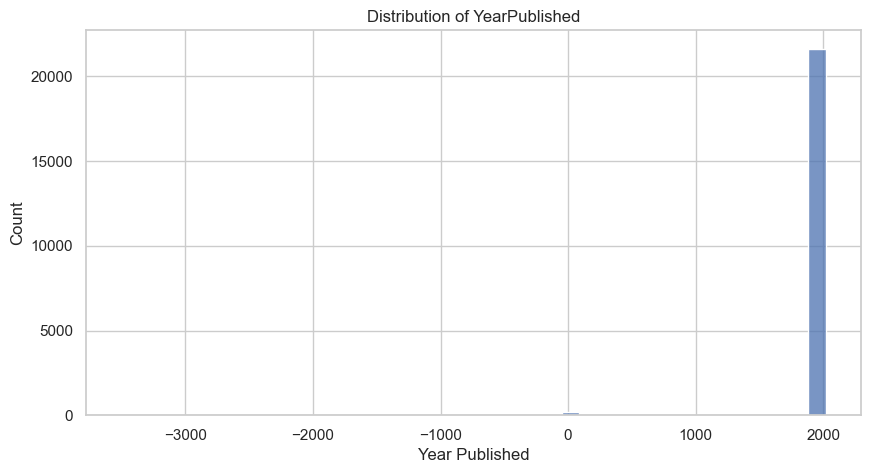


Number of invalid or suspicious years: 309

Sample of suspicious entries:


,BGGId,Name,Description,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,BestPlayers,GoodPlayers,...,ImagePath,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
47,6819,Skat,traditional german card game player play stand...,1810,3.0561,3,3,9.666667,3,"['3', '3+']",...,https://cf.geekdo-images.com/2n21-A8TXn5QtW66n...,0,1,0,0,0,0,0,0,2
61,29351,Durak,durak known popular card game russia ukraine d...,0,1.5263,2,6,8.000000,0,[],...,https://cf.geekdo-images.com/utBGr2hGEfdgLvG89...,0,0,0,0,0,0,1,0,2
181,19257,Le Truc,le truc th century card game france spain sid ...,0,1.7500,2,4,10.000000,0,[],...,https://cf.geekdo-images.com/n96nHb05kwHyv7-69...,0,0,0,0,0,0,0,0,2
392,41955,Eurooppa Tietopeli,classic trivium game question answer europe ...,0,2.0000,2,6,8.000000,0,[],...,https://cf.geekdo-images.com/glWISYkeoEl9UgYxv...,0,0,0,0,0,0,0,0,1
610,101723,Hungarian Tarokk,hungarian tarokk know huacuteszashiacutevaacut...,1870,3.5000,4,4,10.000000,0,[],...,https://cf.geekdo-images.com/LvVLC1WSpPDbDrWt2...,0,0,0,0,0,0,0,0,2


In [37]:
# === 1. Basic overview ===
print("=== YearPublished: Missing Values ===")
print(df['YearPublished'].isna().sum())

print("\n=== YearPublished: Descriptive Statistics ===")
print(df['YearPublished'].describe())

# === 2. Check for impossible or suspicious values ===
current_year = datetime.now().year

print("\n=== Suspicious Values Check ===")
print(f"Values < 1900: {sum(df['YearPublished'] < 1900)}")
print(f"Values > {current_year}: {sum(df['YearPublished'] > current_year)}")
print(f"Value == 0: {sum(df['YearPublished'] == 0)}")

# === 3. View distribution (histogram) ===
plt.figure(figsize=(10, 5))
sns.histplot(df['YearPublished'], bins=40, kde=False)
plt.title("Distribution of YearPublished")
plt.xlabel("Year Published")
plt.ylabel("Count")
plt.show()




# === 5. Flag problematic values ===
invalid_year_mask = (df['YearPublished'] < 1900) | (df['YearPublished'] > current_year) | (df['YearPublished'] == 0)
invalid_count = invalid_year_mask.sum()

print(f"\nNumber of invalid or suspicious years: {invalid_count}")

# Optional: view those rows
if invalid_count > 0:
    print("\nSample of suspicious entries:")
    display(df[invalid_year_mask].head())


In [38]:
# Percentuale giochi anno 0:
zero_year_pct = (df['YearPublished'] == 0).sum() / len(df) * 100
print(f"\nPercentage of games with YearPublished == 0: {zero_year_pct:.4f}%")

#Percentuale giochi tra anno 1 e 1950:
early_year_pct = ((df['YearPublished'] >= 1) & (df['YearPublished'] < 1950)).sum() / len(df) * 100
print(f"Percentage of games with YearPublished between 1 and 1949: {early_year_pct:.4f}%")

# Percentuale giochi prima del 1949:
pre_1949_pct = (df['YearPublished'] < 1949).sum() / len(df) * 100
print(f"Percentage of games published before 1949: {pre_1949_pct:.4f}%")

#Percentuale giochi minori di 1950
pre_1950_pct = (df['YearPublished'] < 1950).sum() / len(df) * 100
print(f"Percentage of games published before 1950: {pre_1950_pct:.4f}%")

# Dimmi il min di YearPublished:
min_year = df['YearPublished'].min()
print(f"\nMinimum YearPublished in dataset: {min_year}")




Percentage of games with YearPublished == 0: 0.8803%
Percentage of games with YearPublished between 1 and 1949: 0.9213%
Percentage of games published before 1949: 1.8335%
Percentage of games published before 1950: 1.8518%

Minimum YearPublished in dataset: -3500


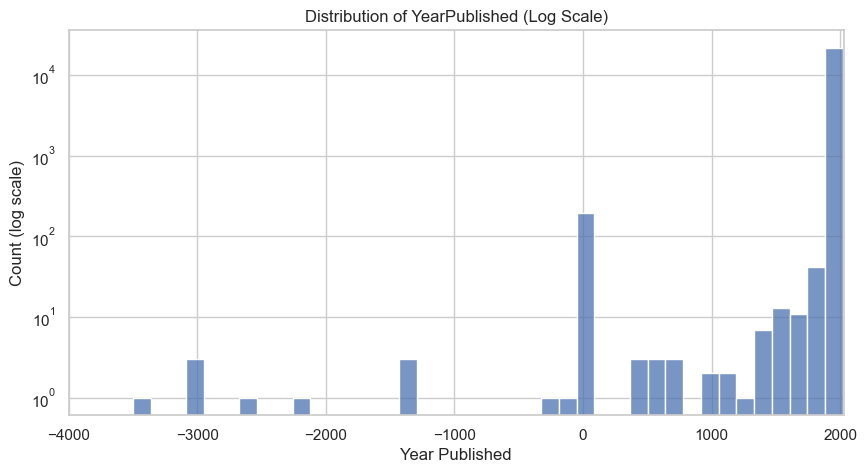

In [39]:
# === View distribution (histogram) log scale ===
plt.figure(figsize=(10, 5))
sns.histplot(df['YearPublished'], bins=40, kde=False)
plt.yscale("log")
plt.title("Distribution of YearPublished (Log Scale)")
plt.xlabel("Year Published")
plt.ylabel("Count (log scale)")
plt.xlim(-4000, current_year)
plt.show()



###  Removing Games Published Before 1950 (between 1 and 1950)

We also identified that a small percentage of games in the dataset were published **before 1950**. These games account for **0.93%** of the total dataset (approximately 202 entries out of 21,000). Given the small proportion, we decided to remove those entries.


In [40]:
# Count how many values are greater than 1950
greater_1950_count = (df['YearPublished'] > 1950).sum()
print(f"Number of entries with YearPublished > 1950: {greater_1950_count}")

# Count how many values are less than 1950
less_1950_count = (df['YearPublished'] < 1950).sum()
print(f"Number of entries with YearPublished < 1950: {less_1950_count}")

# Percentage of entriwes with YearPublished < 1950
percentage_less_1950 = (less_1950_count / len(df)) * 100
print(f"Percentage of entries with YearPublished < 1950: {percentage_less_1950:.2f}%")

Number of entries with YearPublished > 1950: 21515
Number of entries with YearPublished < 1950: 406
Percentage of entries with YearPublished < 1950: 1.85%


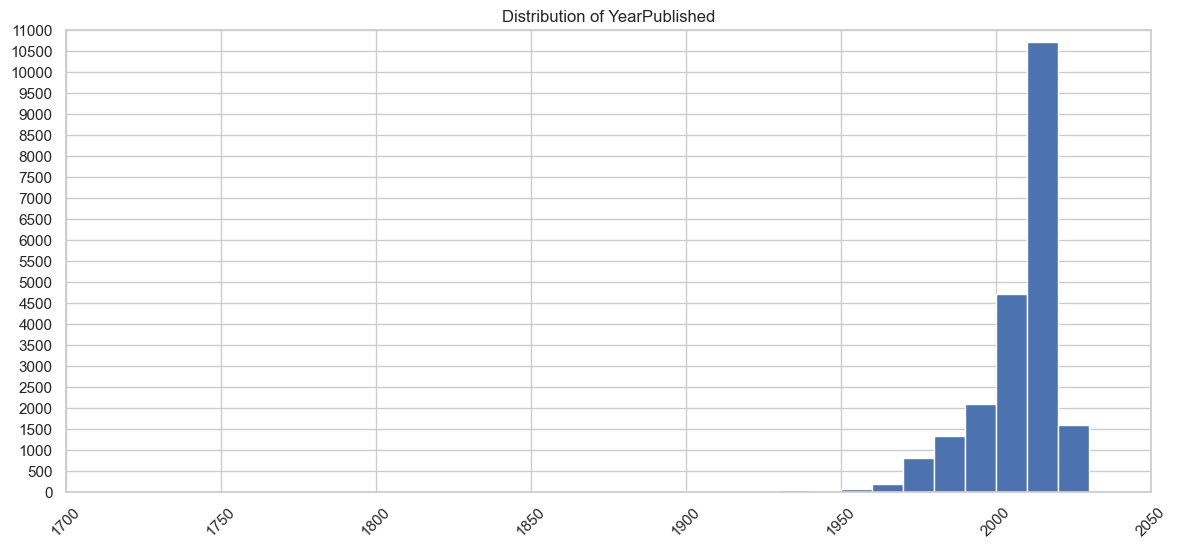

In [41]:
plt.figure(figsize=(14, 6))

# Crea un istogramma con intervalli di 10 anni
n_bins = len(range(df['YearPublished'].min(), df['YearPublished'].max() + 10, 10))  # Calcola il numero di bin
plt.hist(df['YearPublished'], bins=range(df['YearPublished'].min(), df['YearPublished'].max() + 10, 10))

# Imposta i tick dell'asse X ogni 50 anni
plt.xticks(range(1700, 2051, 50), rotation=45)  # Impostiamo i tick da 1700 a 2050, ogni 50 anni

# Imposta il limite dell'asse X da 1700 a 2050
plt.xlim(1700, 2050)

# Imposta l'intervallo dell'asse Y ogni 500 unità
plt.yticks(range(0, 11001, 500))  

# Limita l'asse Y a un massimo di 11000
plt.ylim(0, 11000)

# Imposta la palette dei colori usando cubehelix
palette = sns.cubehelix_palette(
    start=2.7, rot=-0.2, light=0.90, dark=0.20,
    gamma=0.7, n_colors=n_bins, reverse=True
)

# Usa la palette impostata
sns.set_palette(palette)

# Titolo del grafico
plt.title("Distribution of YearPublished")
plt.show()


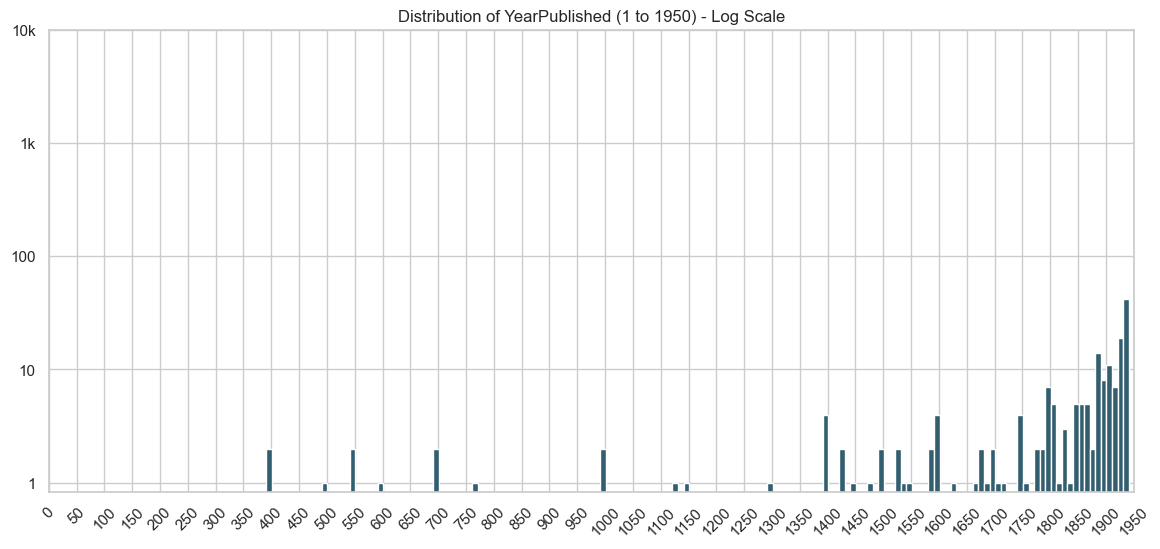

In [42]:
# Create a plot with just the values from 1 to 1950. As they are very low, we will use a logarithmic scale for the y axis.
plt.figure(figsize=(14, 6))
# Create a histogram with intervals of 10 years
plt.hist(df[df['YearPublished'] <= 1950]['YearPublished'], bins=range(1, 1951, 10))
# Set the x-axis ticks every 50 years
plt.xticks(range(0, 1951, 50), rotation=45)  # Set ticks from 0 to 1950, every 50 years
# Set the x-axis limit from 0 to 1950
plt.xlim(0, 1950)
# Set the y-axis to logarithmic scale
plt.yscale('log')
# Set the y-axis ticks every 10 units
plt.yticks([1, 10, 100, 1000, 10000], ['1', '10', '100', '1k', '10k'])
# Set the palette using cubehelix
palette = sns.cubehelix_palette(
    start=2.7, rot=-0.2, light=0.90, dark=0.20,
    gamma=0.7, n_colors=20, reverse=True
)
# Use the set palette
sns.set_palette(palette)
# Title of the plot
plt.title("Distribution of YearPublished (1 to 1950) - Log Scale")
plt.show()


In [43]:
# Calculate the percentage of games published before 1950
total_games = len(df)
games_before_1950 = len(df[df['YearPublished'] < 1950])
percentage_before_1950 = (games_before_1950 / total_games) * 100
print(f"Percentage of games published before 1950: {percentage_before_1950:.4f}%")

Percentage of games published before 1950: 1.8518%


In [44]:
def drop_values_less_1950(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Drop rows where the values in the specified column are < 1950.
    
    Returns a copy of the dataframe with the rows removed.
    """
    
    if col not in df.columns:
        print(f"Column '{col}' not found; nothing to drop.")
        return df
    
    # Rimuove le righe con valori < 1950 nella colonna specificata
    df_cleaned = df[df[col] >= 1950].copy()  # Filtra solo le righe con valori >= 1950
    
    print(f"Rows with values < 1950 in column '{col}' dropped successfully.")
    return df_cleaned
df = drop_values_less_1950(df, 'YearPublished')


Rows with values < 1950 in column 'YearPublished' dropped successfully.


In [45]:
# Verify that there are no more values <= 0 in YearPublished
zero_count = (df['YearPublished'] <= 0).sum()
print(f"Number of entries with YearPublished <= 0: {zero_count}")

# Verify that there are no more values < 1950 in YearPublished
less_1950_count = (df['YearPublished'] < 1950).sum()    
print(f"Number of entries with YearPublished < 1950: {less_1950_count}")

Number of entries with YearPublished <= 0: 0
Number of entries with YearPublished < 1950: 0


### `MinPlayers` & `MaxPlayers`



In [46]:
# Statistics summary for MinPlayers and MaxPlayers
print("=== MinPlayers Summary ===")
print(df['MinPlayers'].describe())
print("\n=== MaxPlayers Summary ===")
print(df['MaxPlayers'].describe())


=== MinPlayers Summary ===
count    21519.000000
mean         2.005809
std          0.691868
min          0.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         10.000000
Name: MinPlayers, dtype: float64

=== MaxPlayers Summary ===
count    21519.000000
mean         5.696175
std         15.075926
min          0.000000
25%          4.000000
50%          4.000000
75%          6.000000
max        999.000000
Name: MaxPlayers, dtype: float64


In [47]:
# === Consistency check for MinPlayers and MaxPlayers ===
# 1. Check if there are any games where MinPlayers > MaxPlayers (invalid data)
invalid_data = df[df['MinPlayers'] > df['MaxPlayers']]
print(f"Games with MinPlayers > MaxPlayers: {len(invalid_data)}")

# 2. Check for MinPlayers = 0 (invalid data)
invalid_minplayers = df[df['MinPlayers'] == 0]
print(f"Games with MinPlayers = 0: {len(invalid_minplayers)}")

# 3. Check for MaxPlayers = 0 (invalid data)
invalid_maxplayers = df[df['MaxPlayers'] == 0]
print(f"Games with MaxPlayers = 0: {len(invalid_maxplayers)}")

# 4. Check for extreme MaxPlayers values (e.g., MaxPlayers > 20)
extreme_maxplayers = df[df['MaxPlayers'] > 20]
print(f"Games with MaxPlayers > 20: {len(extreme_maxplayers)}")


Games with MinPlayers > MaxPlayers: 121
Games with MinPlayers = 0: 43
Games with MaxPlayers = 0: 155
Games with MaxPlayers > 20: 269


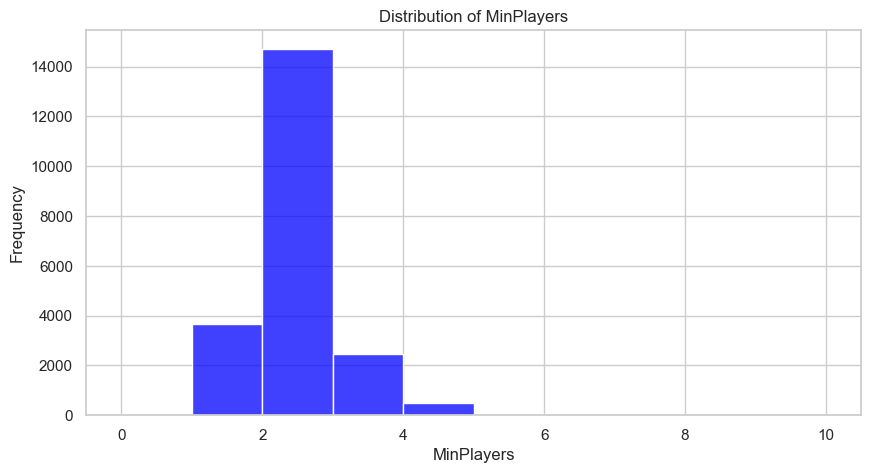

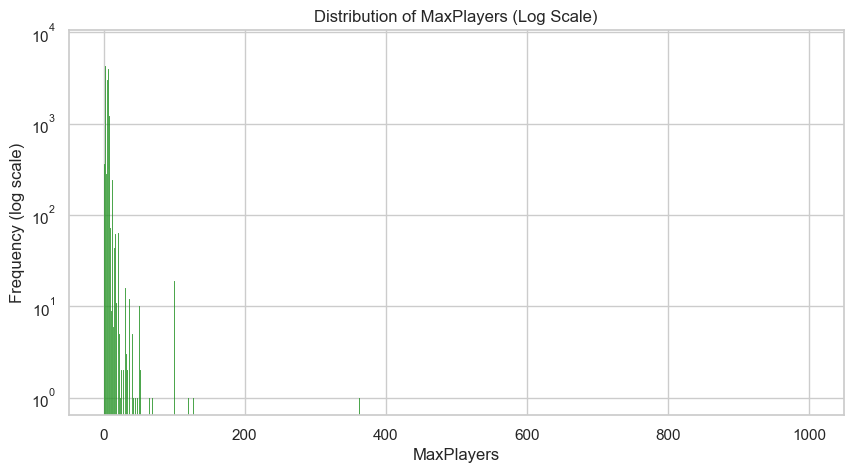

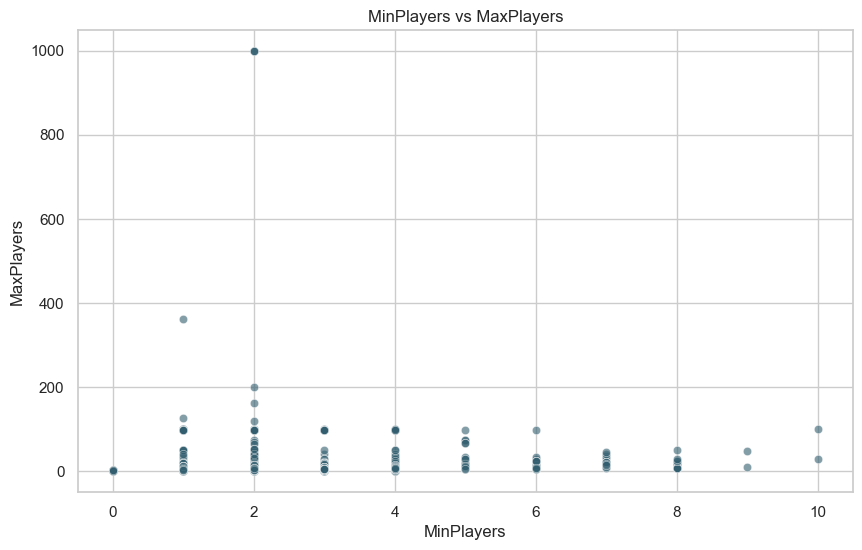

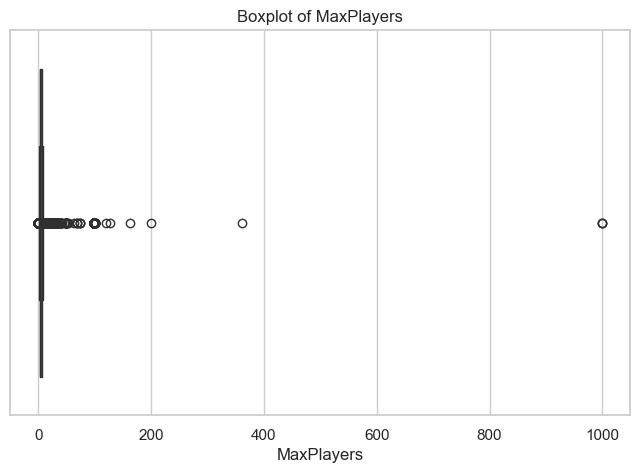

In [48]:
# Create a plot of the distribution of MinPlayers
plt.figure(figsize=(10, 5))
sns.histplot(df['MinPlayers'], bins=range(df['MinPlayers'].min(), df['MinPlayers'].max() + 1, 1), kde=False, color='blue')
plt.title("Distribution of MinPlayers")
plt.xlabel("MinPlayers")
plt.ylabel("Frequency")
plt.show()

# Create a plot of the distribution of MaxPlayers (log scale)
plt.figure(figsize=(10, 5))
sns.histplot(df['MaxPlayers'], bins=range(df['MaxPlayers'].min(), df['MaxPlayers'].max() + 1, 1), kde=False, color='green')
plt.yscale("log")
plt.title("Distribution of MaxPlayers (Log Scale)")
plt.xlabel("MaxPlayers")
plt.ylabel("Frequency (log scale)")
plt.show()

# Create a scatter plot of MinPlayers vs MaxPlayers
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MinPlayers', y='MaxPlayers', data=df, alpha=0.6)
plt.title("MinPlayers vs MaxPlayers")
plt.xlabel("MinPlayers")
plt.ylabel("MaxPlayers")
plt.show()

# Boxplot of MaxPlayers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['MaxPlayers'])
plt.title("Boxplot of MaxPlayers")
plt.xlabel("MaxPlayers")
plt.show()


In [49]:
# Calculate the percentage of 0 in MinPlayers
zero_minplayers_count = (df['MinPlayers'] == 0).sum()
total_games = len(df)
percentage_zero_minplayers = (zero_minplayers_count / total_games) * 100
print(f"Percentage of games with MinPlayers = 0: {percentage_zero_minplayers:.4f}%")

# Calculate the percentage of 0 in MaxPlayers
zero_maxplayers_count = (df['MaxPlayers'] == 0).sum()
# print(f"Somma di celle con entrambi 0: {zero_maxplayers_count}")
# print(f"Total games: {total_games}")
percentage_zero_maxplayers = (zero_maxplayers_count / total_games) * 100
print(f"Percentage of games with MaxPlayers = 0: {percentage_zero_maxplayers:.4f}%")

# Calculate the percentage when MinPlayers and MaxPlayers have 0
zero_both_count = ((df['MinPlayers'] == 0) & (df['MaxPlayers'] == 0)).sum()
percentage_zero_both = (zero_both_count / total_games) * 100
print(f"Percentage of games with both MinPlayers and MaxPlayers = 0: {percentage_zero_both:.4f}%")

# Calculate missing values in MinPlayers
missing_minplayers_count = df['MinPlayers'].isna().sum()
percentage_missing_minplayers = (missing_minplayers_count / total_games) * 100
print(f"Percentage of missing values in MinPlayers: {percentage_missing_minplayers:.4f}%")

# Calculate missing values in MaxPlayers
missing_maxplayers_count = df['MaxPlayers'].isna().sum()
percentage_missing_maxplayers = (missing_maxplayers_count / total_games) * 100
print(f"Percentage of missing values in MaxPlayers: {percentage_missing_maxplayers:.4f}%")

Percentage of games with MinPlayers = 0: 0.1998%
Percentage of games with MaxPlayers = 0: 0.7203%
Percentage of games with both MinPlayers and MaxPlayers = 0: 0.1580%
Percentage of missing values in MinPlayers: 0.0000%
Percentage of missing values in MaxPlayers: 0.0000%


In [50]:
# Calculate how many values of MinPlayers are greater than MaxPlayers
invalid_min_max_count = (df['MinPlayers'] > df['MaxPlayers']).sum()
percentage_invalid_min_max = (invalid_min_max_count / total_games) * 100
print(f"Percentage of games with MinPlayers > MaxPlayers: {percentage_invalid_min_max:.4f}%")
# Create a df
df_invalid_min_max = df[df['MinPlayers'] > df['MaxPlayers']]

Percentage of games with MinPlayers > MaxPlayers: 0.5623%


,BGGId,Name,Description,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,BestPlayers,GoodPlayers,...,ImagePath,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
206,39342,Bet Your Brain,trivium game question card question card q...,2008,2.3000,2,0,9.000000,0,[],...,https://cf.geekdo-images.com/bo_mjoujJ6NRhv7i7...,0,0,0,0,0,0,0,0,1
604,66809,Flying Lead,fly lead play tabletop action wide range genre...,2010,2.6667,2,0,14.000000,0,[],...,https://cf.geekdo-images.com/YD43s0_QQBeUnWoTG...,0,0,1,0,0,0,0,0,3
640,38263,Sushi Bar,publisherquotsome chinese character fish shell...,2005,1.0000,1,0,5.000000,0,[],...,https://cf.geekdo-images.com/b0AGVULu0lgUCfo1o...,0,0,0,0,0,0,0,0,2
827,135598,Pub Trivia,seller web pagebre fun pub trivium home grab f...,2012,3.0000,3,0,12.000000,0,[],...,https://cf.geekdo-images.com/cjpnlyuus586b5Ey8...,0,0,0,0,0,0,0,0,1
1019,75418,Regimental Fire and Fury,publisher website fireandfurycomregimental fir...,2010,3.0000,2,0,14.000000,0,[],...,https://cf.geekdo-images.com/H0BSZmjAeHtp_Ld8e...,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20987,19796,Cranium: The Family Fun Game,manufacturer cranium family fun give family ...,2005,1.4444,4,0,9.333333,0,[],...,https://cf.geekdo-images.com/l1V2NoXmvAcTDvG60...,0,0,0,1,0,0,0,1,1
21082,1540,BattleTech,battletech aka quotbtquot sciencefiction tacti...,1985,3.4178,2,0,11.904762,4,[],...,https://cf.geekdo-images.com/MmCjO907d3IB6IcK3...,1,0,1,0,0,0,0,0,2
21201,131017,La Bérézina 1812,berezina focus batlle fight remnant napoleon...,2012,2.7500,2,0,12.000000,0,[],...,https://cf.geekdo-images.com/V2A721gBf_K9kvEOv...,0,0,1,0,0,0,0,0,3
21246,131163,Ghost Hunt,turn light ready big thrillswith magical eye p...,2011,1.5000,1,0,10.000000,0,[],...,https://cf.geekdo-images.com/VSsWoaL_aYfA1pVqZ...,0,0,0,0,0,0,0,0,1


In [57]:
# Calcola skewness e kurtosis per MinPlayers e MaxPlayers
skew_minplayers = skew(df['MinPlayers'].dropna())
kurtosis_minplayers = kurtosis(df['MinPlayers'].dropna())
skew_maxplayers = skew(df['MaxPlayers'].dropna())
kurtosis_maxplayers = kurtosis(df['MaxPlayers'].dropna())
print(f"MinPlayers - Skewness: {skew_minplayers:.4f}, Kurtosis: {kurtosis_minplayers:.4f}")
print(f"MaxPlayers - Skewness: {skew_maxplayers:.4f}, Kurtosis: {kurtosis_maxplayers:.4f}")

MinPlayers - Skewness: 1.7751, Kurtosis: 10.9758
MaxPlayers - Skewness: 42.6602, Kurtosis: 2657.5028


### Removing outliers in MaxPlayers

In [58]:
# STEP 1: Calcola IQR GLOBALE (come prima prova)
Q1 = df['MaxPlayers'].quantile(0.25)
Q3 = df['MaxPlayers'].quantile(0.75)
IQR = Q3 - Q1
soglia = 4

lower_bound = Q1 - soglia * IQR
upper_bound = Q3 + soglia * IQR

lower_bound = max(1, lower_bound)  

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower: {lower_bound}, Upper: {upper_bound}")

# STEP 2: Identifica outliers
outliers = df[(df['MaxPlayers'] < lower_bound) | (df['MaxPlayers'] > upper_bound)]
print(f"Outliers trovati: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
#print(outliers[['Name', 'MaxPlayers', 'GameCategory']].head(20))

# STEP 3: Rimuovi outliers
df_clean = df[(df['MaxPlayers'] >= lower_bound) & (df['MaxPlayers'] <= upper_bound)]

print("\n=== PRIMA ===")
print(f"Skewness: {skew(df['MaxPlayers']):.4f}")
print(f"Kurtosis: {kurtosis(df['MaxPlayers']):.4f}")

print("\n=== DOPO ===")
print(f"Skewness: {skew(df_clean['MaxPlayers']):.4f}")
print(f"Kurtosis: {kurtosis(df_clean['MaxPlayers']):.4f}")

# Dammi valore massimo di MaxPlayers
max_maxplayers = df_clean['MaxPlayers'].max()
print(f"Max value of MaxPlayers after outlier removal: {max_maxplayers}")

df_clean['MaxPlayers'].min()
print(f"Min value of MaxPlayers after outlier removal: {df_clean['MaxPlayers'].min()}")

Q1: 4.0, Q3: 6.0, IQR: 2.0
Lower: 1, Upper: 14.0
Outliers trovati: 454 (2.11%)

=== PRIMA ===
Skewness: 42.6602
Kurtosis: 2657.5028

=== DOPO ===
Skewness: 0.8889
Kurtosis: 1.5286
Max value of MaxPlayers after outlier removal: 14
Min value of MaxPlayers after outlier removal: 1


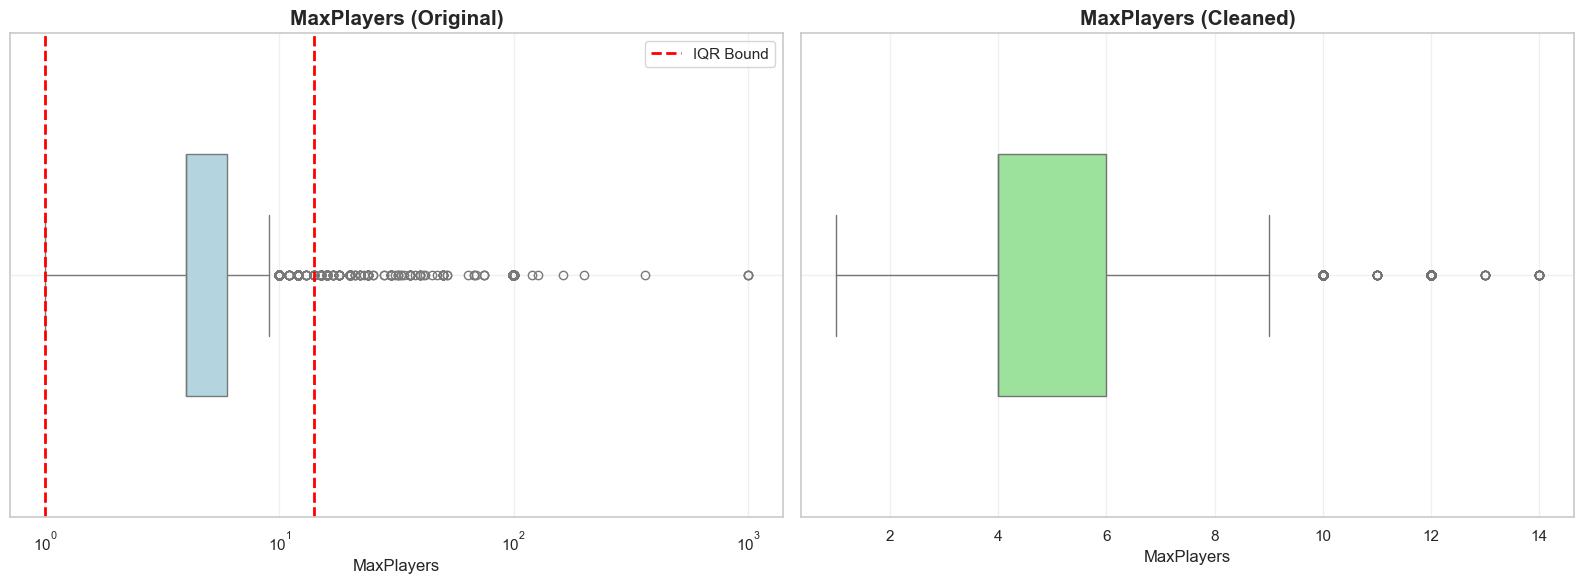

In [61]:
def plot_comparison_outliers(df_original, df_clean, feature, iqr_multiplier=4, figsize=(16, 6)):
    """
    Crea due boxplot affiancati: 
    1. Dataset originale con limiti IQR
    2. Dataset pulito dopo la rimozione
    """
    
    # Prepara i dati
    x_orig = df_original[feature].dropna()
    x_clean = df_clean[feature].dropna()
    
    # Calcola limiti IQR sul dataset originale
    Q1 = x_orig.quantile(0.25)
    Q3 = x_orig.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(1, Q1 - iqr_multiplier * IQR)
    upper_bound = Q3 + iqr_multiplier * IQR
    
    # Crea la figura con 1 riga e 2 colonne
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # --- GRAFICO 1: PRIMA DELLA RIMOZIONE ---
    sns.boxplot(x=x_orig, ax=ax1, color='lightblue', width=0.5)
    ax1.axvline(lower_bound, color='red', linestyle='--', linewidth=2, label='IQR Bound')
    ax1.axvline(upper_bound, color='red', linestyle='--', linewidth=2)
    
    ax1.set_title(f'{feature} (Original)', fontsize=15, fontweight='bold')
    ax1.set_xlabel(feature)
    ax1.set_xscale('log') # Scala logaritmica per vedere meglio la distribuzione
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # --- GRAFICO 2: DOPO LA RIMOZIONE ---
    sns.boxplot(x=x_clean, ax=ax2, color='lightgreen', width=0.5)
    
    ax2.set_title(f'{feature} (Cleaned)', fontsize=15, fontweight='bold')
    ax2.set_xlabel(feature)
    # Rimuoviamo la scala logaritmica a destra se i dati ora sono più compatti, 
    # o tienila se preferisci coerenza:
    # ax2.set_xscale('log') 
    
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# ============================================================================
# ESEMPIO DI UTILIZZO
# ============================================================================

if __name__ == "__main__":
    feature_name = 'MaxPlayers'
    
    # 1. Calcolo i limiti sul DF originale
    Q1 = df[feature_name].quantile(0.25)
    Q3 = df[feature_name].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 4 * IQR
    lower_limit = max(1, Q1 - 4 * IQR)
    
    # 2. Creo il DF pulito (se non lo hai già fatto)
    df_clean = df[(df[feature_name] >= lower_limit) & (df[feature_name] <= upper_limit)]
    
    # 3. Genero il confronto
    fig = plot_comparison_outliers(df, df_clean, feature_name, iqr_multiplier=4)
    plt.show()

In [62]:
# Verifica kurtosis e skewness finali
print("\n=== FINAL STATS FOR MinPlayers AND MaxPlayers ===")
skew_minplayers_final = skew(df['MinPlayers'].dropna())
kurtosis_minplayers_final = kurtosis(df['MinPlayers'].dropna())
skew_maxplayers_final = skew(df['MaxPlayers'].dropna())
kurtosis_maxplayers_final = kurtosis(df['MaxPlayers'].dropna())
print(f"MinPlayers - Skewness: {skew_minplayers_final:.4f}, Kurtosis: {kurtosis_minplayers_final:.4f}")
print(f"MaxPlayers - Skewness: {skew_maxplayers_final:.4f}, Kurtosis: {kurtosis_maxplayers_final:.4f}")


=== FINAL STATS FOR MinPlayers AND MaxPlayers ===
MinPlayers - Skewness: 1.7751, Kurtosis: 10.9758
MaxPlayers - Skewness: 42.6602, Kurtosis: 2657.5028


## `NumOwned`, `NumWant`, `NumWish` = `InterestScore`


Descriptive Statistics:
             NumOwned      NumWant       NumWish
min          2.000000     0.000000      0.000000
max     166497.000000  2031.000000  19182.000000
mean      1470.013523    42.306102    231.624564
median     324.000000     9.000000     40.000000
std       5299.197349   118.104458    794.584227
Missing Values:
NumOwned    0
NumWant     0
NumWish     0
dtype: int64

Unique Values:
NumOwned    4230
NumWant      698
NumWish     1794
dtype: int64

Zero Values Present:
NumOwned       0
NumWant     1818
NumWish       92
dtype: int64

Outliers (using IQR method):
NumOwned    2792
NumWant     2785
NumWish     2951
dtype: int64


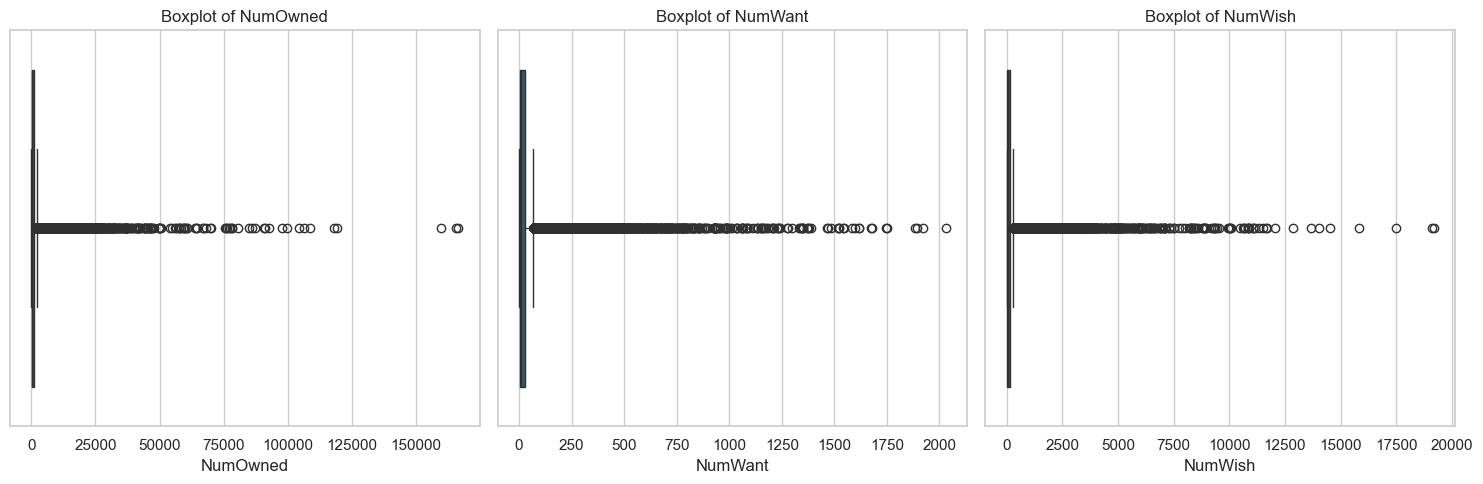

In [64]:
# Calculate min, max, mean, median, and standard deviation for each feature
stats = df[['NumOwned', 'NumWant', 'NumWish']].agg(['min', 'max', 'mean', 'median', 'std'])
print("Descriptive Statistics:")
print(stats)

# Check for missing values in the relevant columns
missing_values = df[['NumOwned', 'NumWant', 'NumWish']].isna().sum()
print("Missing Values:")
print(missing_values)

# Check the number of unique values in each feature
unique_values = df[['NumOwned', 'NumWant', 'NumWish']].nunique()
print("\nUnique Values:")
print(unique_values)

# Count how many times zero appears in each of the features
zeros_count = (df[['NumOwned', 'NumWant', 'NumWish']] == 0).sum()
print("\nZero Values Present:")
print(zeros_count)

# Identify potential outliers using the Interquartile Range (IQR) method
# Calculate the first and third quartiles (Q1 and Q3) and the IQR for each feature
Q1 = df[['NumOwned', 'NumWant', 'NumWish']].quantile(0.25)
Q3 = df[['NumOwned', 'NumWant', 'NumWish']].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outlier detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers that fall outside these bounds
outliers = ((df[['NumOwned', 'NumWant', 'NumWish']] < lower_bound) | 
            (df[['NumOwned', 'NumWant', 'NumWish']] > upper_bound)).sum()

print("\nOutliers (using IQR method):")
print(outliers)

# Visualize the distribution of these features using boxplots to visually inspect for outliers
plt.figure(figsize=(15, 5))

# Boxplot for NumOwned
plt.subplot(1, 3, 1)
sns.boxplot(x=df['NumOwned'])
plt.title('Boxplot of NumOwned')

# Boxplot for NumWant
plt.subplot(1, 3, 2)
sns.boxplot(x=df['NumWant'])
plt.title('Boxplot of NumWant')

# Boxplot for NumWish
plt.subplot(1, 3, 3)
sns.boxplot(x=df['NumWish'])
plt.title('Boxplot of NumWish')

plt.tight_layout()
plt.show()


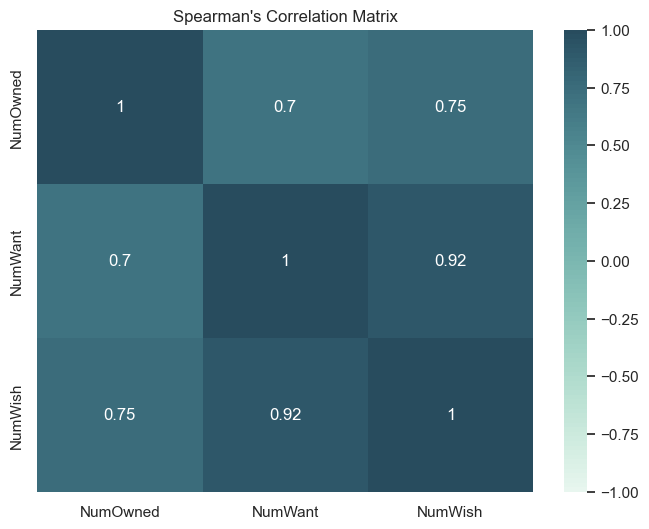

In [66]:
# Create the correlation matrix
corr = df[['NumOwned', 'NumWant', 'NumWish']].corr(method='spearman')

# Create a custom cubehelix palette where higher correlations have stronger colors
palette = sns.cubehelix_palette(
    start=2.7,
    rot=-0.2,
    light=0.15,  # Darker on the lower end of the scale
    dark=0.92,   # Lighter on the higher end of the scale
    gamma=0.7,
    n_colors=100,  # Set to a number suitable for the heatmap colors
    reverse=True   # Reverse the color palette so high correlations are more intense
)

# Plot the Spearman's correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap=palette, vmin=-1, vmax=1)
plt.title("Spearman's Correlation Matrix")
plt.show()


`NumOwned` and `NumWant`:  
A moderate positive correlation (0.70) suggests that games with more owners are also more likely to be wanted. However, this relationship is not extremely strong, indicating that some games may be owned but not widely desired, or vice versa. 

`NumOwned` and `NumWish`:  
A strong positive correlation (0.76) indicates that popular games are often wishlisted by users, suggesting that owned games are also highly desired. 
 
`NumWant` and `NumWish`:  
The strongest correlation (0.92) indicates that the games users want are nearly identical to those they wishlisted, reflecting a high degree of similarity between these two features.  


In [69]:
def create_interestscore_and_drop(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a new feature 'InterestScore' as the average of NumOwned, NumWant, and NumWish.
    Then remove the original three columns from the DataFrame.

    Returns a copy of the dataframe with the new column added
    and the old columns removed.
    """

    needed_cols = ['NumWant', 'NumWish', "NumOwned"]

    # Check if all required columns exist
    for col in needed_cols:
        if col not in df.columns:
            print(f"Column '{col}' not found; cannot create InterestScore.")
            return df

    # Create the new feature as the mean of the three and put it in the 13rd position
    df_cleaned = df.copy()
    df_cleaned['InterestScore'] = df_cleaned[needed_cols].mean(axis=1)
    cols = df_cleaned.columns.tolist()
    cols.insert(12, cols.pop(cols.index('InterestScore')))
    df_cleaned = df_cleaned[cols]
    # Drop the original columns
    df_cleaned = df_cleaned.drop(columns=needed_cols)
    print("InterestScore created and original columns dropped successfully.")   
    return df_cleaned
df = create_interestscore_and_drop(df)


InterestScore created and original columns dropped successfully.


In [70]:
# Check on InterestScore
print("InterestScore - Statistiche:")
print(df['InterestScore'].describe())
print(f"\n99° percentile: {df['InterestScore'].quantile(0.99):.2f}")
print(f"Max: {df['InterestScore'].max():.2f}")
print(f"Valori > 10: {(df['InterestScore'] > 10).sum()}")

InterestScore - Statistiche:
count    21519.000000
mean       581.314730
std       2014.450849
min          2.000000
25%         61.000000
50%        128.666667
75%        362.333333
max      58817.000000
Name: InterestScore, dtype: float64

99° percentile: 8709.77
Max: 58817.00
Valori > 10: 21470


Skewness: 11.50
Kurtosis: 197.23


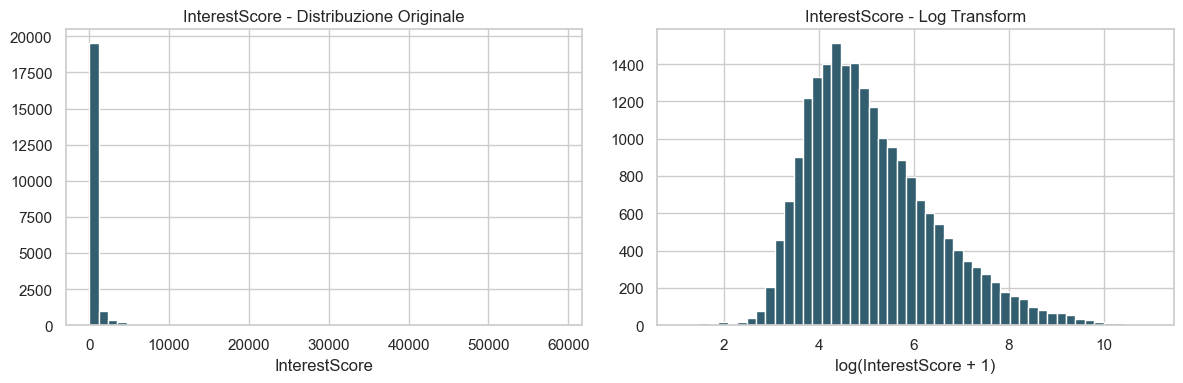

In [71]:
# Verifica la skewness
print(f"Skewness: {df['InterestScore'].skew():.2f}")
print(f"Kurtosis: {df['InterestScore'].kurtosis():.2f}")

# Distribuzione
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Istogramma originale
axes[0].hist(df['InterestScore'], bins=50)
axes[0].set_title('InterestScore - Distribuzione Originale')
axes[0].set_xlabel('InterestScore')

# Istogramma log
axes[1].hist(np.log1p(df['InterestScore']), bins=50)
axes[1].set_title('InterestScore - Log Transform')
axes[1].set_xlabel('log(InterestScore + 1)')

plt.tight_layout()
plt.show()

# `BestPlayers` & `GoodPlayers`

In [73]:
# Count how many missing values
missing_best = df["BestPlayers"].isna().sum()
missing_good = df["GoodPlayers"].isna().sum()
print("Missing values in BestPlayers:", missing_best)
print("Missing values in GoodPlayers:", missing_good)


print("\n=== Analysis of 0 and empty lists in 'BestPlayers' and 'GoodPlayers' ===")


# Count how many rows contain real information
best_nonzero = (df["BestPlayers"] > 0).sum()
print("Rows with BestPlayers > 0:", best_nonzero)

# Count GoodPlayers empty lists (assuming stored as string "[]")
empty_goodplayers = (df['GoodPlayers'] == '[]').sum()
print(f"The number of [] in GoodPlayers: {empty_goodplayers}")

# Count BestPlayers == 0
bestplayers_zero = (df['BestPlayers'] == 0).sum()
print(f"Rows with BestPlayers == 0: {bestplayers_zero}")


both_missing = ((df['GoodPlayers'] == '[]') & (df['BestPlayers'] == 0)).sum()
print(f"Both missing (empty list and 0): {both_missing}")



Missing values in BestPlayers: 0
Missing values in GoodPlayers: 0

=== Analysis of 0 and empty lists in 'BestPlayers' and 'GoodPlayers' ===
Rows with BestPlayers > 0: 1945
The number of [] in GoodPlayers: 19576
Rows with BestPlayers == 0: 19574
Both missing (empty list and 0): 19574


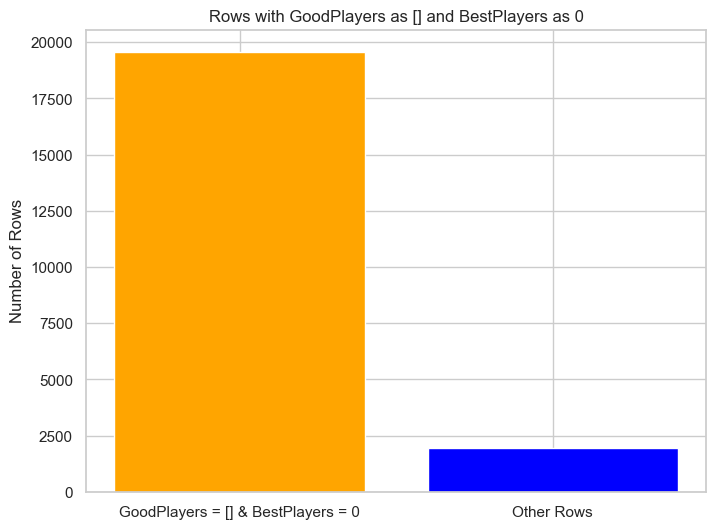

In [74]:
# Create a plot to visualize the number of rows with GoodPlayers as [] and BestPlayers as 0
labels = ['GoodPlayers = [] & BestPlayers = 0', 'Other Rows']
counts = [both_missing, len(df) - both_missing]
plt.figure(figsize=(8, 6))
plt.bar(labels, counts, color=['orange', 'blue'])
plt.title("Rows with GoodPlayers as [] and BestPlayers as 0")
plt.ylabel("Number of Rows")
plt.show()

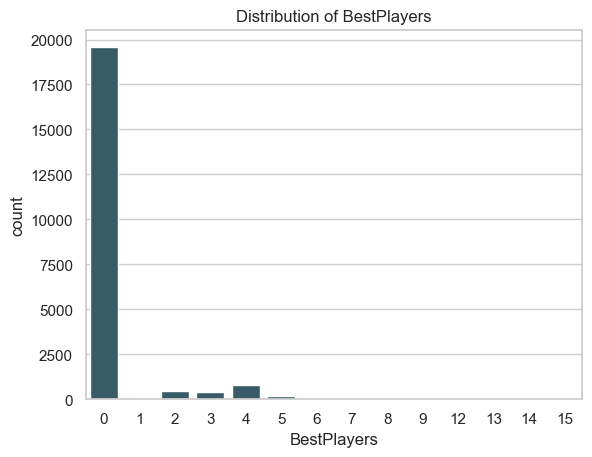

In [75]:
sns.countplot(x=df["BestPlayers"])
plt.title("Distribution of BestPlayers")
plt.show()


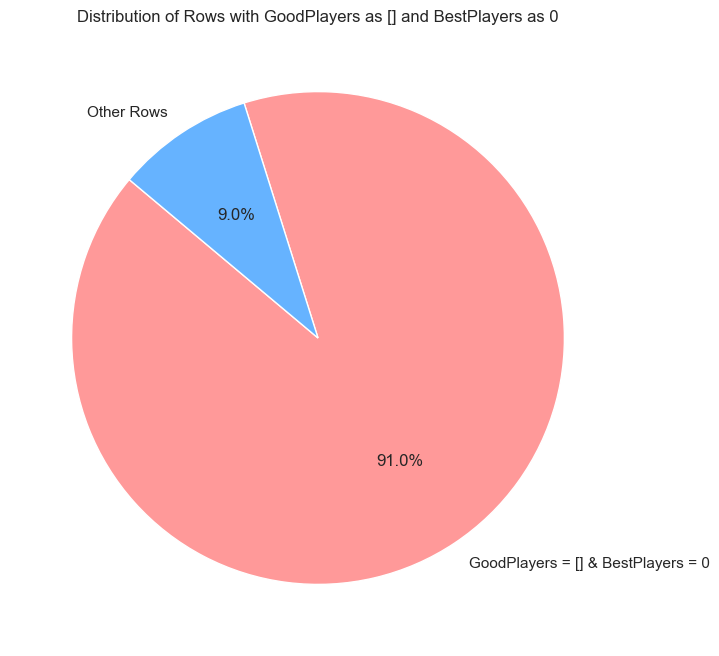

In [76]:
# Create a pie chart with the distribution of both_missing vs other rows
labels = ['GoodPlayers = [] & BestPlayers = 0', 'Other Rows']
sizes = [both_missing, len(df) - both_missing]
colors = ['#ff9999','#66b3ff']
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Rows with GoodPlayers as [] and BestPlayers as 0")
plt.show()

In [77]:
print(f"Total rows: {len(df)}")

print("Percentage of rows with both GoodPlayers as [] and BestPlayers as 0: "
      f"{both_missing/len(df)*100:.4f}%")

Total rows: 21519
Percentage of rows with both GoodPlayers as [] and BestPlayers as 0: 90.9615%


In [78]:
# Drop the features GoodPlayers and BestPlayers
def drop_good_best_players(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drop the columns GoodPlayers and BestPlayers from the dataframe.
    
    Returns a cleaned copy of the dataframe.
    """
    
    cleaned = df.drop(columns=['GoodPlayers', 'BestPlayers'])
    
    print("Columns GoodPlayers and BestPlayers dropped successfully.")
    return cleaned

df = drop_good_best_players(df)
df.columns

Columns GoodPlayers and BestPlayers dropped successfully.


Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'InterestScore',
       'NumWeightVotes', 'MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime',
       'MfgAgeRec', 'NumUserRatings', 'NumAlternates', 'NumExpansions',
       'NumImplementations', 'IsReimplementation', 'Kickstarted', 'ImagePath',
       'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS',
       'Cat:Abstract', 'Cat:Party', 'Cat:Childrens', 'Rating'],
      dtype='object')

# `MfgPlaytime`, `ComMinPlaytime` & `ComMaxPlaytime`

- Imputed all the zeros with the global median of each feature.
- After a thorough analysis of both correlation patterns and missing-value distributions, it became clear that MfgPlaytime and ComMaxPlaytime are perfect duplicates (identical values and identical missing patterns). Therefore, MfgPlaytime was removed as redundant.  
- Finally, a unified playtime feature was created by averaging ComMinPlaytime and ComMaxPlaytime, resulting in the new column PlaytimeComAvg, which provides a cleaner and more robust estimate of a game's typical duration.





In [79]:
# Esplore MfgPlayTime, ComMinPlaytime and ComMaxPlayTime
# Calculate descriptive statistics
stats_playtime = df[['MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime']].agg(['min', 'max', 'mean', 'median', 'std'])
print("Descriptive Statistics for Playtime Features:")
print(stats_playtime)
# Check for missing values
missing_playtime = df[['MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime']].isna().sum()
print("\nMissing Values in Playtime Features:")
print(missing_playtime)
# Check for unique values
unique_playtime = df[['MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime']].nunique()
print("\nUnique Values in Playtime Features:")
print(unique_playtime)
# Count how many times zero appears in each of the playtime features
zeros_playtime = (df[['MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime']] == 0).sum()
print("\nZero Values in Playtime Features:")
print(zeros_playtime)

Descriptive Statistics for Playtime Features:
         MfgPlaytime  ComMinPlaytime  ComMaxPlaytime
min         0.000000        0.000000        0.000000
max     60000.000000    60000.000000    60000.000000
mean       91.523491       64.257447       91.523491
median     45.000000       30.000000       45.000000
std       534.553601      448.040319      534.553601

Missing Values in Playtime Features:
MfgPlaytime       0
ComMinPlaytime    0
ComMaxPlaytime    0
dtype: int64

Unique Values in Playtime Features:
MfgPlaytime       121
ComMinPlaytime     90
ComMaxPlaytime    121
dtype: int64

Zero Values in Playtime Features:
MfgPlaytime       739
ComMinPlaytime    612
ComMaxPlaytime    739
dtype: int64


Distribution of zeros in the features

Step 1: Imputing all the zeros with the median of each feature

In [80]:
# Calcola la mediana escludendo gli zeri
median_mfgplaytime = df[df['MfgPlaytime'] > 0]['MfgPlaytime'].median() if (df['MfgPlaytime'] > 0).any() else 0
median_comminplaytime = df[df['ComMinPlaytime'] > 0]['ComMinPlaytime'].median() if (df['ComMinPlaytime'] > 0).any() else 0
median_commaxplaytime = df[df['ComMaxPlaytime'] > 0]['ComMaxPlaytime'].median() if (df['ComMaxPlaytime'] > 0).any() else 0

# Sostituisci gli zeri con la mediana calcolata per ciascuna colonna
df['MfgPlaytime'] = df['MfgPlaytime'].replace(0, median_mfgplaytime)
df['ComMinPlaytime'] = df['ComMinPlaytime'].replace(0, median_comminplaytime)
df['ComMaxPlaytime'] = df['ComMaxPlaytime'].replace(0, median_commaxplaytime)



# Verify the changes
print(f"Median value used for MfgPlaytime imputation: {median_mfgplaytime}")
print(f"Median value used for ComMinPlaytime imputation: {median_comminplaytime}")
print(f"Median value used for ComMaxPlaytime imputation: {median_commaxplaytime}")
print(df[['MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime']].head())  # Sample the first few rows

Median value used for MfgPlaytime imputation: 45.0
Median value used for ComMinPlaytime imputation: 30.0
Median value used for ComMaxPlaytime imputation: 45.0
   MfgPlaytime  ComMinPlaytime  ComMaxPlaytime
0           30              30              30
1           20              15              20
2          150              30             150
3           20              20              20
4           20              15              20


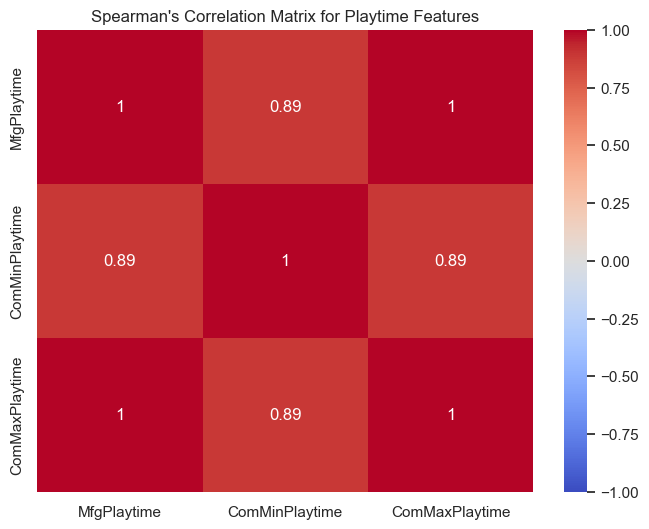

Spearman's Correlation Matrix for Playtime Features:
                MfgPlaytime  ComMinPlaytime  ComMaxPlaytime
MfgPlaytime        1.000000        0.889313        1.000000
ComMinPlaytime     0.889313        1.000000        0.889313
ComMaxPlaytime     1.000000        0.889313        1.000000


In [81]:
# Sperman's correlation matrix for playtime features
corr_playtime = df[['MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime']].corr(method='spearman')
# Plot the Spearman's correlation matrix for playtime features
plt.figure(figsize=(8, 6))
sns.heatmap(corr_playtime, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Spearman's Correlation Matrix for Playtime Features")
plt.show()

# Calculate Sperman's correlation matrix for playtime features
corr_playtime = df[['MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime']].corr(method='spearman')
print("Spearman's Correlation Matrix for Playtime Features:")
print(corr_playtime)


## Outlier detection

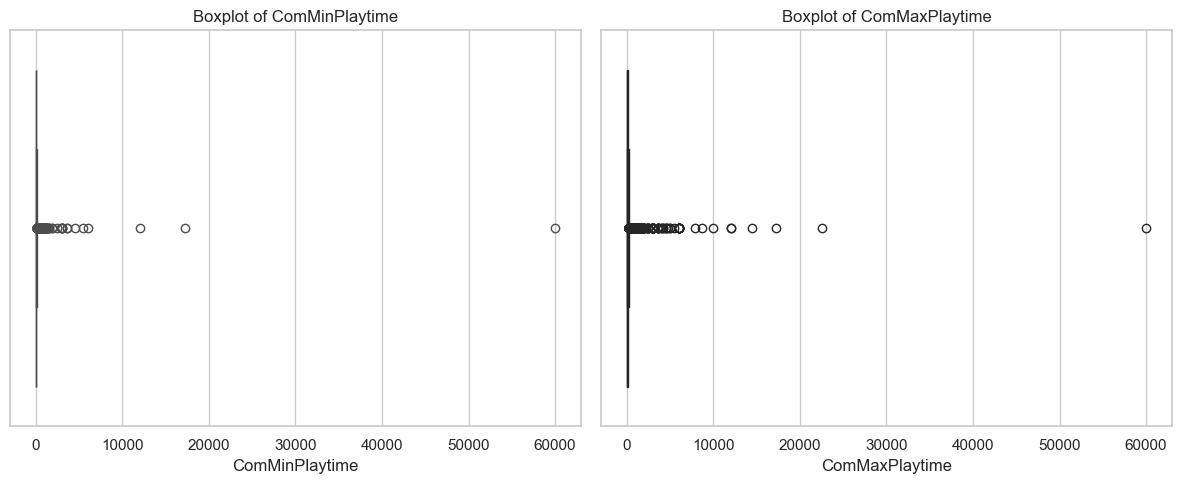

In [82]:
# Outliers di ComMinPlaytime e ComMaxPlaytime
plt.figure(figsize=(12, 5))
# Boxplot for ComMinPlaytime
plt.subplot(1, 2, 1)
sns.boxplot(x=df['ComMinPlaytime'], color='orange')
plt.title('Boxplot of ComMinPlaytime')
# Boxplot for ComMaxPlaytime
plt.subplot(1, 2, 2)
sns.boxplot(x=df['ComMaxPlaytime'], color='purple')
plt.title('Boxplot of ComMaxPlaytime')
plt.tight_layout()
plt.show()

In [83]:
# Count how many outliers in ComMinPlaytime and ComMaxPlaytime are greater than 20000
outliers_comminplaytime = (df['ComMinPlaytime'] > 10000).sum()
outliers_commaxplaytime = (df['ComMaxPlaytime'] > 10000).sum()
print(f"Number of outliers in ComMinPlaytime > 10000: {outliers_comminplaytime}")
print(f"Number of outliers in ComMaxPlaytime > 10000: {outliers_commaxplaytime}")

Number of outliers in ComMinPlaytime > 10000: 3
Number of outliers in ComMaxPlaytime > 10000: 6


Dropping the rows where ComMinPlaytime and ComMaxPlaytime > 10000

In [84]:
df = df[(df['ComMinPlaytime'] <= 10000) & (df['ComMaxPlaytime'] <= 10000)]
print(f"Number of outliers in ComMinPlaytime > 10000: {outliers_comminplaytime}")
print(f"Number of outliers in ComMaxPlaytime > 10000: {outliers_commaxplaytime}")


Number of outliers in ComMinPlaytime > 10000: 3
Number of outliers in ComMaxPlaytime > 10000: 6


Dropping MfgPlaytime since the correlation is 0.89

In [85]:
# Drop MfgPlaytime
def drop_mfgplaytime(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drop the column MfgPlaytime from the dataframe.
    
    Returns a cleaned copy of the dataframe.
    """
    
    cleaned = df.drop(columns=['MfgPlaytime'])
    
    print("Column MfgPlaytime dropped successfully.")
    return cleaned
df = drop_mfgplaytime(df)
# Verify that MfgPlaytime is dropped
print("Current columns in the dataframe:", df.columns)

Column MfgPlaytime dropped successfully.
Current columns in the dataframe: Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'InterestScore',
       'NumWeightVotes', 'ComMinPlaytime', 'ComMaxPlaytime', 'MfgAgeRec',
       'NumUserRatings', 'NumAlternates', 'NumExpansions',
       'NumImplementations', 'IsReimplementation', 'Kickstarted', 'ImagePath',
       'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS',
       'Cat:Abstract', 'Cat:Party', 'Cat:Childrens', 'Rating'],
      dtype='object')


Step 4: aggregating the two remaining features into a single one by averaging them

In [86]:
# 1. Create the averaged playtime column
df['PlaytimeComAvg'] = df[['ComMinPlaytime', 'ComMaxPlaytime']].mean(axis=1)

# 2. Move PlaytimeComAvg just before ComMinPlaytime
col_position = df.columns.get_loc('ComMinPlaytime')  # posizione corretta nel DF
df.insert(col_position, 'PlaytimeComAvg', df.pop('PlaytimeComAvg'))

# 3. Drop ComMinPlaytime and ComMaxPlaytime
def drop_complaytime(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drop the columns ComMinPlaytime and ComMaxPlaytime from the dataframe.
    Returns a cleaned copy of the dataframe.
    """
    
    cleaned = df.drop(columns=['ComMinPlaytime', 'ComMaxPlaytime'])
    
    print("Columns ComMinPlaytime and ComMaxPlaytime dropped successfully.")
    return cleaned

df = drop_complaytime(df)

# 4. Verify final column structure
print("Current columns in the dataframe:", df.columns)


Columns ComMinPlaytime and ComMaxPlaytime dropped successfully.
Current columns in the dataframe: Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'InterestScore',
       'NumWeightVotes', 'PlaytimeComAvg', 'MfgAgeRec', 'NumUserRatings',
       'NumAlternates', 'NumExpansions', 'NumImplementations',
       'IsReimplementation', 'Kickstarted', 'ImagePath', 'Cat:Thematic',
       'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract',
       'Cat:Party', 'Cat:Childrens', 'Rating'],
      dtype='object')


# `MfgAgeRec`

MfgAgeRec was dropped

In [87]:
# Calculate descriptive statistics
stats_playtime = df[['MfgAgeRec']].agg(['min', 'max', 'mean', 'median', 'std'])
print("Descriptive Statistics for MfgAgeRec:")
print(stats_playtime)
# Check for missing values
missing_playtime = df[['MfgAgeRec']].isna().sum()
print("\nMissing Values in MfgAgeRec:")
print(missing_playtime)
# Check for unique values
unique_playtime = df[['MfgAgeRec']].nunique()
print("\nUnique Values in MfgAgeRec:")
print(unique_playtime)
# Count how many times zero appears in each of the playtime features
zeros_playtime = (df[['MfgAgeRec']] == 0).sum()
print("\nZero Values in MfgAgeRec:", zeros_playtime)

Descriptive Statistics for MfgAgeRec:
        MfgAgeRec
min      0.000000
max     25.000000
mean     9.668247
median  10.000000
std      3.611344

Missing Values in MfgAgeRec:
MfgAgeRec    0
dtype: int64

Unique Values in MfgAgeRec:
MfgAgeRec    21
dtype: int64

Zero Values in MfgAgeRec: MfgAgeRec    1255
dtype: int64


In [88]:
# Create a df where MfgAgeRec == 0
zero_age_df = df[(df['MfgAgeRec'] == 0)]
print(f"Number of entries with MfgAgeRec = 0: {len(zero_age_df)}")
#zero_age_df

Number of entries with MfgAgeRec = 0: 1255


In [89]:
# Calculate the Correlation matrix for MfgAgeRec and ComAgeRec
corr_age = df[['MfgAgeRec', 'ComAgeRec']].corr(method='spearman')
print("Spearman's Correlation Matrix for Age Features:")
print(corr_age)

Spearman's Correlation Matrix for Age Features:
           MfgAgeRec  ComAgeRec
MfgAgeRec   1.000000   0.508286
ComAgeRec   0.508286   1.000000


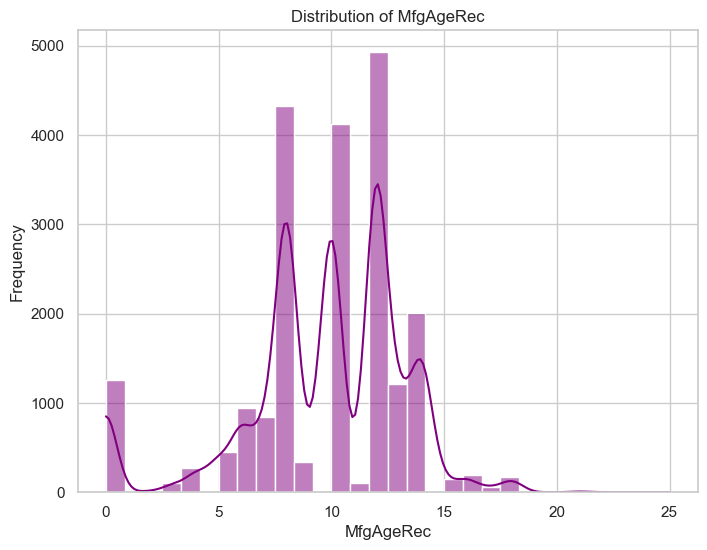

In [90]:
# Plot histogram
plt.figure(figsize=(8, 6))
sns.histplot(df['MfgAgeRec'], kde=True, color='purple', bins=30)
plt.title('Distribution of MfgAgeRec')
plt.xlabel('MfgAgeRec')
plt.ylabel('Frequency')
plt.show()

The manufacturer-recommended age (MfgAgeRec) showed a highly discrete, step-like distribution concentrated almost entirely around a few standard categories (6+, 8+, 10+, 12+, 14+). This pattern reflects marketing/legal conventions rather than the actual playability of the games.  
In contrast, the community-based age (ComAgeRec) is more granular, realistic, and already properly imputed.


### Why We Did Not Create a Combined Age Feature
After analyzing both age-related features (MfgAgeRec and ComAgeRec), we concluded that it does not make sense to combine them into a new feature. The manufacturer age (MfgAgeRec) shows a highly discrete, standardized distribution (6+, 8+, 10+, 12+, 14+), influenced by marketing and legal conventions rather than actual gameplay difficulty. It also contains over a thousand missing values and adds no meaningful granularity.
In contrast, the community-based age (ComAgeRec) is more detailed, realistic, and already properly imputed.   
**=> Combining a low-quality feature with a high-quality one would only introduce noise, reduce accuracy, and distort the signal.**

Dropping MfgAgeRec

In [91]:
# Drop MfgAgeRec
def drop_mfgagerec(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drop the column MfgAgeRec from the dataframe.
    
    Returns a cleaned copy of the dataframe.
    """
    
    cleaned = df.drop(columns=['MfgAgeRec'])
    
    print("Column MfgAgeRec dropped successfully.")
    return cleaned
df = drop_mfgagerec(df)
# Verify that MfgAgeRec is dropped
print("Current columns in the dataframe:", df.columns)


Column MfgAgeRec dropped successfully.
Current columns in the dataframe: Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'InterestScore',
       'NumWeightVotes', 'PlaytimeComAvg', 'NumUserRatings', 'NumAlternates',
       'NumExpansions', 'NumImplementations', 'IsReimplementation',
       'Kickstarted', 'ImagePath', 'Cat:Thematic', 'Cat:Strategy', 'Cat:War',
       'Cat:Family', 'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens',
       'Rating'],
      dtype='object')


# `IsReimplementation`



===== VALUE COUNTS =====
IsReimplementation
0    18967
1     2546
Name: count, dtype: int64

===== PERCENTAGES =====
IsReimplementation
0    88.165295
1    11.834705
Name: proportion, dtype: float64

===== MISSING VALUES =====
Missing values in IsReimplementation: 0


/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_5160/2132383122.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=["#4c72b0", "#dd8452"])


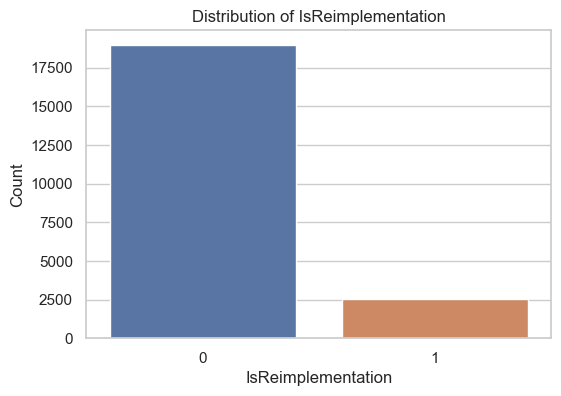


===== SPEARMAN CORRELATION WITH COUNT FEATURES =====
                    IsReimplementation  NumAlternates  NumExpansions  \
IsReimplementation            1.000000       0.055545       0.083699   
NumAlternates                 0.055545       1.000000       0.055982   
NumExpansions                 0.083699       0.055982       1.000000   
NumImplementations            0.679380       0.131253       0.153334   

                    NumImplementations  
IsReimplementation            0.679380  
NumAlternates                 0.131253  
NumExpansions                 0.153334  
NumImplementations            1.000000  


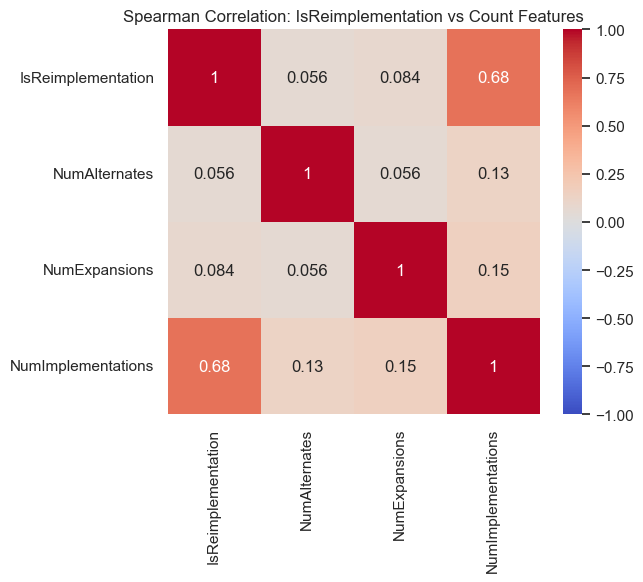

In [92]:
# 1. BASIC DISTRIBUTION
# ===============================
print("===== VALUE COUNTS =====")
counts = df['IsReimplementation'].value_counts(dropna=False)
print(counts)

print("\n===== PERCENTAGES =====")
percentages = df['IsReimplementation'].value_counts(normalize=True) * 100
print(percentages)

print("\n===== MISSING VALUES =====")
missing_isreimpl = df['IsReimplementation'].isna().sum()
print(f"Missing values in IsReimplementation: {missing_isreimpl}")

# 2. PLOT DISTRIBUTION
# ===============================

plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette=["#4c72b0", "#dd8452"])
plt.title("Distribution of IsReimplementation")
plt.xlabel("IsReimplementation")
plt.ylabel("Count")
plt.xticks([0,1])
plt.show()

# 3. CHECK CORRELATION WITH COUNT FEATURES
# ===============================

cols_to_check = ['NumAlternates', 'NumExpansions', 'NumImplementations']

print("\n===== SPEARMAN CORRELATION WITH COUNT FEATURES =====")
corr_matrix = df[['IsReimplementation'] + cols_to_check].corr(method='spearman')
print(corr_matrix)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Spearman Correlation: IsReimplementation vs Count Features")
plt.show()


# `NumAlternates`, `NumExpansions` & `NumImplementations `  



In [93]:
# Columns to analyze
cols = ['NumAlternates', 'NumExpansions', 'NumImplementations']

# 1. Descriptive statistics
stats_counts = df[cols].agg(['min', 'max', 'mean', 'median', 'std'])
print("Descriptive Statistics for Alternate/Expansion/Implementation Counts:")
print(stats_counts)

# 2. Missing values
missing_counts = df[cols].isna().sum()
print("\nMissing Values:")
print(missing_counts)

# 3. Unique values
unique_counts = df[cols].nunique()
print("\nUnique Values:")
print(unique_counts)

# 4. Zero counts
zero_counts = (df[cols] == 0).sum()
print("\nZero Values:")
print(zero_counts)


Descriptive Statistics for Alternate/Expansion/Implementation Counts:
        NumAlternates  NumExpansions  NumImplementations
min          0.000000       0.000000            0.000000
max        850.000000     525.000000           38.000000
mean         1.339051       1.402408            0.307163
median       0.000000       0.000000            0.000000
std          7.435670       7.770645            0.825526

Missing Values:
NumAlternates         0
NumExpansions         0
NumImplementations    0
dtype: int64

Unique Values:
NumAlternates         51
NumExpansions         99
NumImplementations    22
dtype: int64

Zero Values:
NumAlternates         12850
NumExpansions         15955
NumImplementations    16713
dtype: int64


In [94]:
# quanti giochi hanno valori > 0
for col in cols:
    count_nonzero = (df[col] > 0).sum()
    print(f"Number of entries with {col} > 0: {count_nonzero}")

# Outliers 
print("\n")
print("=====Outliers Detection=====")

for col in ['NumAlternates', 'NumExpansions', 'NumImplementations']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    outliers = df[df[col] > upper_bound][col]
    print(f"\nOutliers in {col}:")
    print(outliers.describe())


# Correlation matrix Sperman
print("\n")
print("=====Spearman's Correlation Matrix=====")
corr_counts = df[cols].corr(method='spearman')
print("Spearman's Correlation Matrix for Alternate/Expansion/Implementation Counts:")
print(corr_counts)

Number of entries with NumAlternates > 0: 8663
Number of entries with NumExpansions > 0: 5558
Number of entries with NumImplementations > 0: 4800


=====Outliers Detection=====

Outliers in NumAlternates:
count    3261.000000
mean        6.695186
std        18.130923
min         3.000000
25%         3.000000
50%         5.000000
75%         7.000000
max       850.000000
Name: NumAlternates, dtype: float64

Outliers in NumExpansions:
count    2177.000000
mean       11.858521
std        21.744130
min         3.000000
25%         4.000000
50%         6.000000
75%        11.000000
max       525.000000
Name: NumExpansions, dtype: float64

Outliers in NumImplementations:
count    4800.000000
mean        1.376667
std         1.257856
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        38.000000
Name: NumImplementations, dtype: float64


=====Spearman's Correlation Matrix=====
Spearman's Correlation Matrix for Alternate/Expansion/Implementation Counts

The three count-based features (NumAlternates, NumExpansions, NumImplementations) exhibit highly right-skewed distributions with many zeros and a set of large but realistic outliers (e.g., 850 alternates, 525 expansions). 
These extreme values correspond to highly popular or long-standing games and are not data errors.  
The features show minimal correlation (Spearman < 0.15), indicating that each captures independent aspects of the game's ecosystem. 
Zero values are meaningful and represent the absence of alternates/expansions, not missing data.

### Log transformation of NumAlternates, NumExpansions, NumImplementations

In [97]:
df['NumAlternates_log'] = np.log1p(df['NumAlternates'])
df['NumExpansions_log'] = np.log1p(df['NumExpansions'])
df['NumImplementations_log'] = np.log1p(df['NumImplementations'])
# Move the new columns just after the original ones
for col in ['NumAlternates_log', 'NumExpansions_log', 'NumImplementations_log']:
    col_position = df.columns.get_loc(col.replace('_log', '')) + 1
    df.insert(col_position, col, df.pop(col))


### Log features boxplot 

/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_5160/2848745229.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_log[c] for c in cols], labels=cols, showfliers=True)


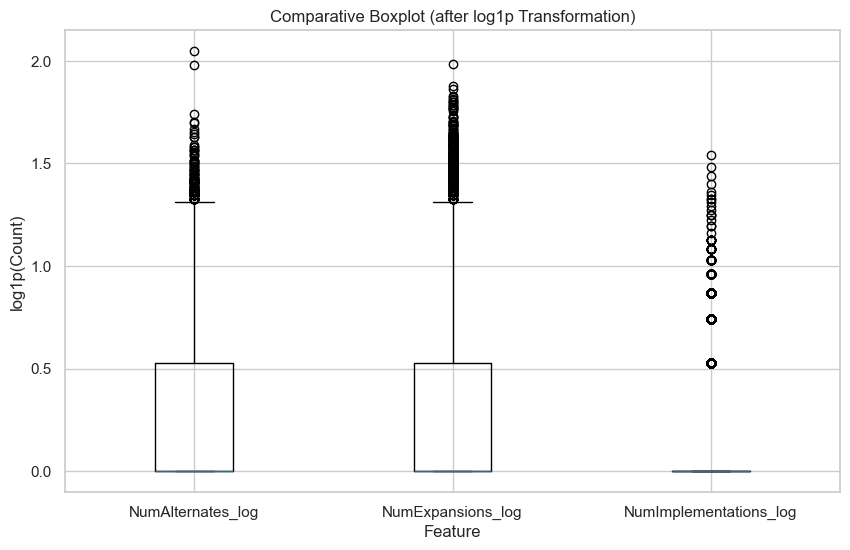

In [98]:
cols = ['NumAlternates_log', 'NumExpansions_log', 'NumImplementations_log']

# Apply log1p (log(1+x)) to avoid issues with zeros
df_log = df[cols].apply(np.log1p)

plt.figure(figsize=(10, 6))
plt.boxplot([df_log[c] for c in cols], labels=cols, showfliers=True)
plt.title("Comparative Boxplot (after log1p Transformation)")
plt.ylabel("log1p(Count)")
plt.xlabel("Feature")
plt.show()


# `NumUserRatings` & `NumWeightVotes`

In [99]:
# Columns to analyze
cols1 = ['NumUserRatings', 'NumWeightVotes']

# 1. Descriptive statistics
stats_counts1 = df[cols1].agg(['min', 'max', 'mean', 'median', 'std'])
print("Descriptive Statistics for NumUserRatings and NumWeightVotes:")
print(stats_counts1)

# 2. Missing values
missing_counts1 = df[cols1].isna().sum()
print("\nMissing Values:")
print(missing_counts1)

# 3. Unique values
unique_counts1 = df[cols1].nunique()
print("\nUnique Values:")
print(unique_counts1)

# 4. Zero counts
zero_counts1 = (df[cols1] == 0).sum()
print("\nZero Values:")
print(zero_counts1)


# Outliers
print("\n")
print("=====Outliers Detection=====")

for col in ['NumUserRatings', 'NumWeightVotes']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    outliers = df[df[col] > upper_bound][col]
    print(f"\nOutliers in {col}:")
    print(outliers.describe())




Descriptive Statistics for NumUserRatings and NumWeightVotes:
        NumUserRatings  NumWeightVotes
min          30.000000        0.000000
max      108101.000000     7673.000000
mean        860.698880       49.117231
median      123.000000        9.000000
std        3645.457766      205.282529

Missing Values:
NumUserRatings    0
NumWeightVotes    0
dtype: int64

Unique Values:
NumUserRatings    3097
NumWeightVotes     761
dtype: int64

Zero Values:
NumUserRatings      0
NumWeightVotes    491
dtype: int64


=====Outliers Detection=====

Outliers in NumUserRatings:
count      3035.000000
mean       5024.420758
std        8591.815791
min         909.000000
25%        1350.500000
50%        2201.000000
75%        4607.500000
max      108101.000000
Name: NumUserRatings, dtype: float64

Outliers in NumWeightVotes:
count    2872.000000
mean      289.368384
std       498.109574
min        60.000000
25%        84.000000
50%       135.000000
75%       271.000000
max      7673.000000
Name: NumW

/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_5160/846269916.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_log1[c] for c in cols1], labels=cols1, showfliers=True)


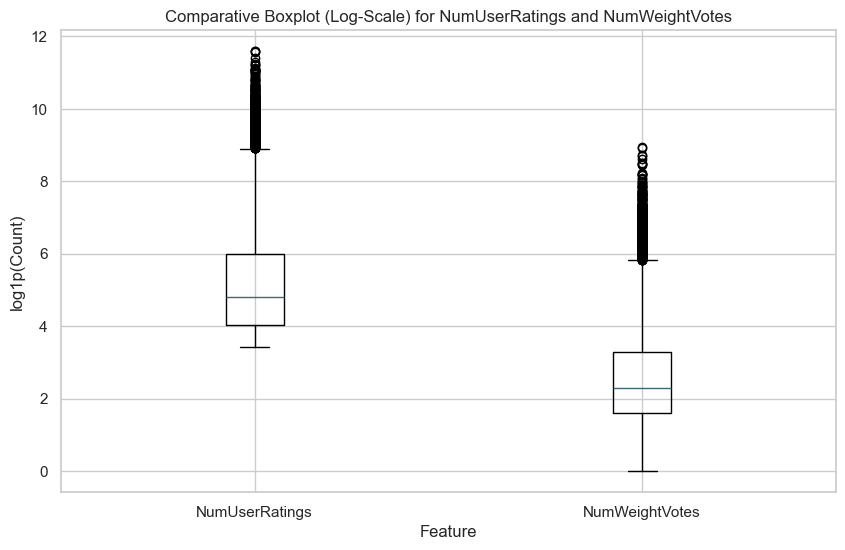

In [100]:
# create a boxplot of NumUserRatings and NumWeightVotes log-transformed
cols1 = ['NumUserRatings', 'NumWeightVotes']
# Apply log1p (log(1+x)) to avoid issues with zeros
df_log1 = df[cols1].apply(np.log1p)
plt.figure(figsize=(10, 6))
plt.boxplot([df_log1[c] for c in cols1], labels=cols1, showfliers=True)
plt.title("Comparative Boxplot (Log-Scale) for NumUserRatings and NumWeightVotes")
plt.ylabel("log1p(Count)")
plt.xlabel("Feature")
plt.show()

In [101]:
df["log_NumUserRatings"] = np.log1p(df["NumUserRatings"])
df["log_NumWeightVotes"] = np.log1p(df["NumWeightVotes"])
# Move the new columns just after the original ones
for col in ["log_NumUserRatings", "log_NumWeightVotes"]:
    col_position = df.columns.get_loc(col.replace("log_", "")) + 1
    df.insert(col_position, col, df.pop(col))
    



# OUTLIERS DETECTION


In [102]:
def detect_outliers_iqr(data, column):
    """Rileva outliers usando il metodo IQR (Interquartile Range)"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [103]:
def detect_outliers_iqr(data, column):
    """Rileva outliers usando il metodo IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    print("=" * 70)
    print("METODO IQR (Interquartile Range)")
    print("=" * 70)
    print(f"Q1 (25°percentile): {Q1:,.2f}")
    print(f"Q3 (75°percentile): {Q3:,.2f}")
    print(f"IQR: {IQR:,.2f}")
    print(f"Lower bound: {lower_bound:,.2f}")
    print(f"Upper bound: {upper_bound:,.2f}")
    print(f"\nOutliers trovati: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
    print(f"Valori normali: {len(data) - len(outliers)} ({(len(data)-len(outliers))/len(data)*100:.2f}%)")
    
    if len(outliers) > 0:
        print(f"\nRange outliers: [{outliers[column].min():,.2f}, {outliers[column].max():,.2f}]")
        print(f"Media outliers: {outliers[column].mean():,.2f}")
    
    return outliers, lower_bound, upper_bound

In [104]:
def plot_kde_detailed(data, column, outliers_iqr, lower_bound, upper_bound):
    """Visualizza KDE con outliers evidenziati"""
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # 1. KDE Plot con outliers
    ax1 = axes[0]
    sns.kdeplot(data=data[column], fill=True, ax=ax1, color='steelblue', alpha=0.6)
    
    if len(outliers_iqr) > 0:
        ax1.scatter(outliers_iqr[column], 
                   np.zeros_like(outliers_iqr[column]), 
                   color='red', s=80, alpha=0.7, 
                   label=f'Outliers IQR ({len(outliers_iqr)})', 
                   zorder=5, marker='x')
    
    ax1.axvline(lower_bound, color='orange', linestyle='--', linewidth=2, 
                alpha=0.7, label='IQR bounds')
    ax1.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, alpha=0.7)
    ax1.set_title(f'KDE Plot - {column}', fontsize=16, fontweight='bold')
    ax1.set_xlabel(column, fontsize=12)
    ax1.set_ylabel('Densità', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 2. Box Plot
    ax2 = axes[1]
    sns.boxplot(x=data[column], ax=ax2, color='lightblue')
    ax2.set_title(f'Box Plot - {column}', fontsize=16, fontweight='bold')
    ax2.set_xlabel(column, fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # 3. Histogram con KDE
    ax3 = axes[2]
    ax3.hist(data[column], bins=50, alpha=0.5, color='steelblue', 
             edgecolor='black', density=True, label='Histogram')
    
    # Aggiungi KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data[column].dropna())
    x_range = np.linspace(data[column].min(), data[column].max(), 1000)
    ax3.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
    
    ax3.axvline(lower_bound, color='orange', linestyle='--', linewidth=2, alpha=0.7)
    ax3.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, alpha=0.7)
    ax3.set_title(f'Histogram + KDE - {column}', fontsize=16, fontweight='bold')
    ax3.set_xlabel(column, fontsize=12)
    ax3.set_ylabel('Densità', fontsize=12)
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 70)
    print("GRAFICO GENERATO")
    print("=" * 70)
    print("✓ KDE Plot con outliers evidenziati (rosso)")
    print("✓ Box Plot")
    print("✓ Histogram con KDE sovrapposta")

In [105]:
def plot_comparison_kde(data, original_col, log_col):
    """Confronta distribuzione originale vs log-trasformata"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. KDE Originale
    ax1 = axes[0, 0]
    sns.kdeplot(data=data[original_col], fill=True, ax=ax1, color='steelblue', alpha=0.6)
    ax1.set_title(f'KDE - Originale\n(Skew: {data[original_col].skew():.2f})', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel(original_col, fontsize=12)
    ax1.set_ylabel('Densità', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # 2. KDE Log-trasformato
    ax2 = axes[0, 1]
    sns.kdeplot(data=data[log_col], fill=True, ax=ax2, color='green', alpha=0.6)
    ax2.set_title(f'KDE - Log-Trasformato\n(Skew: {data[log_col].skew():.2f})', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel(log_col, fontsize=12)
    ax2.set_ylabel('Densità', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # 3. Histogram Originale
    ax3 = axes[1, 0]
    ax3.hist(data[original_col], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax3.set_title('Histogram - Originale', fontsize=14, fontweight='bold')
    ax3.set_xlabel(original_col, fontsize=12)
    ax3.set_ylabel('Frequenza', fontsize=12)
    ax3.grid(True, alpha=0.3)
    
    # 4. Histogram Log-trasformato
    ax4 = axes[1, 1]
    ax4.hist(data[log_col], bins=50, alpha=0.7, color='green', edgecolor='black')
    ax4.set_title('Histogram - Log-Trasformato', fontsize=14, fontweight='bold')
    ax4.set_xlabel(log_col, fontsize=12)
    ax4.set_ylabel('Frequenza', fontsize=12)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Outliers: NumWeightVotes

In [106]:
print("=" * 70)
print(f"STATISTICHE DESCRITTIVE - {"NumWeightVotes"}")
print("=" * 70)
print(df["NumWeightVotes"].describe())
print(f"\nSkewness: {df["NumWeightVotes"].skew():.3f}")
print(f"Kurtosis: {df["NumWeightVotes"].kurtosis():.3f}")

STATISTICHE DESCRITTIVE - NumWeightVotes
count    21513.000000
mean        49.117231
std        205.282529
min          0.000000
25%          4.000000
50%          9.000000
75%         26.000000
max       7673.000000
Name: NumWeightVotes, dtype: float64

Skewness: 15.549
Kurtosis: 375.442


In [107]:
outliers_iqr, lower_iqr, upper_iqr = detect_outliers_iqr(df, "NumWeightVotes")


METODO IQR (Interquartile Range)
Q1 (25°percentile): 4.00
Q3 (75°percentile): 26.00
IQR: 22.00
Lower bound: -29.00
Upper bound: 59.00

Outliers trovati: 2872 (13.35%)
Valori normali: 18641 (86.65%)

Range outliers: [60.00, 7,673.00]
Media outliers: 289.37


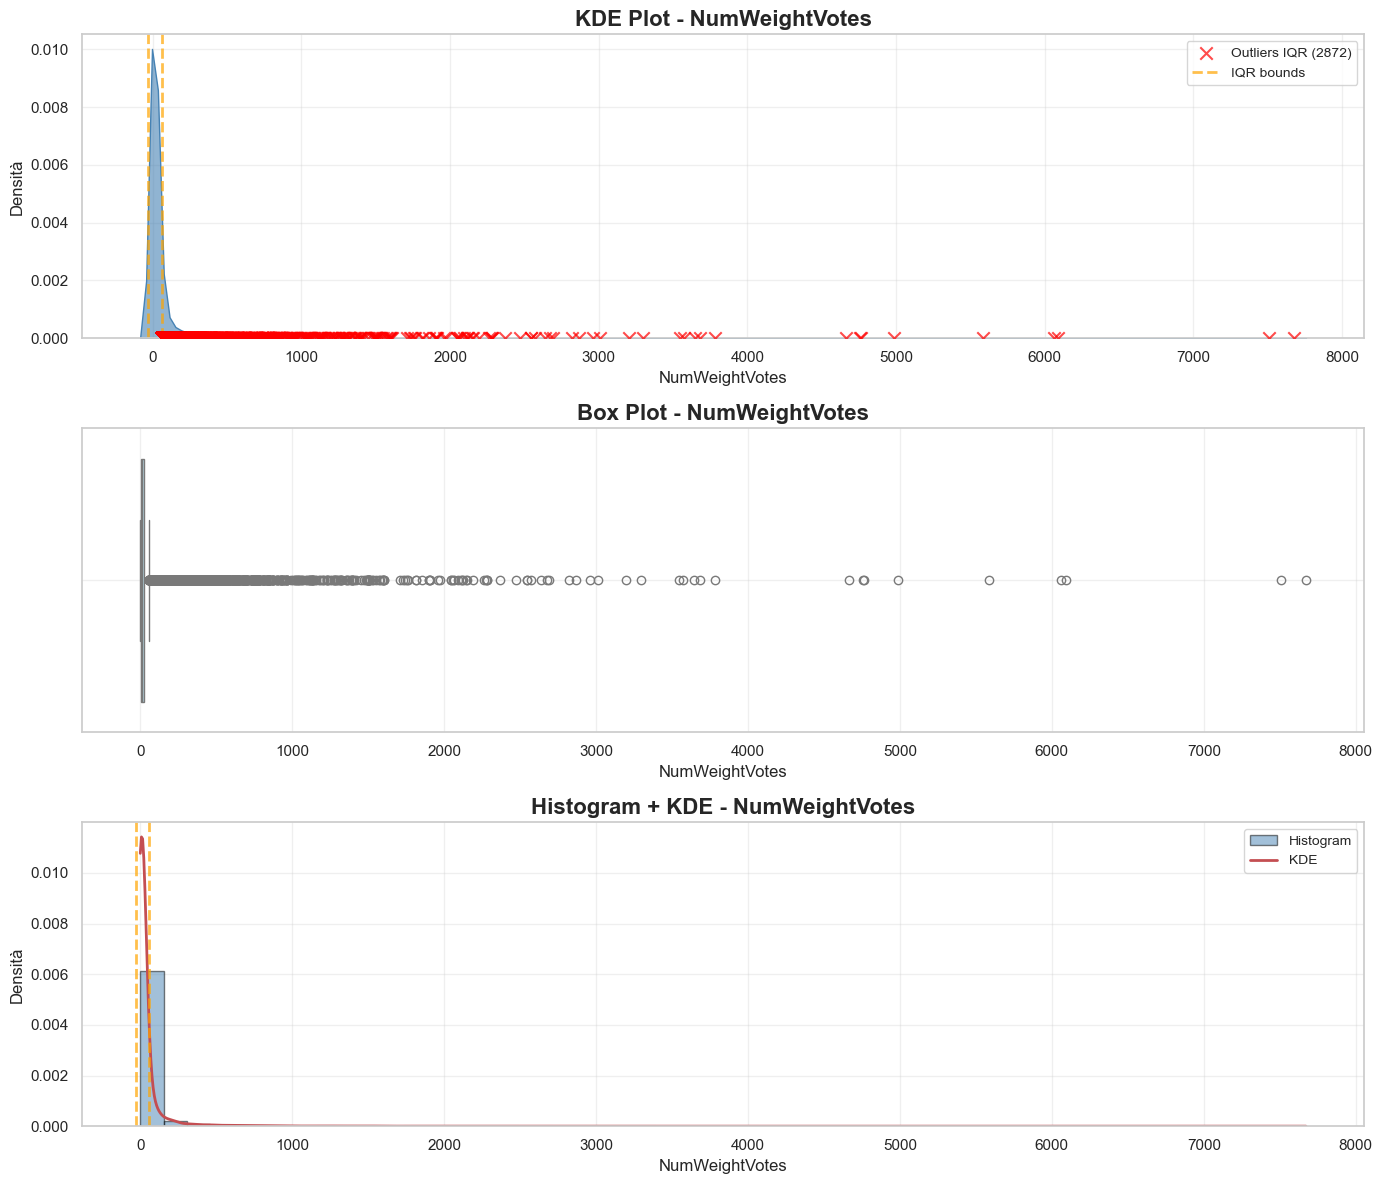


GRAFICO GENERATO
✓ KDE Plot con outliers evidenziati (rosso)
✓ Box Plot
✓ Histogram con KDE sovrapposta


In [108]:
plot_kde_detailed(df, "NumWeightVotes", outliers_iqr, lower_iqr, upper_iqr)

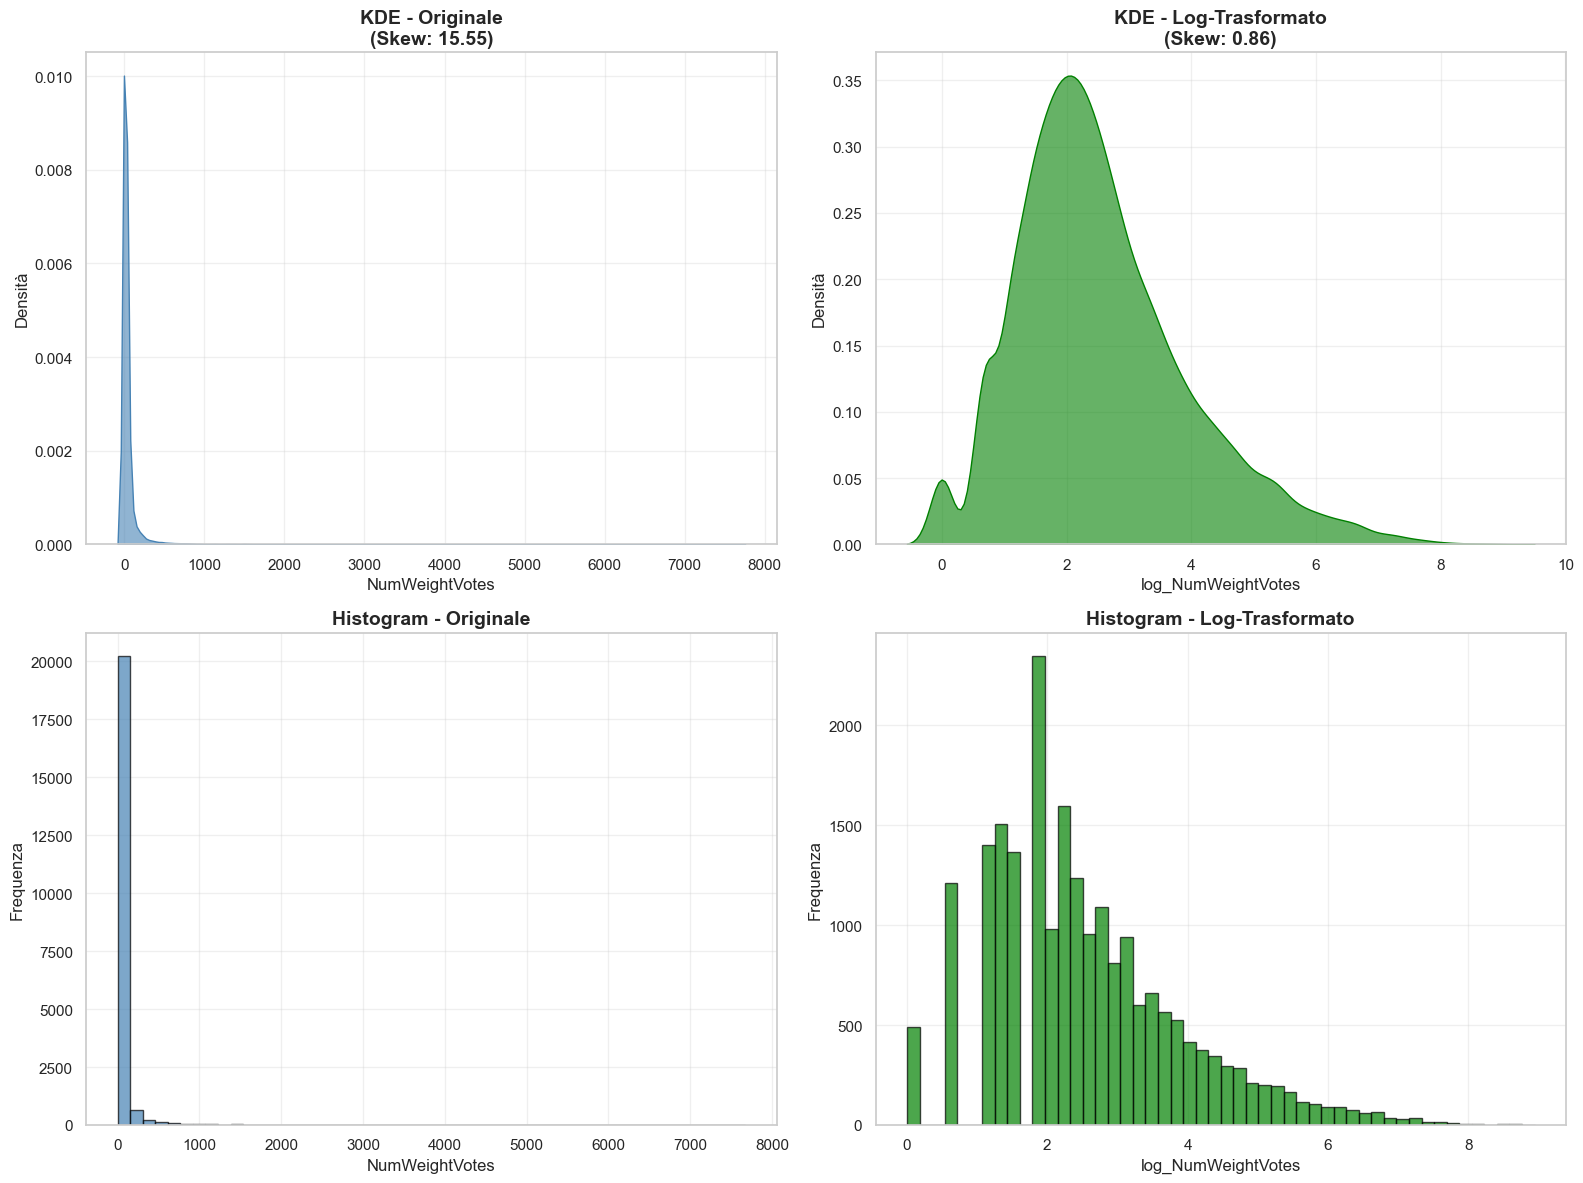

In [109]:
plot_comparison_kde(df, "NumWeightVotes", 'log_NumWeightVotes')


## NumWeightVotes - Distribution Analysis


### Skewness and Kurtosis after log transformation

In [110]:
print("=" * 70)
print(f"STATISTICHE DESCRITTIVE - {"log_NumWeightVotes"}")
print("=" * 70)
print(df["log_NumWeightVotes"].describe())
print(f"\nSkewness: {df["log_NumWeightVotes"].skew():.3f}")
print(f"Kurtosis: {df["log_NumWeightVotes"].kurtosis():.3f}")

STATISTICHE DESCRITTIVE - log_NumWeightVotes
count    21513.000000
mean         2.562085
std          1.371494
min          0.000000
25%          1.609438
50%          2.302585
75%          3.295837
max          8.945593
Name: log_NumWeightVotes, dtype: float64

Skewness: 0.862
Kurtosis: 0.920


## Outliers: NumUserRatings

In [111]:
print("=" * 70)
print(f"STATISTICHE DESCRITTIVE - {"NumUserRatings"}")
print("=" * 70)
print(df["NumUserRatings"].describe())
print(f"\nSkewness: {df["NumUserRatings"].skew():.3f}")
print(f"Kurtosis: {df["NumUserRatings"].kurtosis():.3f}")

STATISTICHE DESCRITTIVE - NumUserRatings
count     21513.000000
mean        860.698880
std        3645.457766
min          30.000000
25%          56.000000
50%         123.000000
75%         397.000000
max      108101.000000
Name: NumUserRatings, dtype: float64

Skewness: 12.669
Kurtosis: 233.673


In [112]:
outliers_iqr, lower_iqr, upper_iqr = detect_outliers_iqr(df, "NumUserRatings")


METODO IQR (Interquartile Range)
Q1 (25°percentile): 56.00
Q3 (75°percentile): 397.00
IQR: 341.00
Lower bound: -455.50
Upper bound: 908.50

Outliers trovati: 3035 (14.11%)
Valori normali: 18478 (85.89%)

Range outliers: [909.00, 108,101.00]
Media outliers: 5,024.42


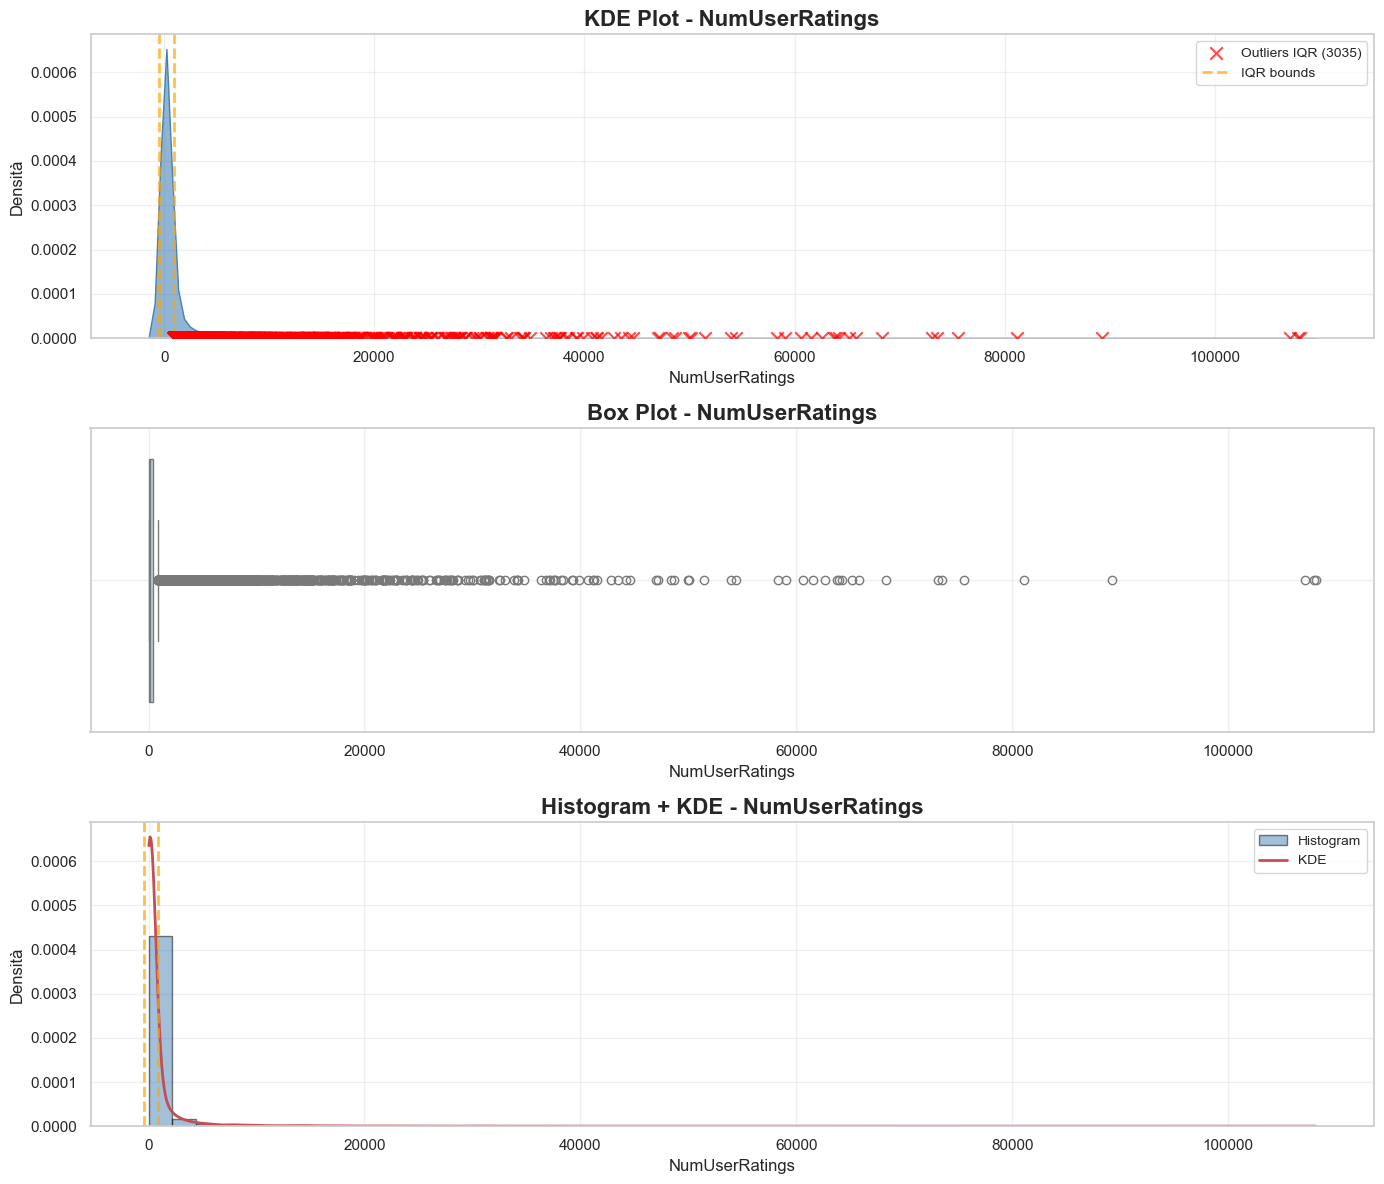


GRAFICO GENERATO
✓ KDE Plot con outliers evidenziati (rosso)
✓ Box Plot
✓ Histogram con KDE sovrapposta


In [113]:
plot_kde_detailed(df, "NumUserRatings", outliers_iqr, lower_iqr, upper_iqr)

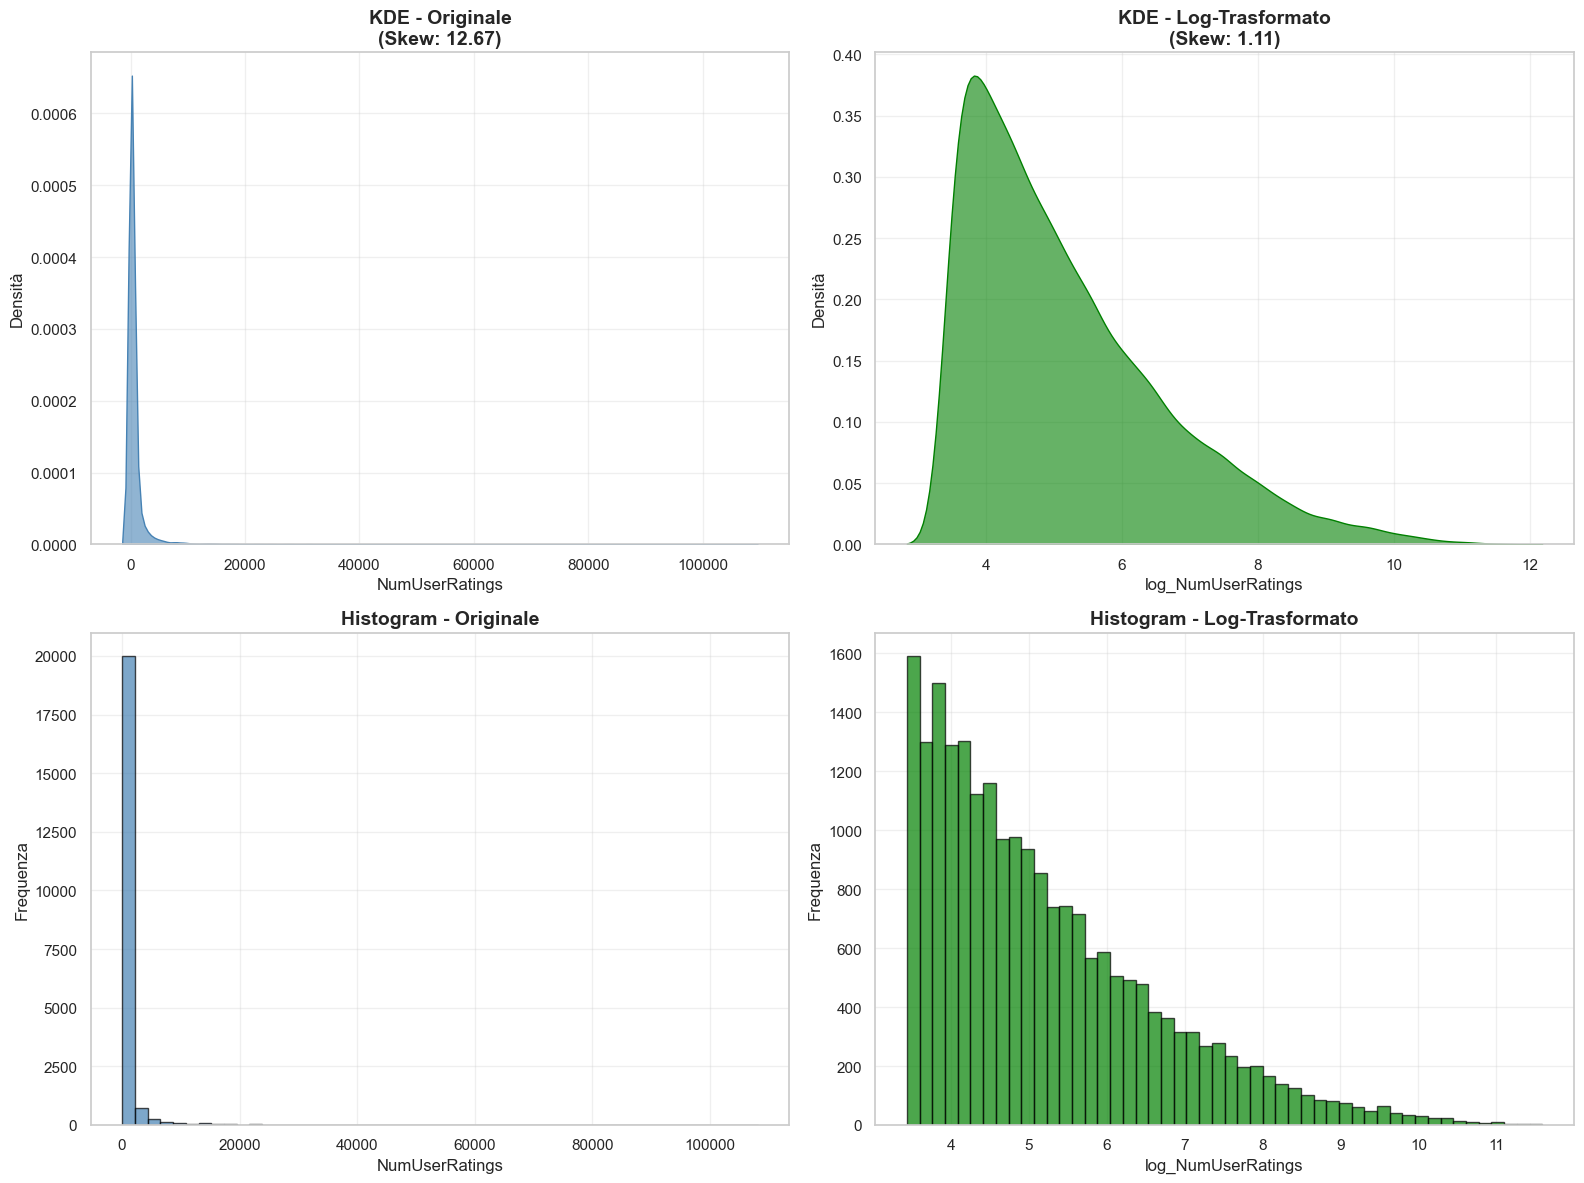

In [114]:
plot_comparison_kde(df, "NumUserRatings", 'log_NumUserRatings')


### Effect of log transformation

In [115]:
print("=" * 70)
print(f"STATISTICHE DESCRITTIVE - {"log_NumUserRatings"}")
print("=" * 70)
print(df["log_NumUserRatings"].describe())
print(f"\nSkewness: {df["log_NumUserRatings"].skew():.3f}")
print(f"Kurtosis: {df["log_NumUserRatings"].kurtosis():.3f}")

STATISTICHE DESCRITTIVE - log_NumUserRatings
count    21513.000000
mean         5.187112
std          1.444906
min          3.433987
25%          4.043051
50%          4.820282
75%          5.986452
max         11.590831
Name: log_NumUserRatings, dtype: float64

Skewness: 1.108
Kurtosis: 0.925


## Outliers: NumImplementations

In [116]:
print("=" * 70)
print(f"STATISTICHE DESCRITTIVE - {"NumImplementations"}")
print("=" * 70)
print(df["NumImplementations"].describe())
print(f"\nSkewness: {df["NumImplementations"].skew():.3f}")
print(f"Kurtosis: {df["NumImplementations"].kurtosis():.3f}")

STATISTICHE DESCRITTIVE - NumImplementations
count    21513.000000
mean         0.307163
std          0.825526
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         38.000000
Name: NumImplementations, dtype: float64

Skewness: 12.083
Kurtosis: 359.280


In [117]:
outliers_iqr, lower_iqr, upper_iqr = detect_outliers_iqr(df, "NumImplementations")


METODO IQR (Interquartile Range)
Q1 (25°percentile): 0.00
Q3 (75°percentile): 0.00
IQR: 0.00
Lower bound: 0.00
Upper bound: 0.00

Outliers trovati: 4800 (22.31%)
Valori normali: 16713 (77.69%)

Range outliers: [1.00, 38.00]
Media outliers: 1.38


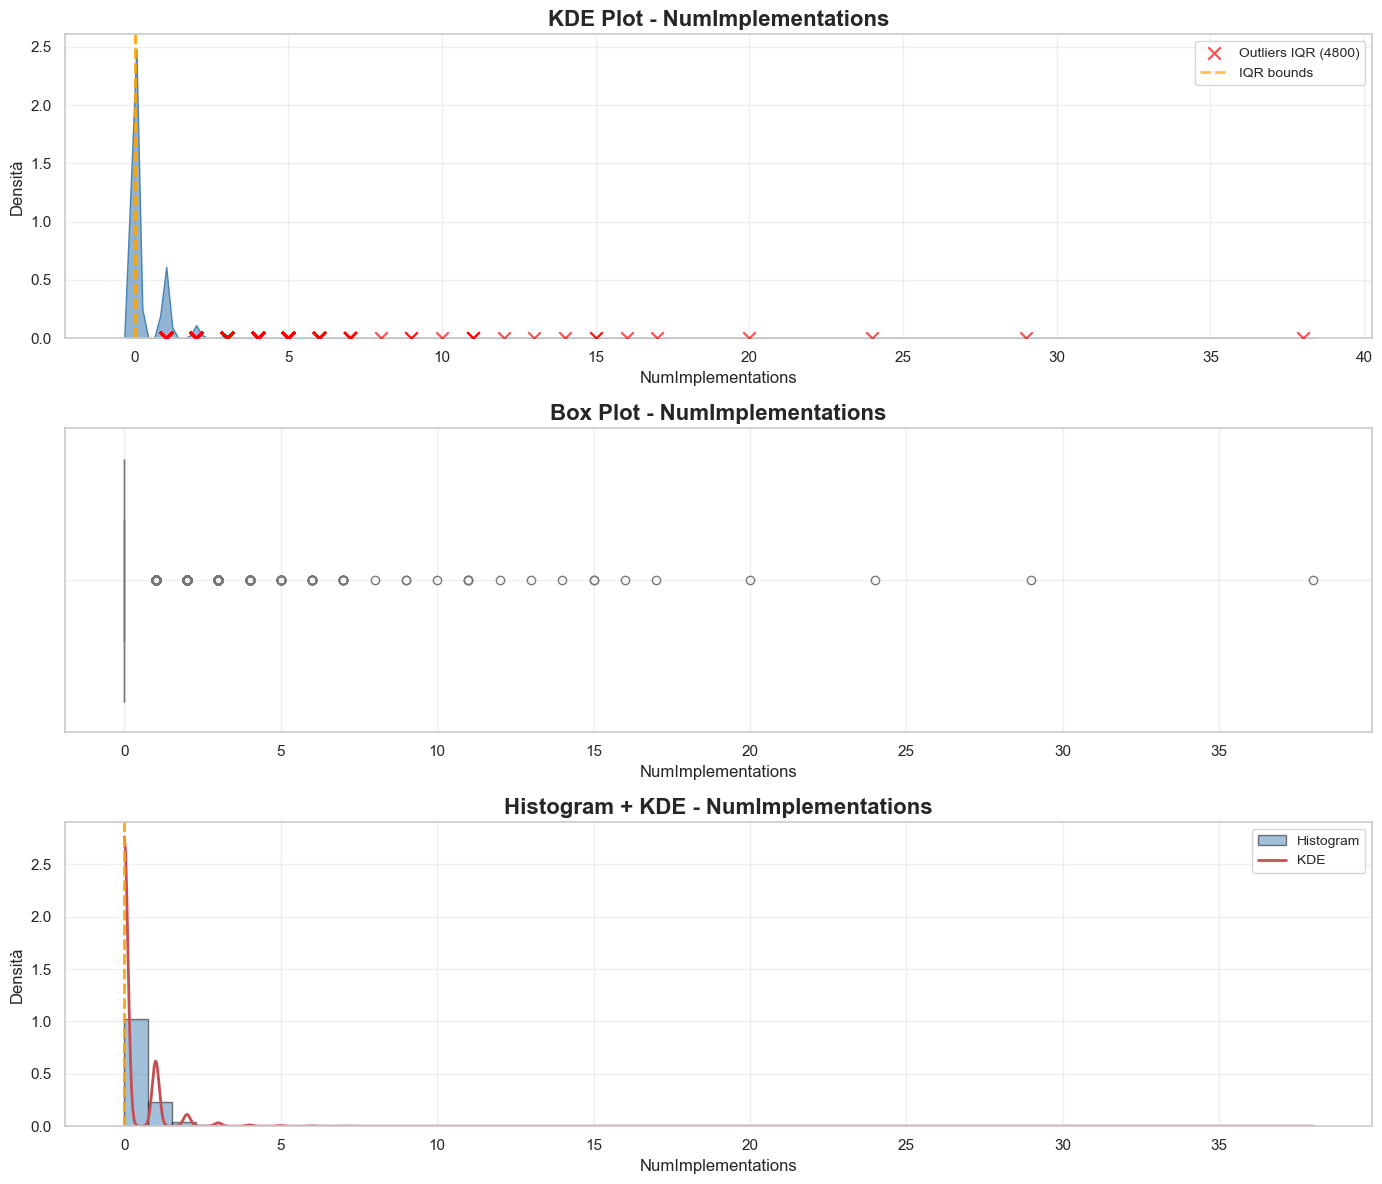


GRAFICO GENERATO
✓ KDE Plot con outliers evidenziati (rosso)
✓ Box Plot
✓ Histogram con KDE sovrapposta


In [118]:
plot_kde_detailed(df, "NumImplementations", outliers_iqr, lower_iqr, upper_iqr)

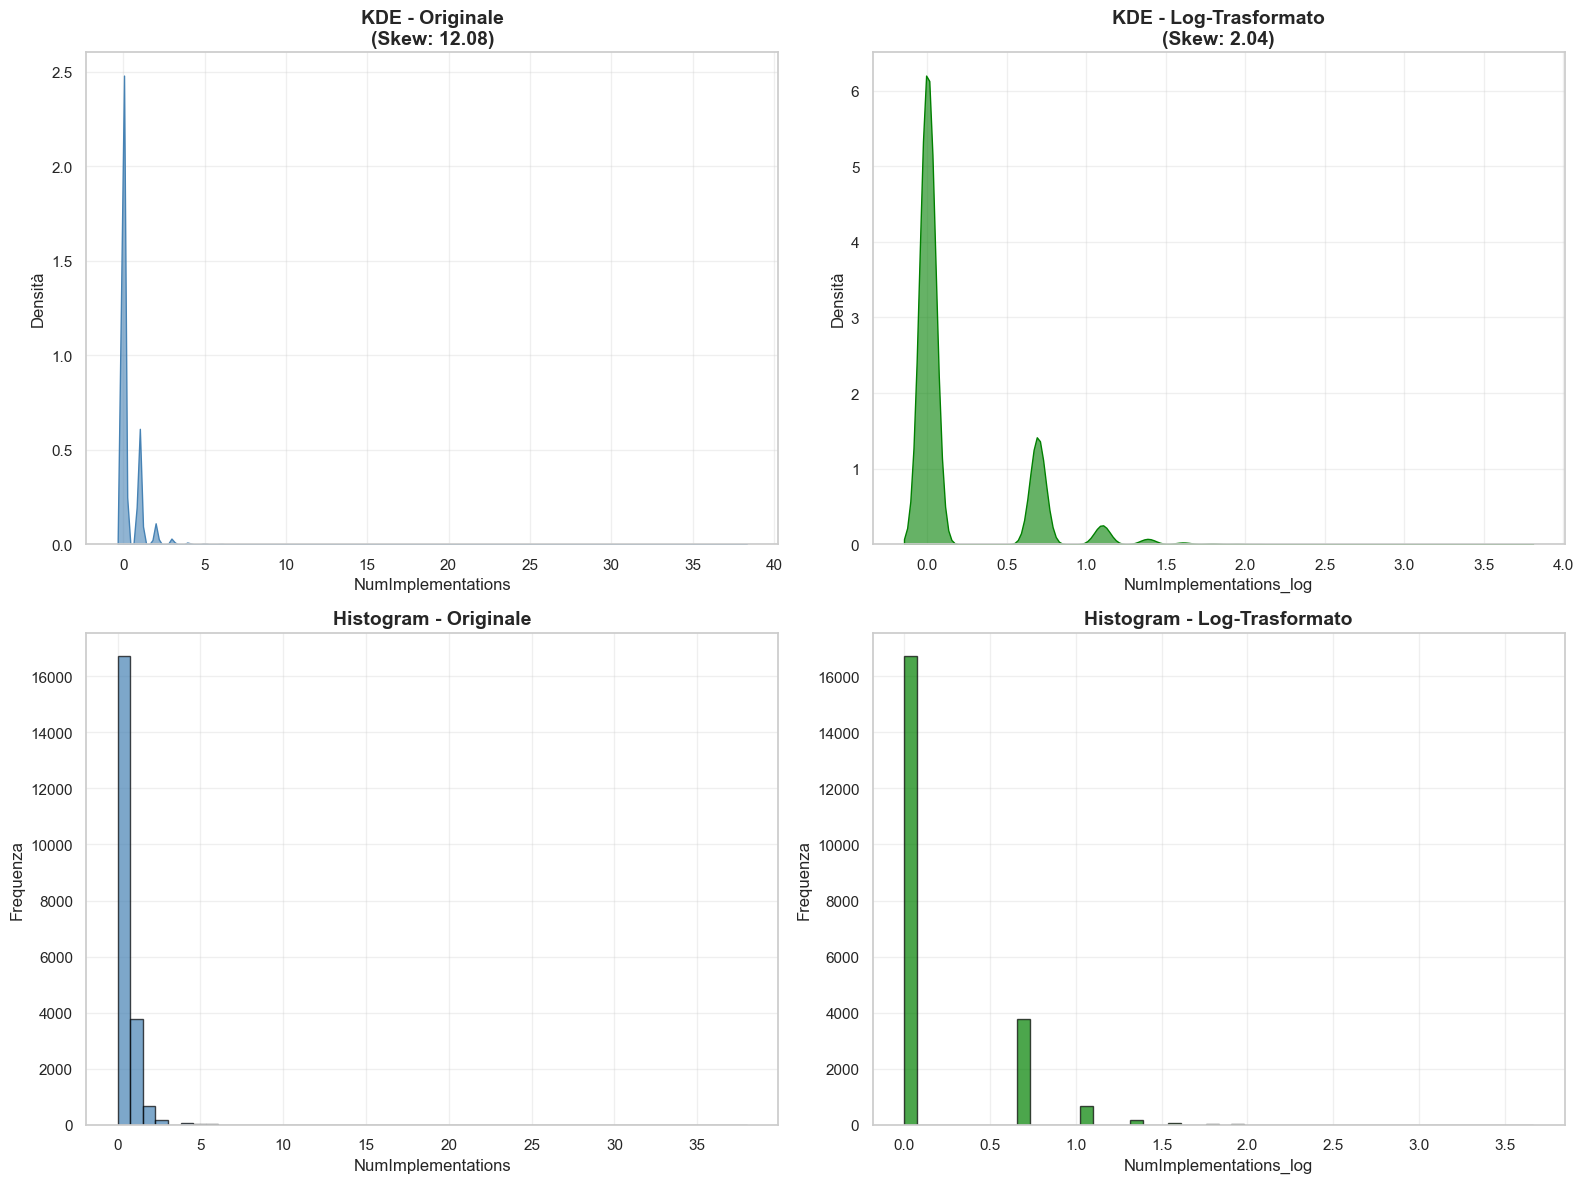

In [119]:
plot_comparison_kde(df, "NumImplementations", 'NumImplementations_log')


### Effect of log transformation

In [120]:
print("=" * 70)
print(f"STATISTICHE DESCRITTIVE - {"NumImplementations_log"}")
print("=" * 70)
print(df["NumImplementations_log"].describe())
print(f"\nSkewness: {df["NumImplementations_log"].skew():.3f}")
print(f"Kurtosis: {df["NumImplementations_log"].kurtosis():.3f}")

STATISTICHE DESCRITTIVE - NumImplementations_log
count    21513.000000
mean         0.181562
std          0.362301
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.663562
Name: NumImplementations_log, dtype: float64

Skewness: 2.036
Kurtosis: 4.651


## Outliers: NumExpansions

In [121]:
print("=" * 70)
print(f"STATISTICHE DESCRITTIVE - {"NumExpansions"}")
print("=" * 70)
print(df["NumExpansions"].describe())
print(f"\nSkewness: {df["NumExpansions"].skew():.3f}")
print(f"Kurtosis: {df["NumExpansions"].kurtosis():.3f}")

STATISTICHE DESCRITTIVE - NumExpansions
count    21513.000000
mean         1.402408
std          7.770645
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        525.000000
Name: NumExpansions, dtype: float64

Skewness: 24.743
Kurtosis: 1165.827


In [122]:
outliers_iqr, lower_iqr, upper_iqr = detect_outliers_iqr(df, "NumExpansions")


METODO IQR (Interquartile Range)
Q1 (25°percentile): 0.00
Q3 (75°percentile): 1.00
IQR: 1.00
Lower bound: -1.50
Upper bound: 2.50

Outliers trovati: 2177 (10.12%)
Valori normali: 19336 (89.88%)

Range outliers: [3.00, 525.00]
Media outliers: 11.86


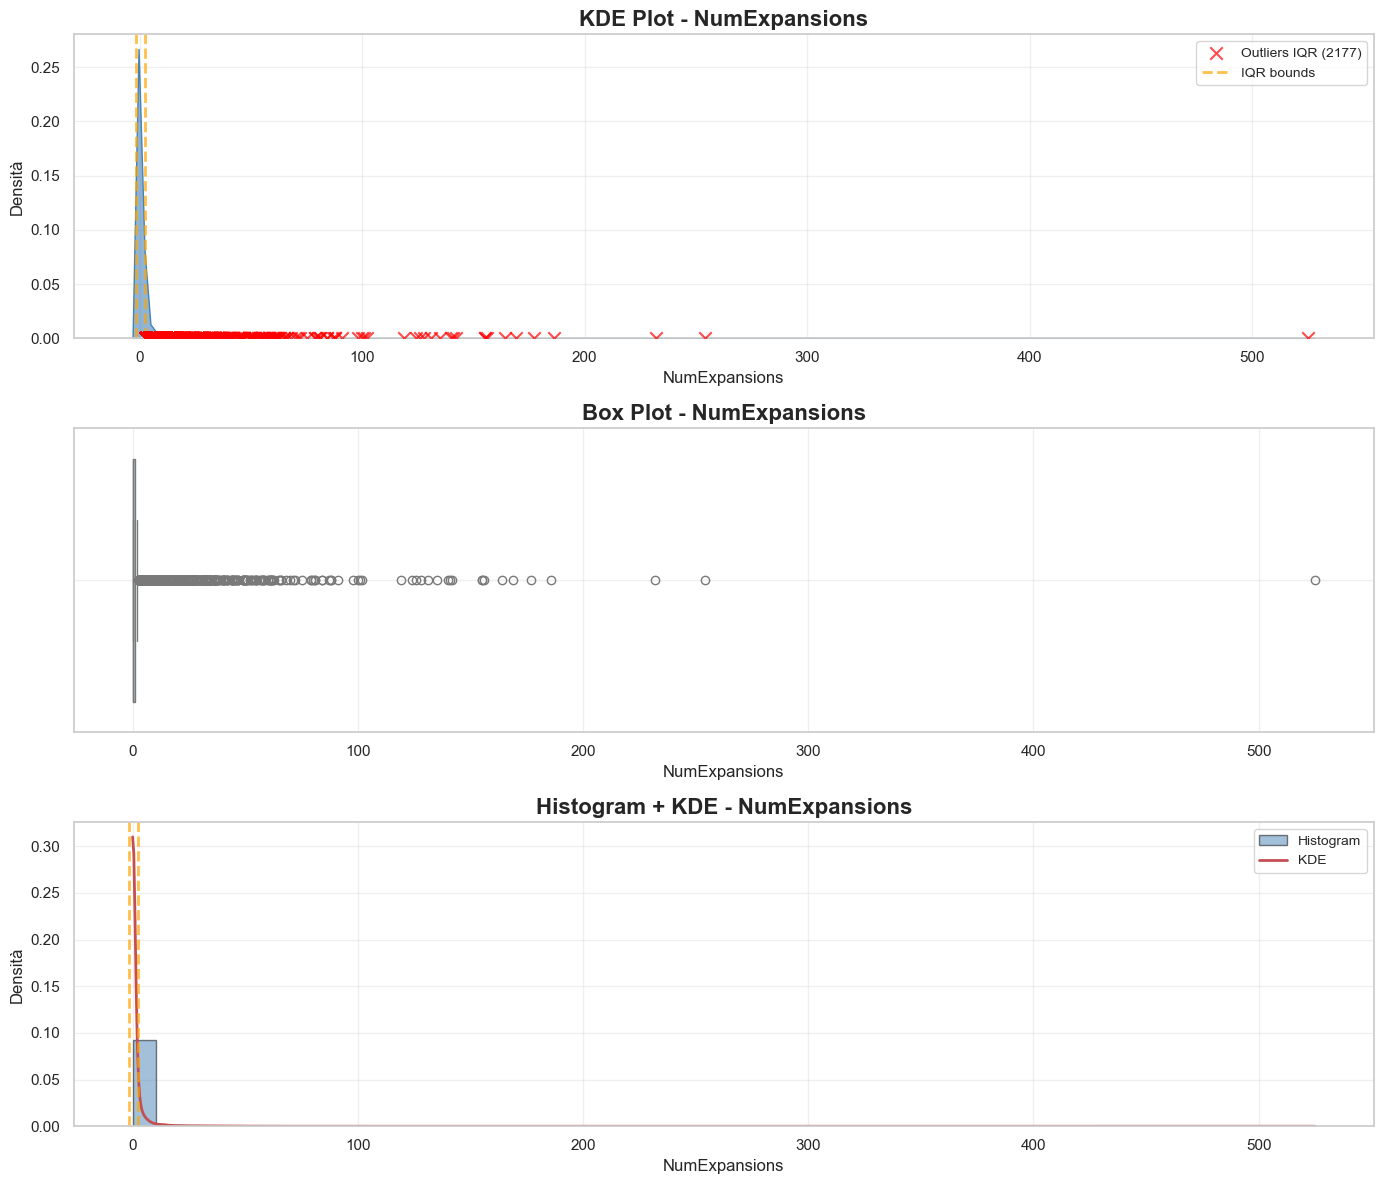


GRAFICO GENERATO
✓ KDE Plot con outliers evidenziati (rosso)
✓ Box Plot
✓ Histogram con KDE sovrapposta


In [123]:
plot_kde_detailed(df, "NumExpansions", outliers_iqr, lower_iqr, upper_iqr)

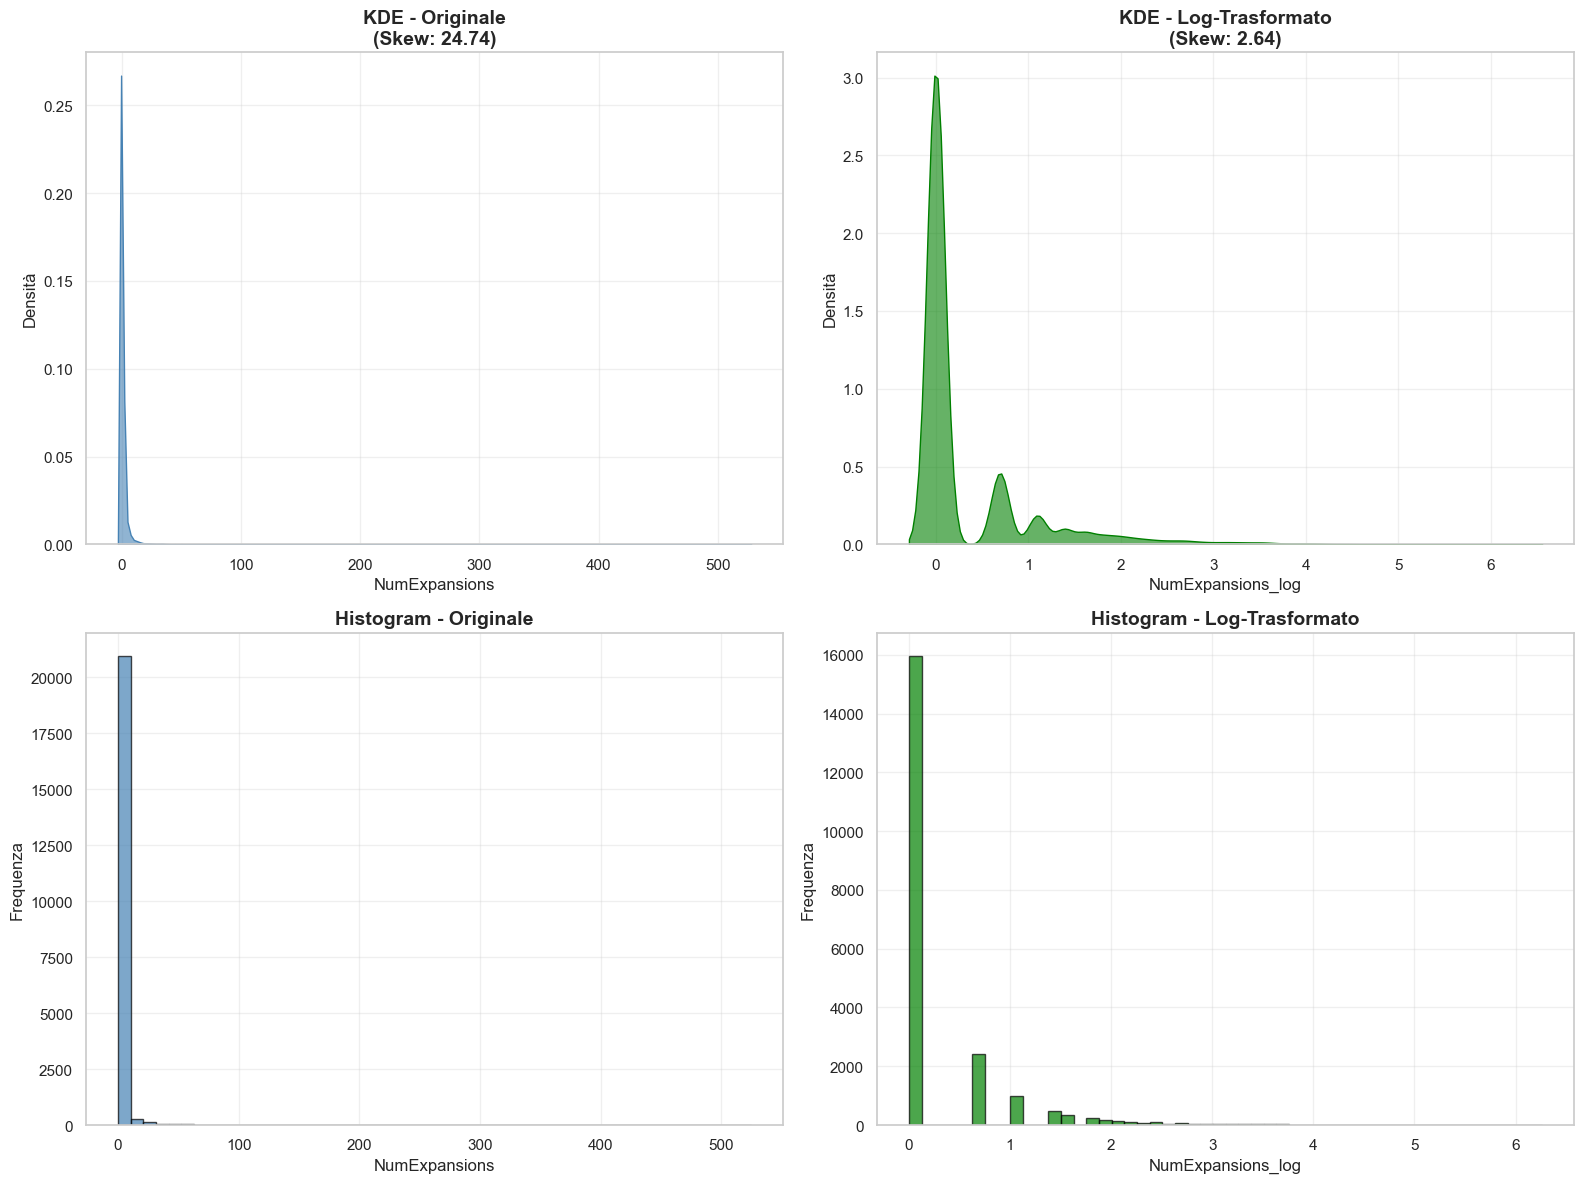

In [124]:
plot_comparison_kde(df, "NumExpansions", 'NumExpansions_log')


### Effect of log transformation

In [125]:
print("=" * 70)
print(f"STATISTICHE DESCRITTIVE - {"NumExpansions_log"}")
print("=" * 70)
print(df["NumExpansions_log"].describe())
print(f"\nSkewness: {df["NumExpansions_log"].skew():.3f}")
print(f"Kurtosis: {df["NumExpansions_log"].kurtosis():.3f}")

STATISTICHE DESCRITTIVE - NumExpansions_log
count    21513.000000
mean         0.342144
std          0.712988
min          0.000000
25%          0.000000
50%          0.000000
75%          0.693147
max          6.265301
Name: NumExpansions_log, dtype: float64

Skewness: 2.639
Kurtosis: 7.992


## Outliers: NumAlternates

In [126]:
print("=" * 70)
print(f"STATISTICHE DESCRITTIVE - {"NumAlternates"}")
print("=" * 70)
print(df["NumAlternates"].describe())
print(f"\nSkewness: {df["NumAlternates"].skew():.3f}")
print(f"Kurtosis: {df["NumAlternates"].kurtosis():.3f}")

STATISTICHE DESCRITTIVE - NumAlternates
count    21513.000000
mean         1.339051
std          7.435670
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        850.000000
Name: NumAlternates, dtype: float64

Skewness: 84.938
Kurtosis: 8935.563


In [127]:
outliers_iqr, lower_iqr, upper_iqr = detect_outliers_iqr(df, "NumAlternates")


METODO IQR (Interquartile Range)
Q1 (25°percentile): 0.00
Q3 (75°percentile): 1.00
IQR: 1.00
Lower bound: -1.50
Upper bound: 2.50

Outliers trovati: 3261 (15.16%)
Valori normali: 18252 (84.84%)

Range outliers: [3.00, 850.00]
Media outliers: 6.70


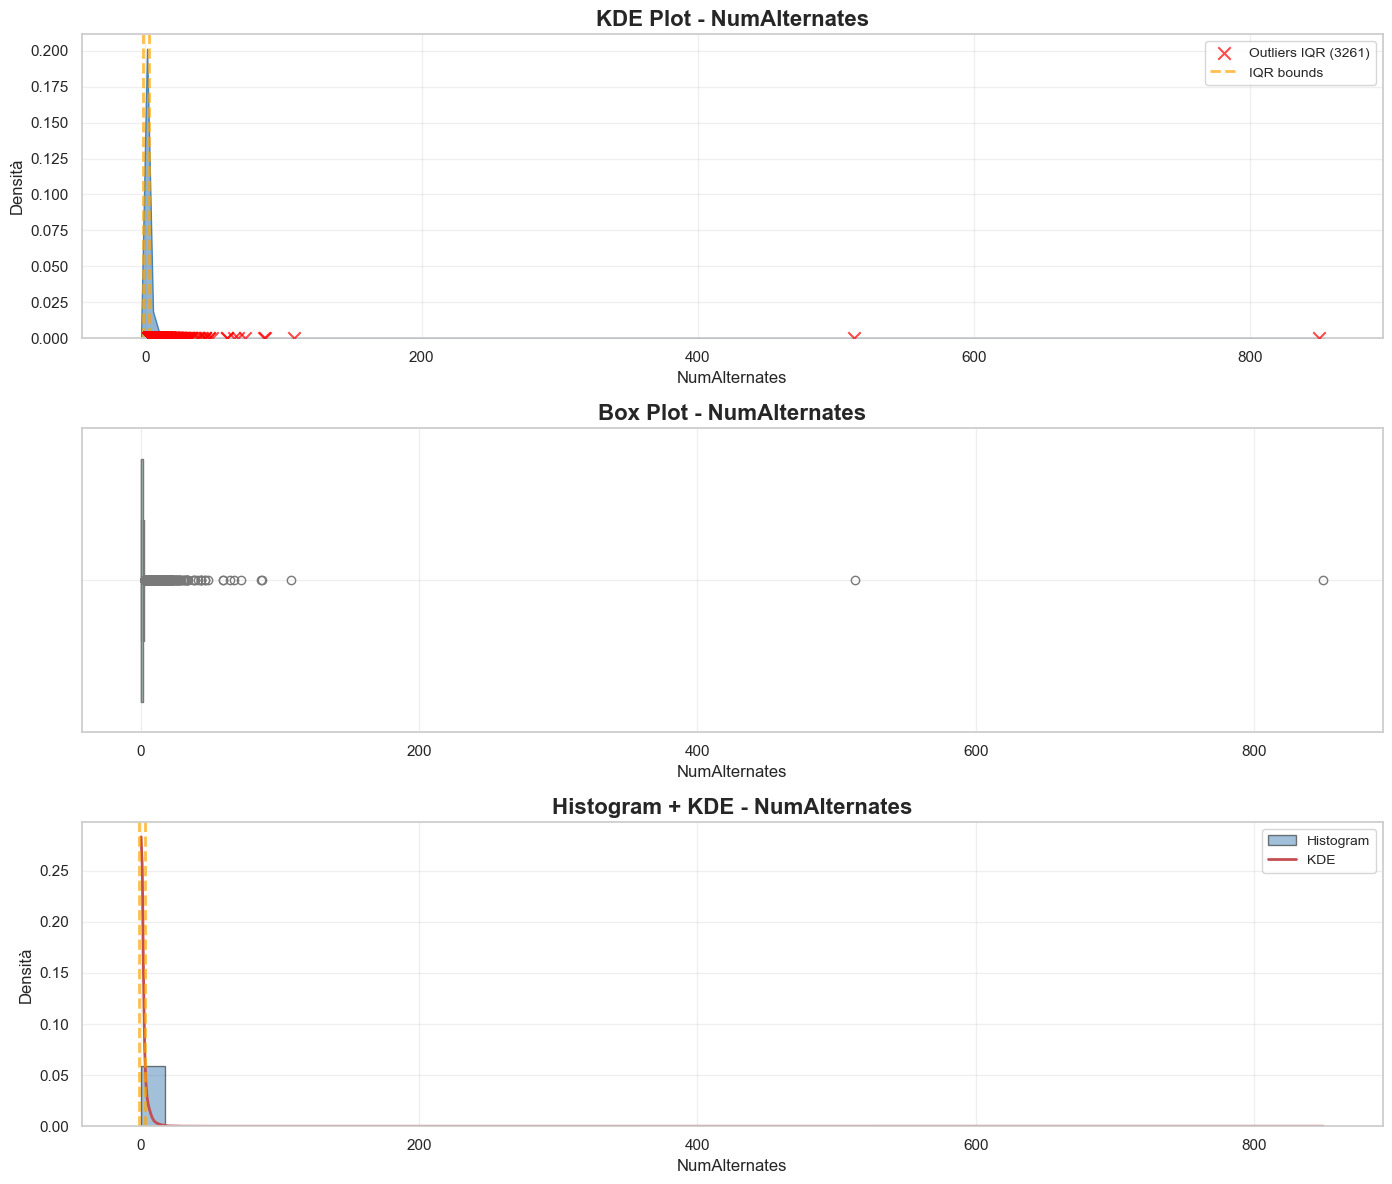


GRAFICO GENERATO
✓ KDE Plot con outliers evidenziati (rosso)
✓ Box Plot
✓ Histogram con KDE sovrapposta


In [128]:
plot_kde_detailed(df, "NumAlternates", outliers_iqr, lower_iqr, upper_iqr)

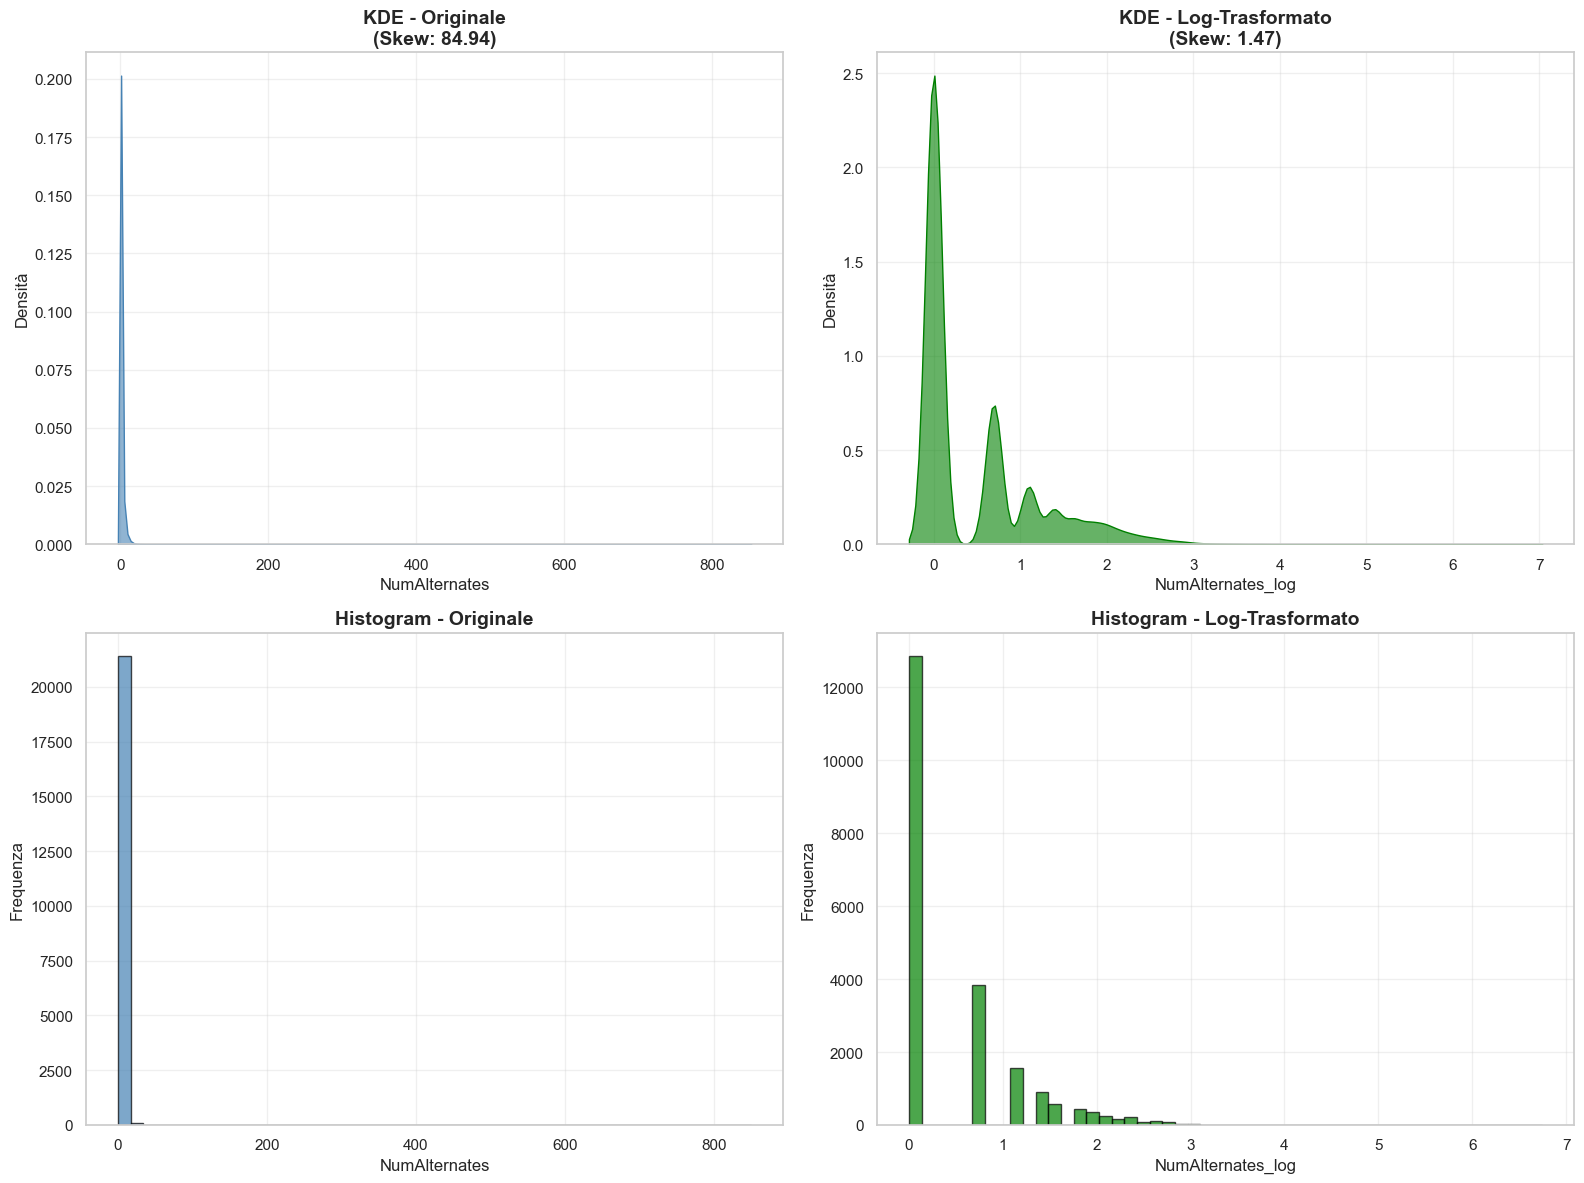

In [129]:
plot_comparison_kde(df, "NumAlternates", 'NumAlternates_log')


### Effect of log transformation

In [130]:
print("=" * 70)
print(f"STATISTICHE DESCRITTIVE - {"NumAlternates_log"}")
print("=" * 70)
print(df["NumAlternates_log"].describe())
print(f"\nSkewness: {df["NumAlternates_log"].skew():.3f}")
print(f"Kurtosis: {df["NumAlternates_log"].kurtosis():.3f}")

STATISTICHE DESCRITTIVE - NumAlternates_log
count    21513.000000
mean         0.484489
std          0.702492
min          0.000000
25%          0.000000
50%          0.000000
75%          0.693147
max          6.746412
Name: NumAlternates_log, dtype: float64

Skewness: 1.468
Kurtosis: 1.942


# `Kickstarted`

The variable *Kickstarted* is already in an optimal format for preprocessing. It is a binary feature (0/1) with no missing values and therefore requires no transformation. Since binary variables do not benefit from scaling or normalization, no rescaling or log transformation should be applied. The feature is clean, complete, and ready for downstream use exactly as provided. It should simply be retained in its current form during data preparation.


===== VALUE COUNTS =====
Kickstarted
0    18177
1     3336
Name: count, dtype: int64

===== PERCENTAGES =====
Kickstarted
0    84.493097
1    15.506903
Name: proportion, dtype: float64

===== MISSING VALUES =====
Missing values in Kickstarted: 0


/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_5160/557052808.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts3.index, y=counts3.values, palette=["#4c72b0", "#dd8452"])


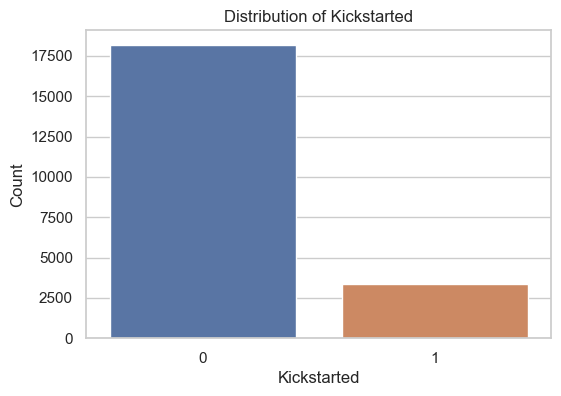

In [131]:
# 1. BASIC DISTRIBUTION
# ===============================
print("===== VALUE COUNTS =====")
counts3 = df['Kickstarted'].value_counts(dropna=False)
print(counts3)

print("\n===== PERCENTAGES =====")
percentages3 = df['Kickstarted'].value_counts(normalize=True) * 100
print(percentages3)

print("\n===== MISSING VALUES =====")
missing_kick = df['Kickstarted'].isna().sum()
print(f"Missing values in Kickstarted: {missing_kick}")

# 2. PLOT DISTRIBUTION
# ===============================
plt.figure(figsize=(6,4))
sns.barplot(x=counts3.index, y=counts3.values, palette=["#4c72b0", "#dd8452"])
plt.title("Distribution of Kickstarted")
plt.xlabel("Kickstarted")
plt.ylabel("Count")
plt.xticks([0,1])
plt.show()




## Dropping `ImagePath`, `BGGId`, `Description`

In [132]:
# Drop ImagePath, BGGId, Description
def drop_non_informative_columns(
    data: pd.DataFrame,
    cols_to_drop: list = None
) -> pd.DataFrame:
    """
    Remove non-informative columns from the dataset.

    Parameters:
        data (pd.DataFrame): Input dataset.
        cols_to_drop (list): List of column names to drop. If None, defaults to
                             ["ImagePath", "Name", "Description", "BGGId"].
    Returns:
        pd.DataFrame: Dataset without the specified non-informative columns.
    """
    if cols_to_drop is None:
        cols_to_drop = ["ImagePath", "Description", "BGGId"]

    # Identify columns that actually exist in the dataframe
    cols_existing = [col for col in cols_to_drop if col in data.columns]

    if not cols_existing:
        print("No non-informative columns found; nothing was removed.")
        return data.copy()
    # Drop the identified columns
    new_data = data.drop(columns=cols_existing).copy()
    print(f"Removed {len(cols_existing)} non-informative columns: {cols_existing}")
    return new_data
df = drop_non_informative_columns(df)
df.columns


Removed 3 non-informative columns: ['ImagePath', 'Description', 'BGGId']


Index(['Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
       'ComAgeRec', 'InterestScore', 'NumWeightVotes', 'log_NumWeightVotes',
       'PlaytimeComAvg', 'NumUserRatings', 'log_NumUserRatings',
       'NumAlternates', 'NumAlternates_log', 'NumExpansions',
       'NumExpansions_log', 'NumImplementations', 'NumImplementations_log',
       'IsReimplementation', 'Kickstarted', 'Cat:Thematic', 'Cat:Strategy',
       'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract', 'Cat:Party',
       'Cat:Childrens', 'Rating'],
      dtype='object')

,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,InterestScore,NumWeightVotes,log_NumWeightVotes,PlaytimeComAvg,NumUserRatings,...,IsReimplementation,Kickstarted,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens
YearPublished,1.000000,-0.004739,-0.160016,0.055437,-0.068628,0.116353,-0.252838,-0.252838,-0.157650,0.056411,...,0.115084,0.370676,-0.013137,0.023110,-0.262558,-0.024320,-0.056245,-0.147311,-0.020303,-0.155328
GameWeight,-0.004739,1.000000,-0.194479,-0.296744,0.617641,0.254567,0.288026,0.288026,0.692939,0.141615,...,0.037193,0.109482,0.142237,0.303487,0.442750,-0.148596,0.070131,-0.010032,-0.159060,-0.241800
MinPlayers,-0.160016,-0.194479,1.000000,0.310766,-0.070350,-0.097955,-0.054185,-0.054185,-0.086180,-0.032391,...,-0.007038,-0.151172,-0.086975,0.001482,-0.144825,0.018395,-0.011309,-0.016138,0.165763,-0.002693
MaxPlayers,0.055437,-0.296744,0.310766,1.000000,-0.170272,-0.010352,-0.073254,-0.073254,-0.114287,0.066531,...,0.012640,0.026536,0.034047,-0.002665,-0.379814,0.068663,-0.058958,-0.149393,0.202071,0.007613
ComAgeRec,-0.068628,0.617641,-0.070350,-0.170272,1.000000,0.098473,0.129684,0.129684,0.605017,-0.022482,...,0.000825,0.042341,0.112608,0.173128,0.532656,-0.262548,0.045692,-0.172428,-0.039804,-0.313003
InterestScore,0.116353,0.254567,-0.097955,-0.010352,0.098473,1.000000,0.778559,0.778559,0.197187,0.933078,...,0.143248,0.124288,0.247704,0.366355,0.009384,0.317117,0.028756,-0.046435,0.171132,-0.050837
NumWeightVotes,-0.252838,0.288026,-0.054185,-0.073254,0.129684,0.778559,1.000000,1.000000,0.254973,0.821477,...,0.060511,-0.021961,0.254815,0.395860,0.143821,0.346375,0.064782,0.032590,0.157926,0.009339
log_NumWeightVotes,-0.252838,0.288026,-0.054185,-0.073254,0.129684,0.778559,1.000000,1.000000,0.254973,0.821477,...,0.060511,-0.021961,0.254815,0.395860,0.143821,0.346375,0.064782,0.032590,0.157926,0.009339
PlaytimeComAvg,-0.157650,0.692939,-0.086180,-0.114287,0.605017,0.197187,0.254973,0.254973,1.000000,0.089581,...,0.019598,0.021777,0.151637,0.209505,0.480168,-0.126400,-0.008156,-0.160077,-0.101916,-0.202226
NumUserRatings,0.056411,0.141615,-0.032391,0.066531,-0.022482,0.933078,0.821477,0.821477,0.089581,1.000000,...,0.119804,0.078227,0.247429,0.383072,-0.119318,0.359121,0.045495,-0.005564,0.186480,-0.012333


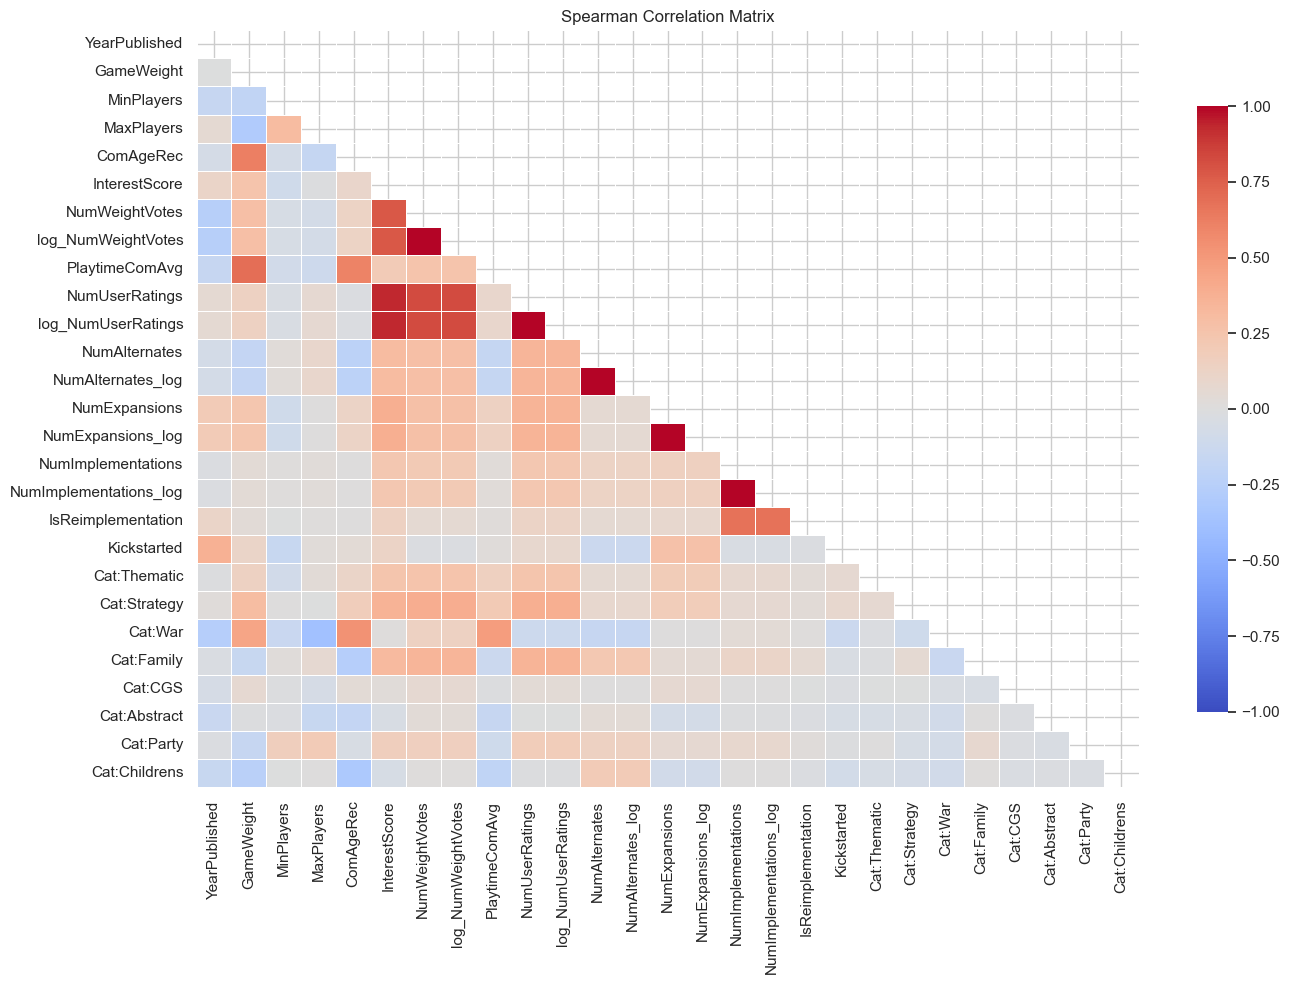

,col_A,col_B,rho,abs_rho,missing_A_%,missing_B_%,card_A,card_B
2,NumWeightVotes,log_NumWeightVotes,1.000000,1.000000,0.0,0.0,761,761
3,NumUserRatings,log_NumUserRatings,1.000000,1.000000,0.0,0.0,3097,3097
4,NumAlternates,NumAlternates_log,1.000000,1.000000,0.0,0.0,51,51
5,NumExpansions,NumExpansions_log,1.000000,1.000000,0.0,0.0,99,99
6,NumImplementations,NumImplementations_log,1.000000,1.000000,0.0,0.0,22,22
0,InterestScore,NumUserRatings,0.933078,0.933078,0.0,0.0,4573,3097
1,InterestScore,log_NumUserRatings,0.933078,0.933078,0.0,0.0,4573,3097


These columns are highly correlated (|rho| ≥ 0.90).
→ Review each pair and choose which column to keep based on:
   - semantic interpretability (which one is clearer/useful for analysis),
   - lower missingness (%),
   - fewer anomalies/outliers (see previous step),
   - lower redundancy w.r.t. other variables



In [133]:

# Funzione principale per calcolare la correlazione di Spearman e gestire le coppie altamente correlate
def spearman_and_redundancy(df, threshold=0.90):
    # Seleziona tutte le colonne numeriche automaticamente
    numerical_vars = df.select_dtypes(include=[np.number]).columns

    # Calcola la matrice di correlazione di Spearman
    spearman_corr = df[numerical_vars].corr(method="spearman")

    # Mostra la matrice numerica per un'analisi precisa
    display(spearman_corr)

    # Crea la maschera per il triangolo superiore
    mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

    # Crea una heatmap per un'ispezione visiva rapida, mascherando il triangolo superiore
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        spearman_corr,
        mask=mask,  # Applica la maschera per nascondere il triangolo superiore
        annot=False,  # Impostato su True se vuoi vedere i numeri, ma può diventare affollato
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        vmin=-1, vmax=1,  # Scala fissa
        center=0,
        cbar_kws={'shrink': .8}
    )
    plt.title("Spearman Correlation Matrix")
    plt.tight_layout()
    plt.show()

    # Lista per raccogliere le coppie altamente correlate
    high_corr_pairs = []

    # Raccogli le coppie con |rho| ≥ threshold
    rows = []
    for i, a in enumerate(numerical_vars):
        for j, b in enumerate(numerical_vars):
            if j <= i:
                # Considera ogni coppia non ordinata una sola volta; salta la diagonale
                continue
            rho = spearman_corr.loc[a, b]
            if pd.notna(rho) and abs(rho) >= threshold:
                # Calcola altre metriche utili per la scelta manuale successiva
                miss_a = df[a].isna().mean()
                miss_b = df[b].isna().mean()
                card_a = df[a].nunique(dropna=True)
                card_b = df[b].nunique(dropna=True)

                rows.append({
                    "col_A": a,
                    "col_B": b,
                    "rho": float(rho),
                    "abs_rho": float(abs(rho)),
                    "missing_A_%": round(100*miss_a, 2),
                    "missing_B_%": round(100*miss_b, 2),
                    "card_A": int(card_a),
                    "card_B": int(card_b)
                })

    # Se ci sono coppie altamente correlate, mostra un report
    if rows:
        report = pd.DataFrame(rows).sort_values("abs_rho", ascending=False)
        display(report)

        print(
            "These columns are highly correlated (|rho| ≥ {:.2f}).\n"
            "→ Review each pair and choose which column to keep based on:\n"
            "   - semantic interpretability (which one is clearer/useful for analysis),\n"
            "   - lower missingness (%),\n"
            "   - fewer anomalies/outliers (see previous step),\n"
            "   - lower redundancy w.r.t. other variables\n".format(threshold)
        )

        # Se vuoi prendere decisioni ora, costruisci una lista come questa:
        # to_drop_manual = ['ComMaxPlaytime', 'NumUserRatings', 'NumWish']  # esempio
        # df = df.drop(columns=to_drop_manual)
        # numerical_vars = [c for c in numerical_vars if c not in to_drop_manual]

    else:
        print(f"No pairs with |rho| ≥ {threshold:.2f}.")

# Esegui la funzione
spearman_and_redundancy(df)


In [139]:
def analyze_skewness(df, threshold_skew=2, threshold_kurt=7, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []

    results = []

    for col in df.columns:
        if col in exclude_cols:
            continue

        # converte in numerico, elimina valori non validi e NaN
        series = pd.to_numeric(df[col], errors='coerce').dropna()

        # salta colonne vuote
        if len(series) == 0:
            continue

        # converte esplicitamente in array numpy
        values = series.to_numpy(dtype=float)

        sk = stats.skew(values, bias=False)
        kurt = stats.kurtosis(values, bias=False)

        problematic = (abs(sk) > threshold_skew) or (kurt > threshold_kurt)

        results.append({
            'Variable': col,
            'Skewness': sk,
            'Kurtosis': kurt,
            'Problematic': problematic
        })

    results_df = pd.DataFrame(results)

    if not results_df.empty:
        results_df = results_df.sort_values(
            by='Skewness',
            key=lambda x: x.abs(),
            ascending=False
        )

    return results_df

results = analyze_skewness(df)
results.head(10)

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1054: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


,Variable,Skewness,Kurtosis,Problematic
12,NumAlternates,84.938337,8935.562616,True
4,MaxPlayers,42.657685,2657.421451,True
14,NumExpansions,24.742812,1165.826697,True
9,PlaytimeComAvg,17.778956,520.025875,True
7,NumWeightVotes,15.549467,375.441589,True
10,NumUserRatings,12.669012,233.672867,True
16,NumImplementations,12.083435,359.280342,True
6,InterestScore,11.496880,197.177874,True
24,Cat:CGS,8.247652,66.029910,True
26,Cat:Party,5.623255,29.623754,True


PlaytimeComAvg => log

ANALISI APPROFONDITA: PlaytimeComAvg

📊 STATISTICHE DESCRITTIVE:
--------------------------------------------------------------------------------
  Count....................       21,513.00
  Mean.....................           73.79
  Median...................           45.00
  Mode.....................           30.00
  Std Dev..................          161.13
  Min......................            1.00
  Max......................        8,000.00
  Range....................        7,999.00
  IQR......................           50.00
  Skewness.................           17.78
  Kurtosis.................          519.90
  CV (Coeff Variation).....          218.38

📈 DISTRIBUZIONE PER PERCENTILI:
--------------------------------------------------------------------------------
  Percentile       Valore    % Cumulativa    N° Giochi
  --------------------------------------------------
    1°                  8            1.2%          252
    5°                 12            5.5%        

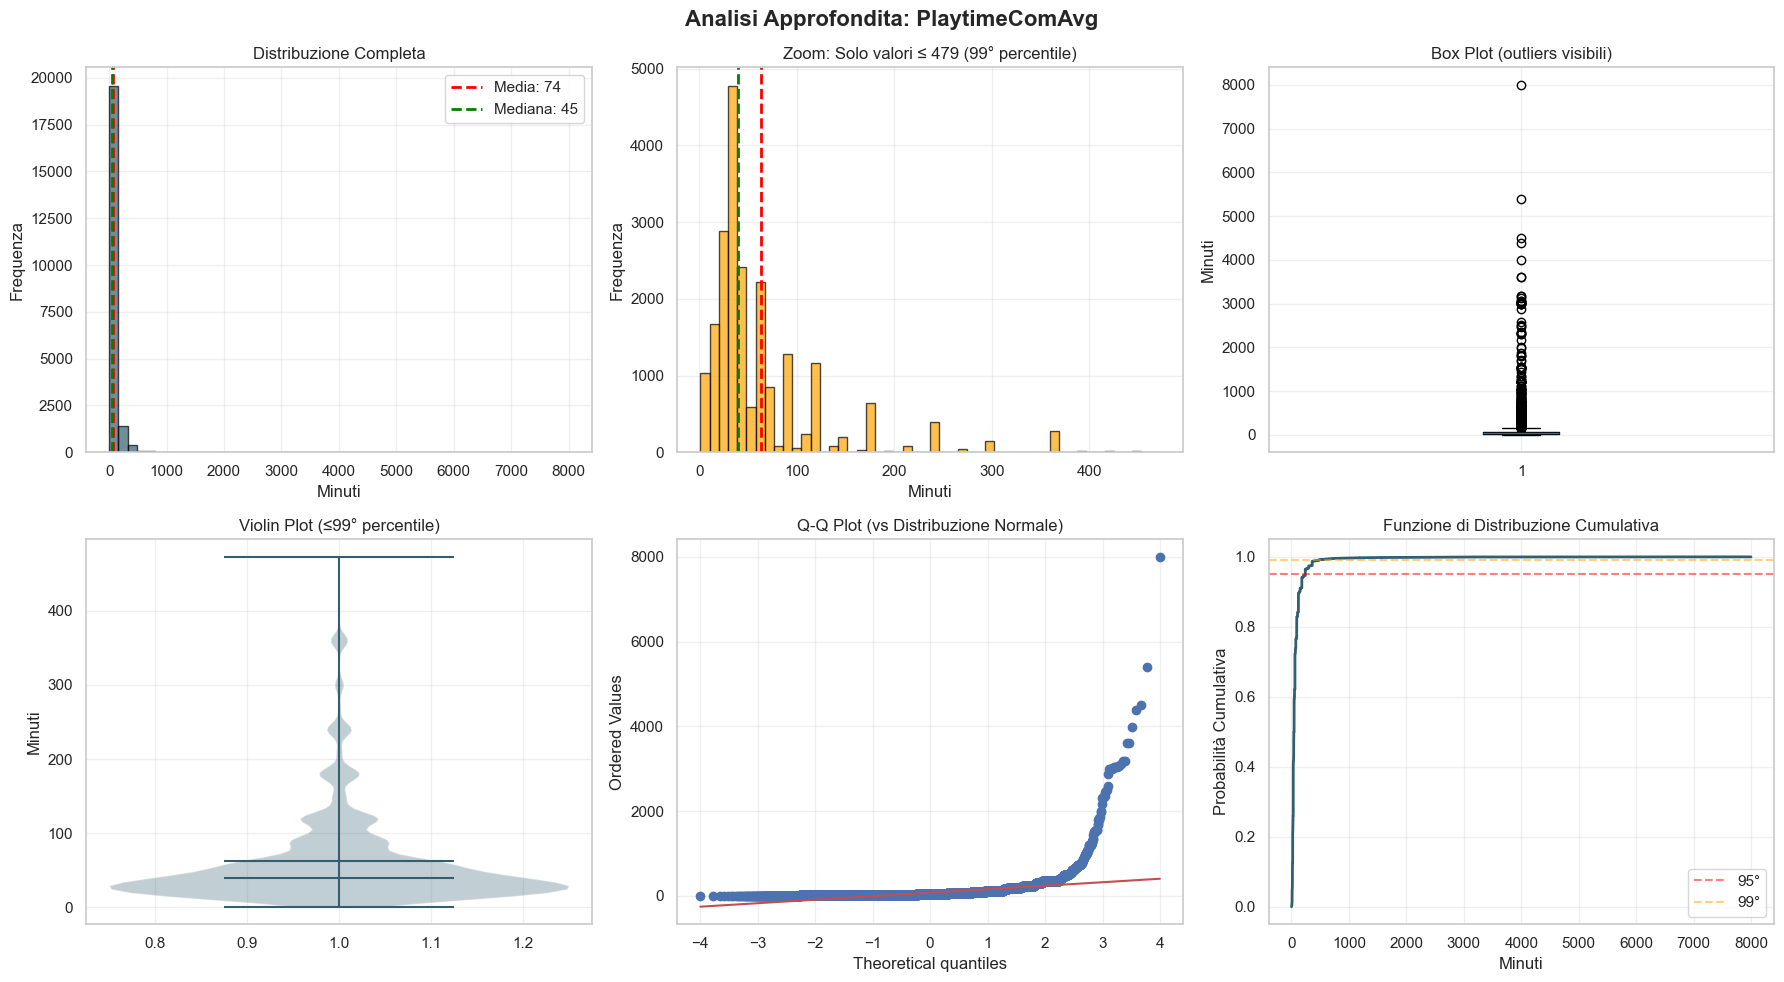


💡 RACCOMANDAZIONI:
  3. ⚠️  5.3% outliers estremi - winsorization consigliata
  5. ⚠️  Valori massimi MOLTO distanti dal 99° percentile
     Considera di investigare questi casi specifici



In [140]:
def deep_analysis_playtime(df, var):
    """
    Analisi completa della variabile PlaytimeComAvg
    """
    
    print("="*80)
    print(f"ANALISI APPROFONDITA: {var}")
    print("="*80)
    
    # ====== 1. STATISTICHE DESCRITTIVE ======
    print("\n📊 STATISTICHE DESCRITTIVE:")
    print("-"*80)
    
    data = df[var].dropna()
    
    stats_dict = {
        'Count': len(data),
        'Mean': data.mean(),
        'Median': data.median(),
        'Mode': data.mode()[0] if len(data.mode()) > 0 else np.nan,
        'Std Dev': data.std(),
        'Min': data.min(),
        'Max': data.max(),
        'Range': data.max() - data.min(),
        'IQR': data.quantile(0.75) - data.quantile(0.25),
        'Skewness': stats.skew(data),
        'Kurtosis': stats.kurtosis(data),
        'CV (Coeff Variation)': (data.std() / data.mean()) * 100
    }
    
    for key, value in stats_dict.items():
        print(f"  {key:.<25} {value:>15,.2f}")
    
    # ====== 2. PERCENTILI ======
    print("\n📈 DISTRIBUZIONE PER PERCENTILI:")
    print("-"*80)
    
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5, 99.9]
    
    print(f"  {'Percentile':<12} {'Valore':>10} {'% Cumulativa':>15} {'N° Giochi':>12}")
    print("  " + "-"*50)
    
    for p in percentiles:
        val = data.quantile(p/100)
        cum_pct = (data <= val).sum() / len(data) * 100
        n_games = (data <= val).sum()
        print(f"  {p:>3}°{'':<8} {val:>10.0f} {cum_pct:>14.1f}% {n_games:>12,}")
    
    # ====== 3. ANALISI OUTLIERS (IQR) ======
    print("\n🎯 ANALISI OUTLIERS (Metodo IQR):")
    print("-"*80)
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_mild = data[(data < lower_bound) | (data > upper_bound)]
    
    # Outliers estremi (3*IQR)
    lower_bound_extreme = Q1 - 3 * IQR
    upper_bound_extreme = Q3 + 3 * IQR
    outliers_extreme = data[(data < lower_bound_extreme) | (data > upper_bound_extreme)]
    
    print(f"  Q1 (25°)..................... {Q1:>10.0f}")
    print(f"  Q3 (75°)..................... {Q3:>10.0f}")
    print(f"  IQR.......................... {IQR:>10.0f}")
    print(f"  Lower Bound (Q1-1.5*IQR)..... {lower_bound:>10.0f}")
    print(f"  Upper Bound (Q3+1.5*IQR)..... {upper_bound:>10.0f}")
    print(f"  \n  Outliers MODERATI:")
    print(f"    N° outliers................ {len(outliers_mild):>10,} ({len(outliers_mild)/len(data)*100:.2f}%)")
    print(f"    Range outliers............. {outliers_mild.min():.0f} - {outliers_mild.max():.0f}")
    print(f"  \n  Outliers ESTREMI (3*IQR):")
    print(f"    N° outliers................ {len(outliers_extreme):>10,} ({len(outliers_extreme)/len(data)*100:.2f}%)")
    if len(outliers_extreme) > 0:
        print(f"    Range outliers............. {outliers_extreme.min():.0f} - {outliers_extreme.max():.0f}")
    
    # ====== 4. DISTRIBUZIONE PER FASCE ======
    print("\n📦 DISTRIBUZIONE PER FASCE DI TEMPO:")
    print("-"*80)
    
    bins = [0, 30, 60, 90, 120, 180, 240, 300, 500, 1000, 10000]
    labels = ['0-30', '31-60', '61-90', '91-120', '121-180', '181-240', 
              '241-300', '301-500', '501-1000', '1000+']
    
    data_binned = pd.cut(data, bins=bins, labels=labels, include_lowest=True)
    freq_table = data_binned.value_counts().sort_index()
    
    print(f"  {'Fascia (minuti)':<15} {'N° Giochi':>12} {'%':>8} {'Cumulativa %':>15}")
    print("  " + "-"*52)
    
    cumsum = 0
    for label, count in freq_table.items():
        pct = count / len(data) * 100
        cumsum += pct
        print(f"  {label:<15} {count:>12,} {pct:>7.2f}% {cumsum:>14.2f}%")
    
    # ====== 5. TOP VALORI ESTREMI ======
    print("\n🔥 TOP 20 VALORI PIÙ ESTREMI:")
    print("-"*80)
    
    top_values = data.nlargest(20).reset_index(drop=True)
    print(f"  {'Rank':<6} {'Valore':>10} {'% dei dati sotto':>18}")
    print("  " + "-"*36)
    
    for i, val in enumerate(top_values, 1):
        pct_below = (data < val).sum() / len(data) * 100
        print(f"  #{i:<4} {val:>10.0f} {pct_below:>17.2f}%")
    
    # ====== 6. CONFRONTO MEDIA vs MEDIANA ======
    print("\n⚖️  SIMMETRIA DELLA DISTRIBUZIONE:")
    print("-"*80)
    
    mean = data.mean()
    median = data.median()
    ratio = mean / median
    
    print(f"  Media........................ {mean:>10.2f}")
    print(f"  Mediana...................... {median:>10.2f}")
    print(f"  Rapporto (Media/Mediana)..... {ratio:>10.2f}x")
    
    if ratio > 2:
        print(f"  \n  ⚠️  FORTE ASIMMETRIA DESTRA: media è {ratio:.1f}x la mediana!")
        print(f"      Questo indica presenza di molti valori estremi alti")
    elif ratio > 1.5:
        print(f"  \n  ⚠️  ASIMMETRIA MODERATA: media è {ratio:.1f}x la mediana")
    else:
        print(f"  \n  ✅ Distribuzione relativamente simmetrica")
    
    # ====== 7. VISUALIZZAZIONI ======
    print("\n📊 Generando visualizzazioni...")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Analisi Approfondita: {var}', fontsize=16, fontweight='bold')
    
    # 1. Istogramma completo
    axes[0, 0].hist(data, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Media: {mean:.0f}')
    axes[0, 0].axvline(median, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median:.0f}')
    axes[0, 0].set_xlabel('Minuti')
    axes[0, 0].set_ylabel('Frequenza')
    axes[0, 0].set_title('Distribuzione Completa')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # 2. Istogramma ZOOM (sotto 99° percentile)
    p99 = data.quantile(0.99)
    data_zoom = data[data <= p99]
    axes[0, 1].hist(data_zoom, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].axvline(data_zoom.mean(), color='red', linestyle='--', linewidth=2)
    axes[0, 1].axvline(data_zoom.median(), color='green', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel('Minuti')
    axes[0, 1].set_ylabel('Frequenza')
    axes[0, 1].set_title(f'Zoom: Solo valori ≤ {p99:.0f} (99° percentile)')
    axes[0, 1].grid(alpha=0.3)
    
    # 3. Box Plot
    axes[0, 2].boxplot(data, vert=True)
    axes[0, 2].set_ylabel('Minuti')
    axes[0, 2].set_title('Box Plot (outliers visibili)')
    axes[0, 2].grid(alpha=0.3)
    
    # 4. Violin Plot (zoom)
    axes[1, 0].violinplot([data_zoom], vert=True, showmeans=True, showmedians=True)
    axes[1, 0].set_ylabel('Minuti')
    axes[1, 0].set_title(f'Violin Plot (≤99° percentile)')
    axes[1, 0].grid(alpha=0.3)
    
    # 5. Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot (vs Distribuzione Normale)')
    axes[1, 1].grid(alpha=0.3)
    
    # 6. CDF (Cumulative Distribution Function)
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    axes[1, 2].plot(sorted_data, cdf, linewidth=2)
    axes[1, 2].axhline(0.95, color='red', linestyle='--', alpha=0.5, label='95°')
    axes[1, 2].axhline(0.99, color='orange', linestyle='--', alpha=0.5, label='99°')
    axes[1, 2].set_xlabel('Minuti')
    axes[1, 2].set_ylabel('Probabilità Cumulativa')
    axes[1, 2].set_title('Funzione di Distribuzione Cumulativa')
    axes[1, 2].legend()
    axes[1, 2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ====== 8. RACCOMANDAZIONI ======
    print("\n💡 RACCOMANDAZIONI:")
    print("="*80)
    
    if ratio > 3:
        print("  1. ⚠️  PRIORITÀ ALTA: Trasformazione necessaria (media >>mediana)")
        print("  2. Considera LOG, Yeo-Johnson, o Box-Cox")
    
    outlier_pct = len(outliers_extreme) / len(data) * 100
    if outlier_pct > 5:
        print(f"  3. ⚠️  {outlier_pct:.1f}% outliers estremi - winsorization consigliata")
    elif outlier_pct > 1:
        print(f"  4. {outlier_pct:.1f}% outliers estremi - valuta winsorization")
    
    if data.max() > data.quantile(0.99) * 5:
        print("  5. ⚠️  Valori massimi MOLTO distanti dal 99° percentile")
        print("     Considera di investigare questi casi specifici")
    
    print("\n" + "="*80)
    
    return {
        'stats': stats_dict,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'upper_bound': upper_bound,
        'n_outliers': len(outliers_mild),
        'n_extreme_outliers': len(outliers_extreme)
    }

# ESEGUI L'ANALISI
results = deep_analysis_playtime(df, 'PlaytimeComAvg')

InterestScore => LOG

ANALISI APPROFONDITA: InterestScore

📊 STATISTICHE DESCRITTIVE:
--------------------------------------------------------------------------------
  Count....................       21,513.00
  Mean.....................          581.38
  Median...................          128.67
  Mode.....................           39.33
  Std Dev..................        2,014.72
  Min......................            2.00
  Max......................       58,817.00
  Range....................       58,815.00
  IQR......................          301.33
  Skewness.................           11.50
  Kurtosis.................          197.13
  CV (Coeff Variation).....          346.54

📈 DISTRIBUZIONE PER PERCENTILI:
--------------------------------------------------------------------------------
  Percentile       Valore    % Cumulativa    N° Giochi
  --------------------------------------------------
    1°                 18            1.0%          220
    5°                 28            5.1%        1

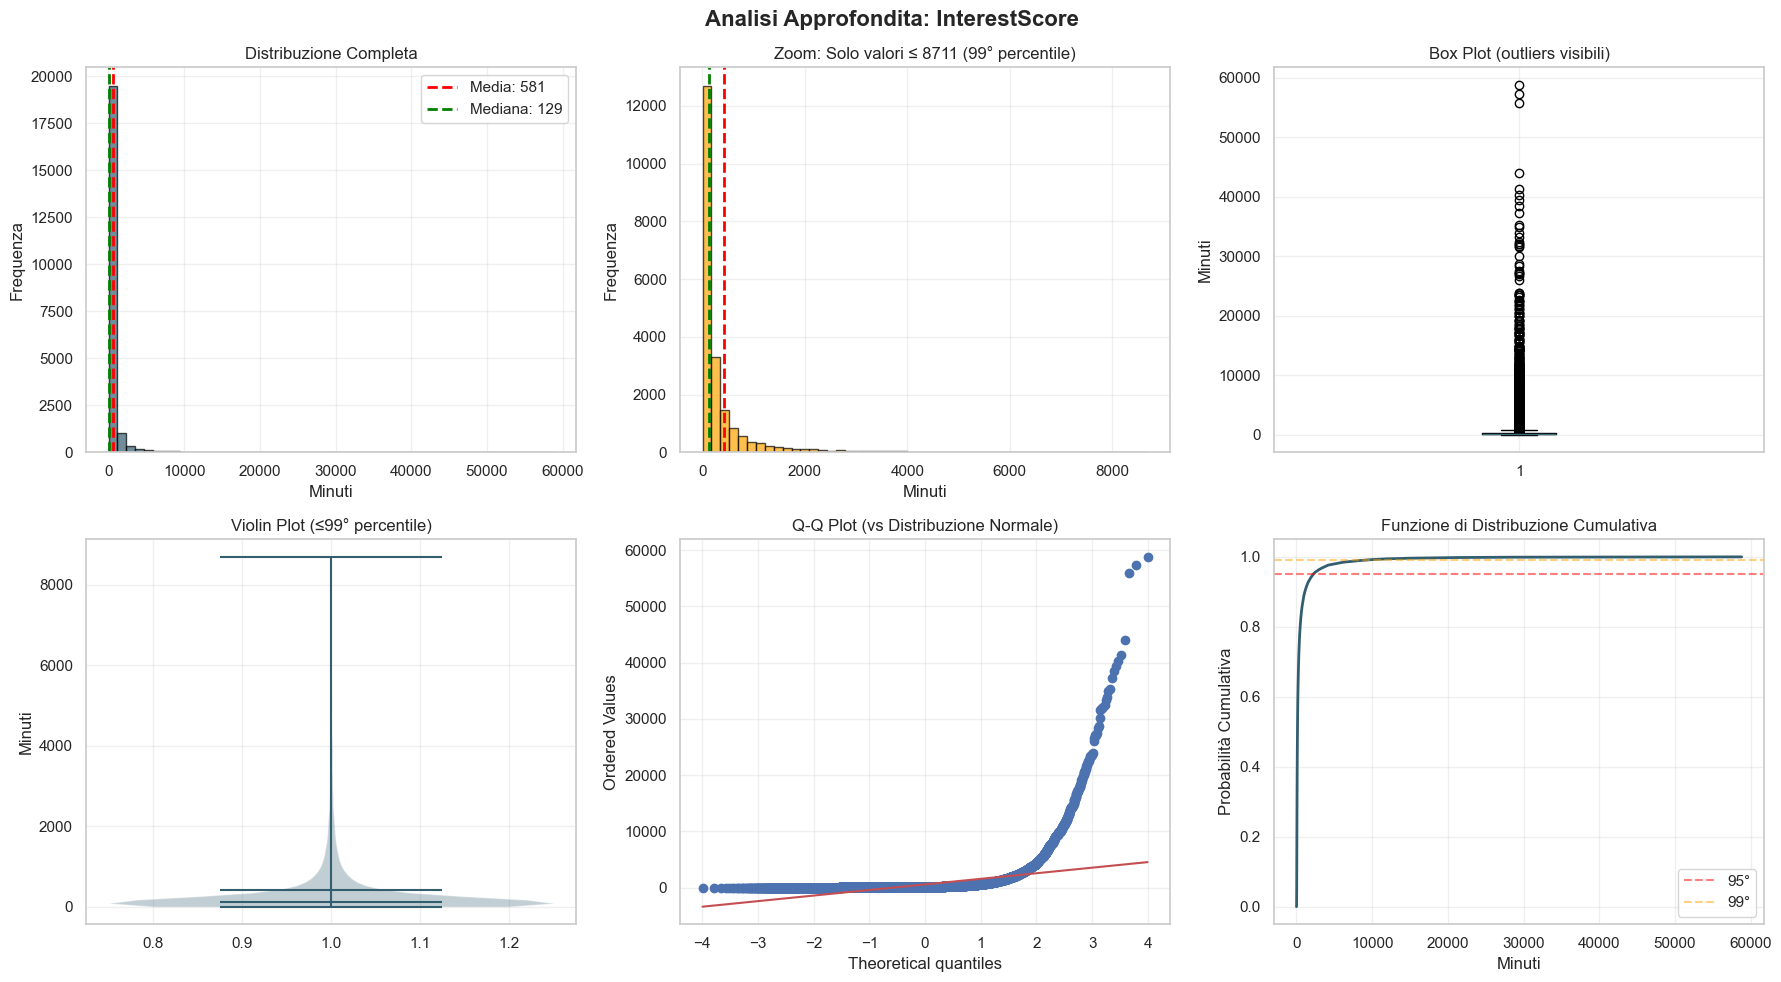


💡 RACCOMANDAZIONI:
  1. ⚠️  PRIORITÀ ALTA: Trasformazione necessaria (media >>mediana)
  2. Considera LOG, Yeo-Johnson, o Box-Cox
  3. ⚠️  8.8% outliers estremi - winsorization consigliata
  5. ⚠️  Valori massimi MOLTO distanti dal 99° percentile
     Considera di investigare questi casi specifici



{'stats': {'Count': 21513,
  'Mean': 581.379042129565,
  'Median': 128.66666666666666,
  'Mode': 39.333333333333336,
  'Std Dev': 2014.723418675503,
  'Min': 2.0,
  'Max': 58817.0,
  'Range': 58815.0,
  'IQR': 301.3333333333333,
  'Skewness': 11.49607883097589,
  'Kurtosis': 197.1317709428235,
  'CV (Coeff Variation)': 346.5421476659465},
 'Q1': 61.0,
 'Q3': 362.3333333333333,
 'IQR': 301.3333333333333,
 'upper_bound': 814.3333333333333,
 'n_outliers': 2803,
 'n_extreme_outliers': 1902}

In [141]:
deep_analysis_playtime(df, 'InterestScore')

In [142]:
def investigate_interest_score(df):
    """
    Investigate the distribution of InterestScore and check whether
    a suspicious repeated maximum/cap value exists.
    """

    print("=" * 80)
    print("InterestScore transformation analysis")
    print("=" * 80)
    
    max_val = 8671.256667  # exact value observed in a previous summary/check
    n_max = (df["InterestScore"] == max_val).sum()
    pct_max = n_max / len(df) * 100
    
    # 1. Full distribution overview
    print("\nDistribution:")
    print(f"  Min: {df['InterestScore'].min()}")
    print(f"  Median: {df['InterestScore'].median()}")
    print(f"  Mean: {df['InterestScore'].mean():.2f}")
    print(f"  95th percentile: {df['InterestScore'].quantile(0.95)}")
    print(f"  99th percentile: {df['InterestScore'].quantile(0.99)}")
    print(f"  Max: {df['InterestScore'].max()}")
    
    # 2. Check whether the selected value behaves like a special/capped value
    if n_max > 100:
        print(f"\nWarning: {n_max} games have InterestScore exactly equal to {max_val}.")
        print("This may suggest:")
        print("  - a capped value in the original dataset")
        print("  - a possible indicator of maximum popularity")
        print("  - a missing or special value encoded incorrectly")
        
        # Characteristics of games with the selected value
        print(f"\nCharacteristics of games with InterestScore = {max_val}:")
        max_games = df[df["InterestScore"] == max_val]
        
        if "NumUserRatings" in df.columns:
            print(f"  Mean NumUserRatings: {max_games['NumUserRatings'].mean():.0f}")
            print(f"  Median NumUserRatings: {max_games['NumUserRatings'].median():.0f}")
        
        if "GameWeight" in df.columns:
            print(f"  Mean GameWeight: {max_games['GameWeight'].mean():.2f}")
        
        # Compare with the rest of the dataset
        rest_games = df[df["InterestScore"] < max_val]
        
        print(f"\nComparison with regular games: InterestScore < {max_val}")
        if "NumUserRatings" in df.columns:
            print(f"  Mean NumUserRatings for regular games: {rest_games['NumUserRatings'].mean():.0f}")
            ratio = max_games["NumUserRatings"].mean() / rest_games["NumUserRatings"].mean()
            print(f"  Ratio: {ratio:.2f}x")
    
    else:
        print(f"\nNo suspicious repeated cap value detected.")
        print(f"  Games with InterestScore exactly equal to {max_val}: {n_max} ({pct_max:.2f}%)")
    
    # 3. Distribution after excluding values greater than or equal to the selected threshold
    print(f"\nStatistics after excluding InterestScore >= {max_val}:")
    data_clean = df[df["InterestScore"] < max_val]["InterestScore"]
    
    print(f"  Count: {len(data_clean)}")
    print(f"  Mean: {data_clean.mean():.2f}")
    print(f"  Median: {data_clean.median():.2f}")
    print(f"  Skewness: {stats.skew(data_clean):.2f}")
    print(f"  Kurtosis: {stats.kurtosis(data_clean):.2f}")
    print(f"  Max: {data_clean.max():.2f}")
    
    return n_max, pct_max


n_max_values, pct_max = investigate_interest_score(df)

🔍 INVESTIGAZIONE InterestScore

🚨 PROBLEMA IDENTIFICATO:
  Valori esattamente = 8671.256667: 0 (0.00%)

📊 DISTRIBUZIONE:
  Min: 2.0
  Mediana: 128.66666666666666
  Mean: 581.38
  95° percentile: 2201.9999999999964
  99° percentile: 8711.066666666688
  Max: 58817.0

📈 STATISTICHE SENZA valore massimo (8671.256667):
  Count: 21296
  Mean: 422.54
  Median: 127.00
  Skewness: 4.72
  Kurtosis: 27.44
  Max: 8649.67


In [143]:
def final_solution_interest_score(df):
    """
    Soluzione finale raccomandata per InterestScore
    """
    print("="*80)
    print("🎯 SOLUZIONE FINALE - InterestScore")
    print("="*80)
    
    df['InterestScore_log'] = np.log1p(df['InterestScore'])
    
    # Verifica
    sk_before = stats.skew(df['InterestScore'])
    kurt_before = stats.kurtosis(df['InterestScore'])
    sk_after = stats.skew(df['InterestScore_log'])
    kurt_after = stats.kurtosis(df['InterestScore_log'])
    
    print(f"\n📊 RISULTATI:")
    print("-"*80)
    print(f"{'Metrica':<20} {'Prima':>15} {'Dopo LOG':>15} {'Miglio%':>12}")
    print("-"*80)
    
    improvement_sk = ((abs(sk_before) - abs(sk_after)) / abs(sk_before) * 100)
    improvement_kurt = ((kurt_before - kurt_after) / kurt_before * 100)
    
    print(f"{'Skewness':<20} {sk_before:>15.2f} {sk_after:>15.2f} {improvement_sk:>11.1f}%")
    print(f"{'Kurtosis':<20} {kurt_before:>15.2f} {kurt_after:>15.2f} {improvement_kurt:>11.1f}%")
    
    # Status
    print("\n" + "="*80)
    if abs(sk_after) <= 2 and kurt_after <= 7:
        print("✅ PERFETTO! InterestScore_log è pronta")
        status = "✅ Ottima"
    elif abs(sk_after) <= 3 and kurt_after <= 15:
        print("✅ ACCETTABILE! InterestScore_log va bene per tutti i modelli")
        status = "✅ Buona"
    else:
        print("⚠️  Potrebbe servire winsorization aggiuntiva")
        status = "⚠️  Valuta"
    
    print("="*80)
    
    # Stima impatto
    print("\n💡 IMPATTO SUI TUOI MODELLI:")
    print("-"*80)
    print("  Classificazione (RF/XGBoost):  Impatto ~0-2% (identico o migliore)")
    print("  Regressione:                   Probabile miglioramento")
    print("  Clustering:                    Cambio moderato ma struttura simile")
    
    return df, status

df, status = final_solution_interest_score(df)

🎯 SOLUZIONE FINALE - InterestScore

📊 RISULTATI:
--------------------------------------------------------------------------------
Metrica                        Prima        Dopo LOG      Miglio%
--------------------------------------------------------------------------------
Skewness                       11.50            0.84        92.7%
Kurtosis                      197.13            0.63        99.7%

✅ PERFETTO! InterestScore_log è pronta

💡 IMPATTO SUI TUOI MODELLI:
--------------------------------------------------------------------------------
  Classificazione (RF/XGBoost):  Impatto ~0-2% (identico o migliore)
  Regressione:                   Probabile miglioramento
  Clustering:                    Cambio moderato ma struttura simile


In [144]:
def analyze_skewness(df, threshold_skew=2, threshold_kurt=7, exclude_cols=None):
    """
    Analizza skewness e kurtosis di tutte le variabili numeriche del dataset.
    
    Parameters:
    -----------
    df : DataFrame
        Dataset da analizzare
    threshold_skew : float
        Soglia per considerare una variabile asimmetrica (default: 2)
    threshold_kurt : float
        Soglia per considerare una kurtosis problematica (default: 7)
    exclude_cols : list
        Colonne da escludere dall'analisi (es. ID, target)
    
    Returns:
    --------
    DataFrame con statistiche di skewness e kurtosis
    """
    
    if exclude_cols is None:
        exclude_cols = []
    
    # Seleziona solo colonne numeriche
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    results = []
    
    for col in numeric_cols:
        # Rimuovi NaN per il calcolo
        data = df[col].dropna()
        
        if len(data) > 0:
            sk = stats.skew(data)
            kurt = stats.kurtosis(data)
            
            # Determina se è problematica
            is_skewed = abs(sk) > threshold_skew
            is_high_kurt = kurt > threshold_kurt
            
            results.append({
                'Variable': col,
                'Skewness': round(sk, 2),
                'Kurtosis': round(kurt, 2),
                'Is_Skewed': is_skewed,
                'High_Kurtosis': is_high_kurt,
                'N_Values': len(data),
                'N_Unique': data.nunique(),
                'Min': data.min(),
                'Max': data.max()
            })
    
    results_df = pd.DataFrame(results)
    
    # Ordina per skewness assoluta decrescente
    results_df['Abs_Skewness'] = results_df['Skewness'].abs()
    results_df = results_df.sort_values('Abs_Skewness', ascending=False)
    results_df = results_df.drop('Abs_Skewness', axis=1)
    
    # Stampa summary
    print(f"{'='*70}")
    print(f"SKEWNESS ANALYSIS SUMMARY")
    print(f"{'='*70}")
    print(f"Total numeric variables analyzed: {len(results_df)}")
    print(f"Variables with |skewness| > {threshold_skew}: {results_df['Is_Skewed'].sum()}")
    print(f"Variables with kurtosis > {threshold_kurt}: {results_df['High_Kurtosis'].sum()}")
    print(f"\n{'='*70}")
    print(f"TOP PROBLEMATIC VARIABLES:")
    print(f"{'='*70}\n")
    
    problematic = results_df[(results_df['Is_Skewed']) | (results_df['High_Kurtosis'])]
    if len(problematic) > 0:
        print(problematic.to_string(index=False))
    else:
        print("No problematic variables found! ✓")
    
    return results_df


# Esempio di utilizzo
results = analyze_skewness(df)

# Se vuoi vedere anche quelle non problematiche
print("\n" + "="*70)
print("ALL VARIABLES:")
print("="*70)
print(results.to_string(index=False))

SKEWNESS ANALYSIS SUMMARY
Total numeric variables analyzed: 28
Variables with |skewness| > 2: 18
Variables with kurtosis > 7: 15

TOP PROBLEMATIC VARIABLES:

              Variable  Skewness  Kurtosis  Is_Skewed  High_Kurtosis  N_Values  N_Unique  Min           Max
         NumAlternates     84.93   8933.49       True           True     21513        51  0.0    850.000000
            MaxPlayers     42.65   2656.80       True           True     21513        51  1.0    999.000000
         NumExpansions     24.74   1165.56       True           True     21513        99  0.0    525.000000
        PlaytimeComAvg     17.78    519.90       True           True     21513       211  1.0   8000.000000
        NumWeightVotes     15.55    375.35       True           True     21513       761  0.0   7673.000000
        NumUserRatings     12.67    233.62       True           True     21513      3097 30.0 108101.000000
    NumImplementations     12.08    359.20       True           True     21513        

In [145]:
def check_remaining_skewed_variables(df):
    """
    Controlla se ci sono ALTRE variabili molto skewed da trasformare
    """
    from scipy import stats
    
    print("\n" + "="*85)
    print("🔍 VARIABILI ANCORA MOLTO SKEWED (sk > 5 o kurt > 50)")
    print("="*85)
    
    # Escludi quelle già trasformate e quelle categoriche/discrete
    exclude = [
        # Già trasformate
        'NumAlternates_log', 'NumExpansions_log', 'NumImplementations_log',
        'log_NumUserRatings', 'log_NumWeightVotes', 'InterestScore_log',
        'PlaytimeComAvg',  # già winsorizzata
        # Categoriche binarie (skewness alta è normale)
        'IsReimplementation', 'Kickstarted',
        # Discrete (kurtosis alta è normale)
      #  'MinPlayers', 'MaxPlayers',
        # Altre
        'Rating', 'GameWeight', 'ComAgeRec', 'YearPublished', 'NumExpansions', 'NumImplementations', 'NumAlternates', 'NumUserRatings', 'NumWeightVotes',
        'InterestScore'
    ]
    
    # Aggiungi tutte le Cat:
    exclude += [col for col in df.columns if col.startswith('Cat:')]
    
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    to_check = [col for col in numeric_cols if col not in exclude]
    
    very_skewed = []
    
    print(f"\n{'Variable':<30} {'Skewness':>10} {'Kurtosis':>10} {'Azione':>15}")
    print("-"*85)
    
    for var in sorted(to_check):
        sk = stats.skew(df[var])
        kurt = stats.kurtosis(df[var])
        
        if abs(sk) > 5 or kurt > 50:
            very_skewed.append((var, sk, kurt))
            action = "❌ Trasforma"
        elif abs(sk) > 3 or kurt > 15:
            action = "⚠️  Valuta"
        else:
            action = "✅ OK"
        
        if action != "✅ OK":
            print(f"{var:<30} {sk:>10.2f} {kurt:>10.2f} {action:>15}")
    
    print("\n" + "="*85)
    
    if very_skewed:
        print(f"\n⚠️  TROVATE {len(very_skewed)} VARIABILI MOLTO SKEWED DA TRASFORMARE:")
        print("-"*85)
        for var, sk, kurt in very_skewed:
            print(f"\n  ❌ {var}")
            print(f"     Skewness: {sk:.2f}, Kurtosis: {kurt:.2f}")
            print(f"     💡 Soluzione: df['{var}'] = np.log1p(df['{var}'])")
    else:
        print("\n🎉 NESSUNA ALTRA VARIABILE MOLTO SKEWED!")
        print("   Solo variabili con skewness moderata rimaste")
    
    return very_skewed

very_skewed = check_remaining_skewed_variables(df)


🔍 VARIABILI ANCORA MOLTO SKEWED (sk > 5 o kurt > 50)

Variable                         Skewness   Kurtosis          Azione
-------------------------------------------------------------------------------------
MaxPlayers                          42.65    2656.80     ❌ Trasforma


⚠️  TROVATE 1 VARIABILI MOLTO SKEWED DA TRASFORMARE:
-------------------------------------------------------------------------------------

  ❌ MaxPlayers
     Skewness: 42.65, Kurtosis: 2656.80
     💡 Soluzione: df['MaxPlayers'] = np.log1p(df['MaxPlayers'])


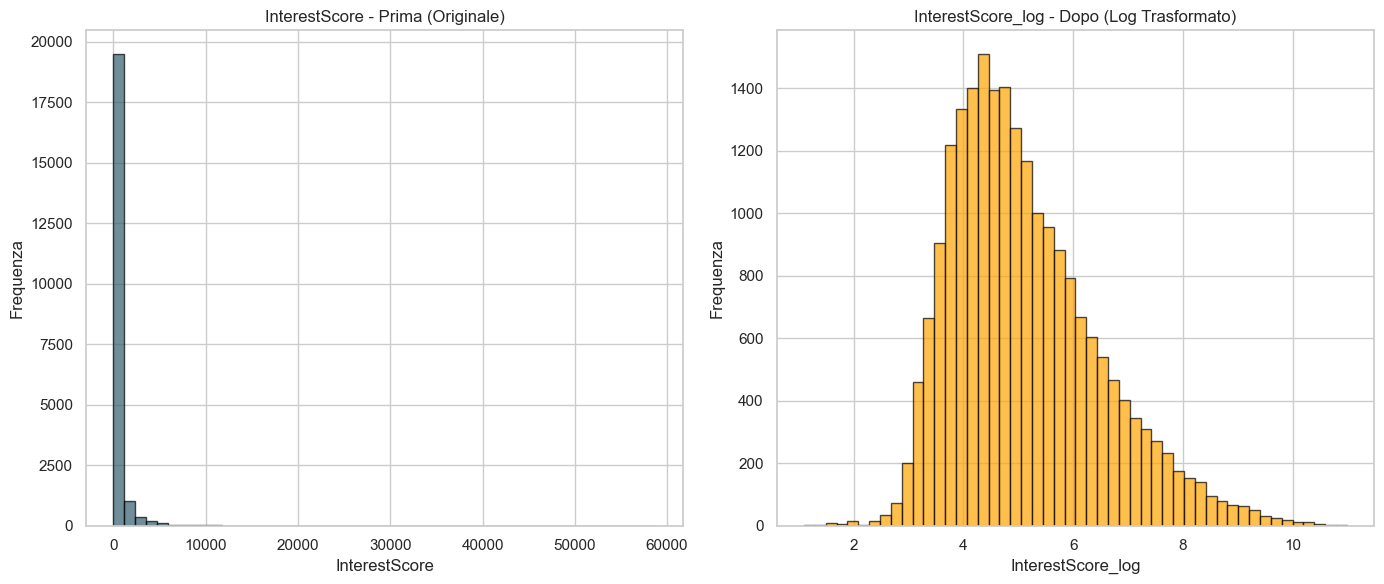

In [146]:
# Grafici sulla skewness di InterestScore prima e dopo essere diventato log
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Prima
axes[0].hist(df['InterestScore'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('InterestScore - Prima (Originale)')
axes[0].set_xlabel('InterestScore')
axes[0].set_ylabel('Frequenza')
# Dopo
axes[1].hist(df['InterestScore_log'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('InterestScore_log - Dopo (Log Trasformato)')
axes[1].set_xlabel('InterestScore_log')
axes[1].set_ylabel('Frequenza')
plt.tight_layout()
plt.show()

In [147]:
# ============================================================================
# FUNZIONE PRINCIPALE: TEST TRASFORMAZIONI
# ===========================================================
# =================

def test_transformations(df, features, show_plots=True):
    """
    Testa log, sqrt e original per ogni feature.
    Ritorna DataFrame con metriche e raccomandazione.
    
    Parameters:
    -----------
    df : DataFrame
        Dataset con le features da testare
    features : list
        Lista di nomi colonne da testare
    show_plots : bool
        Se True, mostra grafici comparativi
    
    Returns:
    --------
    results_df : DataFrame
        Tabella con skewness, kurtosis e best transformation per ogni feature
    """
    
    results = []
    
    for feature in features:
        if feature not in df.columns:
            print(f"⚠️  Feature '{feature}' not found, skipping...")
            continue
        
        print(f"\n{'='*70}")
        print(f"Testing: {feature}")
        print(f"{'='*70}")
        
        X = df[feature]
        
        # ====================================================================
        # TEST 1: ORIGINAL
        # ====================================================================
        original_skew = skew(X)
        original_kurt = kurtosis(X)
        original_score = abs(original_skew) + abs(original_kurt)
        
        print(f"\n1️⃣  ORIGINAL:")
        print(f"   Skewness: {original_skew:>8.4f}")
        print(f"   Kurtosis: {original_kurt:>8.4f}")
        print(f"   Score:    {original_score:>8.4f}")
        
        # ====================================================================
        # TEST 2: LOG
        # ====================================================================
        log_trans = np.log1p(X)  # log(1+x) per gestire zeri
        log_skew = skew(log_trans)
        log_kurt = kurtosis(log_trans)
        log_score = abs(log_skew) + abs(log_kurt)
        
        print(f"\n2️⃣  LOG (log1p):")
        print(f"   Skewness: {log_skew:>8.4f}")
        print(f"   Kurtosis: {log_kurt:>8.4f}")
        print(f"   Score:    {log_score:>8.4f}")
        print(f"   Improvement: {(1 - log_score/original_score)*100:>6.1f}%")
        
        # ====================================================================
        # TEST 3: SQRT
        # ====================================================================
        sqrt_trans = np.sqrt(X)
        sqrt_skew = skew(sqrt_trans)
        sqrt_kurt = kurtosis(sqrt_trans)
        sqrt_score = abs(sqrt_skew) + abs(sqrt_kurt)
        
        print(f"\n3️⃣  SQRT:")
        print(f"   Skewness: {sqrt_skew:>8.4f}")
        print(f"   Kurtosis: {sqrt_kurt:>8.4f}")
        print(f"   Score:    {sqrt_score:>8.4f}")
        print(f"   Improvement: {(1 - sqrt_score/original_score)*100:>6.1f}%")
        
        # ====================================================================
        # DECISIONE: Quale è la migliore?
        # ====================================================================
        scores = {
            'none': original_score,
            'log': log_score,
            'sqrt': sqrt_score
        }
        
        best_transform = min(scores, key=scores.get)
        
        # Preferisci log su sqrt se simile (più interpretabile)
        if abs(log_score - sqrt_score) < 0.5:  # Tolleranza 0.5
            if log_score <= sqrt_score * 1.1:  # Log entro 10% di sqrt
                best_transform = 'log'
        
        print(f"\n✅ BEST: {best_transform.upper()}")
        print(f"   Final score: {scores[best_transform]:.4f}")
        
        # ====================================================================
        # SALVA RISULTATI
        # ====================================================================
        results.append({
            'Feature': feature,
            'Original_Skew': original_skew,
            'Original_Kurt': original_kurt,
            'Original_Score': original_score,
            'Log_Skew': log_skew,
            'Log_Kurt': log_kurt,
            'Log_Score': log_score,
            'Sqrt_Skew': sqrt_skew,
            'Sqrt_Kurt': sqrt_kurt,
            'Sqrt_Score': sqrt_score,
            'Best_Transform': best_transform,
            'Best_Score': scores[best_transform]
        })
        
        # ====================================================================
        # PLOT (opzionale)
        # ====================================================================
        if show_plots:
            plot_transformations(X, feature, log_trans, sqrt_trans)
    
    # ========================================================================
    # CREA DATAFRAME RISULTATI
    # ========================================================================
    results_df = pd.DataFrame(results)
    
    return results_df

# ============================================================================
# FUNZIONE PLOT
# ============================================================================

def plot_transformations(original, feature_name, log_trans, sqrt_trans):
    """
    Crea visualizzazione comparativa delle trasformazioni
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f'{feature_name} - Transformation Comparison', fontsize=16, y=1.02)
    
    # Row 1: Histograms
    # Original
    axes[0, 0].hist(original, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Original')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].text(0.05, 0.95, f'Skew: {skew(original):.2f}\nKurt: {kurtosis(original):.2f}',
                    transform=axes[0, 0].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Log
    axes[0, 1].hist(log_trans, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[0, 1].set_title('Log (log1p)')
    axes[0, 1].text(0.05, 0.95, f'Skew: {skew(log_trans):.2f}\nKurt: {kurtosis(log_trans):.2f}',
                    transform=axes[0, 1].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    # Sqrt
    axes[0, 2].hist(sqrt_trans, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 2].set_title('Square Root')
    axes[0, 2].text(0.05, 0.95, f'Skew: {skew(sqrt_trans):.2f}\nKurt: {kurtosis(sqrt_trans):.2f}',
                    transform=axes[0, 2].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    # Row 2: Boxplots
    # Original
    axes[1, 0].boxplot(original, vert=True)
    axes[1, 0].set_ylabel('Value')
    axes[1, 0].set_xticklabels(['Original'])
    
    # Log
    axes[1, 1].boxplot(log_trans, vert=True)
    axes[1, 1].set_xticklabels(['Log'])
    
    # Sqrt
    axes[1, 2].boxplot(sqrt_trans, vert=True)
    axes[1, 2].set_xticklabels(['Sqrt'])
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# FUNZIONE PER APPLICARE LA TRASFORMAZIONE SCELTA (PRESERVANDO ORIGINALI)
# ============================================================================

def apply_best_transformations(df, results_df):
    """
    Applica la migliore trasformazione creando NUOVE colonne con suffisso.
    Le colonne originali rimangono intatte.
    
    Parameters:
    -----------
    df : DataFrame
        Dataset originale
    results_df : DataFrame
        Output di test_transformations con colonna 'Best_Transform'
    
    Returns:
    --------
    df_transformed : DataFrame
        Dataset con features originali + nuove colonne trasformate
    transformation_map : dict
        Dizionario {feature: (transformation_used, new_column_name)}
    """
    df_transformed = df.copy()
    transformation_map = {}
    
    for _, row in results_df.iterrows():
        feature = row['Feature']
        best = row['Best_Transform']
        
        if feature not in df.columns:
            continue
        
        if best == 'log':
            new_col_name = f"{feature}_log"
            df_transformed[new_col_name] = np.log1p(df[feature])
            print(f"✅ {feature} → {new_col_name}: LOG applied")
            transformation_map[feature] = ('log', new_col_name)
            
        elif best == 'sqrt':
            new_col_name = f"{feature}_sqrt"
            df_transformed[new_col_name] = np.sqrt(df[feature])
            print(f"✅ {feature} → {new_col_name}: SQRT applied")
            transformation_map[feature] = ('sqrt', new_col_name)
            
        else:
            print(f"✅ {feature}: NO transformation needed (original kept)")
            transformation_map[feature] = ('none', feature)
    
    return df_transformed, transformation_map

# ============================================================================
# FUNZIONE PER CREARE TABELLA
# ============================================================================

def create_table(results_df):
    table = results_df[[
        'Feature',
        'Original_Skew', 'Original_Kurt',
        'Log_Skew', 'Log_Kurt',
        'Sqrt_Skew', 'Sqrt_Kurt',
        'Best_Transform'
    ]].copy()
    
    # Formatta numeri
    for col in ['Original_Skew', 'Original_Kurt', 'Log_Skew', 'Log_Kurt', 'Sqrt_Skew', 'Sqrt_Kurt']:
        table[col] = table[col].apply(lambda x: f"{x:.2f}")
    
    print("\n" + "="*100)
    print("TRANSFORMATION COMPARISON TABLE")
    print("="*100)
    print(table.to_string(index=False))
    
    return table

# ============================================================================
# FUNZIONE PER OTTENERE SOLO LE COLONNE TRASFORMATE
# ============================================================================

def get_transformed_features_only(df_transformed, transformation_map):
    """
    Ritorna DataFrame con solo le colonne trasformate (escludendo originali)
    
    Parameters:
    -----------
    df_transformed : DataFrame
        Dataset con tutte le colonne
    transformation_map : dict
        Mappa delle trasformazioni
    
    Returns:
    --------
    df_only_transformed : DataFrame
        Dataset con solo le colonne trasformate
    """
    transformed_cols = [col_info[1] for col_info in transformation_map.values()]
    df_only_transformed = df_transformed[transformed_cols].copy()
    
    print("\n" + "="*70)
    print("TRANSFORMED FEATURES ONLY")
    print("="*70)
    print(f"Columns: {list(df_only_transformed.columns)}")
    
    return df_only_transformed

# ============================================================================
# ESEMPIO DI UTILIZZO
# ============================================================================

if __name__ == "__main__":
    
    
    # Lista features da testare
    features_to_test = [
        'PlaytimeComAvg',
 
    ]
    
    # ========================================================================
    # STEP 1: TEST TRASFORMAZIONI
    # ========================================================================
    print("🔬 TESTING TRANSFORMATIONS...")
    results = test_transformations(df, features_to_test, show_plots=False)
    
    # ========================================================================
    # STEP 2: VISUALIZZA TABELLA RIASSUNTIVA
    # ========================================================================
    table = create_table(results)
    
    # ========================================================================
    # STEP 3: APPLICA TRASFORMAZIONI (PRESERVANDO ORIGINALI)
    # ========================================================================
    print("\n🔧 APPLYING BEST TRANSFORMATIONS...")
    df_transformed, transform_map = apply_best_transformations(df, results)
    
    print("\n📊 TRANSFORMATION MAP:")
    for orig_feature, (transform_type, new_col) in transform_map.items():
        print(f"  {orig_feature:20s} → {new_col:25s} ({transform_type})")
    
    # ========================================================================
    # STEP 4: OPZIONALE - Ottieni solo le features trasformate
    # ========================================================================
    df_only_transformed = get_transformed_features_only(df_transformed, transform_map)
    
    # ========================================================================
    # STEP 5: SALVA RISULTATI
    # ========================================================================
  #  results.to_csv('transformation_results.csv', index=False)
   # df_transformed.to_csv('data_with_transformations.csv', index=False)
    print("\n✅ Results saved to 'transformation_results.csv'")
    print("✅ Transformed data saved to 'data_with_transformations.csv'")
    
    # ========================================================================
    # STEP 6: SUMMARY
    # ========================================================================
    print("\n" + "="*100)
    print("SUMMARY")
    print("="*100)
    
    transform_counts = results['Best_Transform'].value_counts()
    print("\nTransformations applied:")
    for transform, count in transform_counts.items():
        print(f"  {transform.upper()}: {count} features")
    
    print(f"\nOriginal columns preserved: {len(features_to_test)}")
    print(f"New transformed columns created: {len([t for t in transform_map.values() if t[0] != 'none'])}")
    print(f"Total columns in df_transformed: {len(df_transformed.columns)}")

🔬 TESTING TRANSFORMATIONS...

Testing: PlaytimeComAvg

1️⃣  ORIGINAL:
   Skewness:  17.7777
   Kurtosis: 519.9047
   Score:    537.6825

2️⃣  LOG (log1p):
   Skewness:   0.6078
   Kurtosis:   1.2135
   Score:      1.8213
   Improvement:   99.7%

3️⃣  SQRT:
   Skewness:   4.0993
   Kurtosis:  36.3763
   Score:     40.4756
   Improvement:   92.5%

✅ BEST: LOG
   Final score: 1.8213

TRANSFORMATION COMPARISON TABLE
       Feature Original_Skew Original_Kurt Log_Skew Log_Kurt Sqrt_Skew Sqrt_Kurt Best_Transform
PlaytimeComAvg         17.78        519.90     0.61     1.21      4.10     36.38            log

🔧 APPLYING BEST TRANSFORMATIONS...
✅ PlaytimeComAvg → PlaytimeComAvg_log: LOG applied

📊 TRANSFORMATION MAP:
  PlaytimeComAvg       → PlaytimeComAvg_log        (log)

TRANSFORMED FEATURES ONLY
Columns: ['PlaytimeComAvg_log']

✅ Results saved to 'transformation_results.csv'
✅ Transformed data saved to 'data_with_transformations.csv'

SUMMARY

Transformations applied:
  LOG: 1 features

Ori

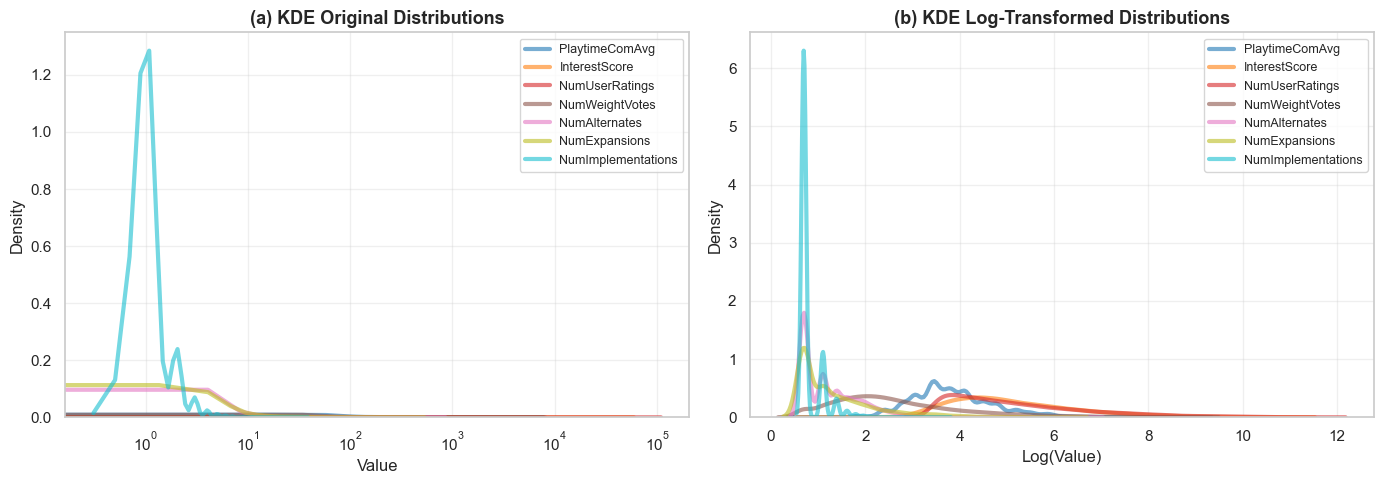

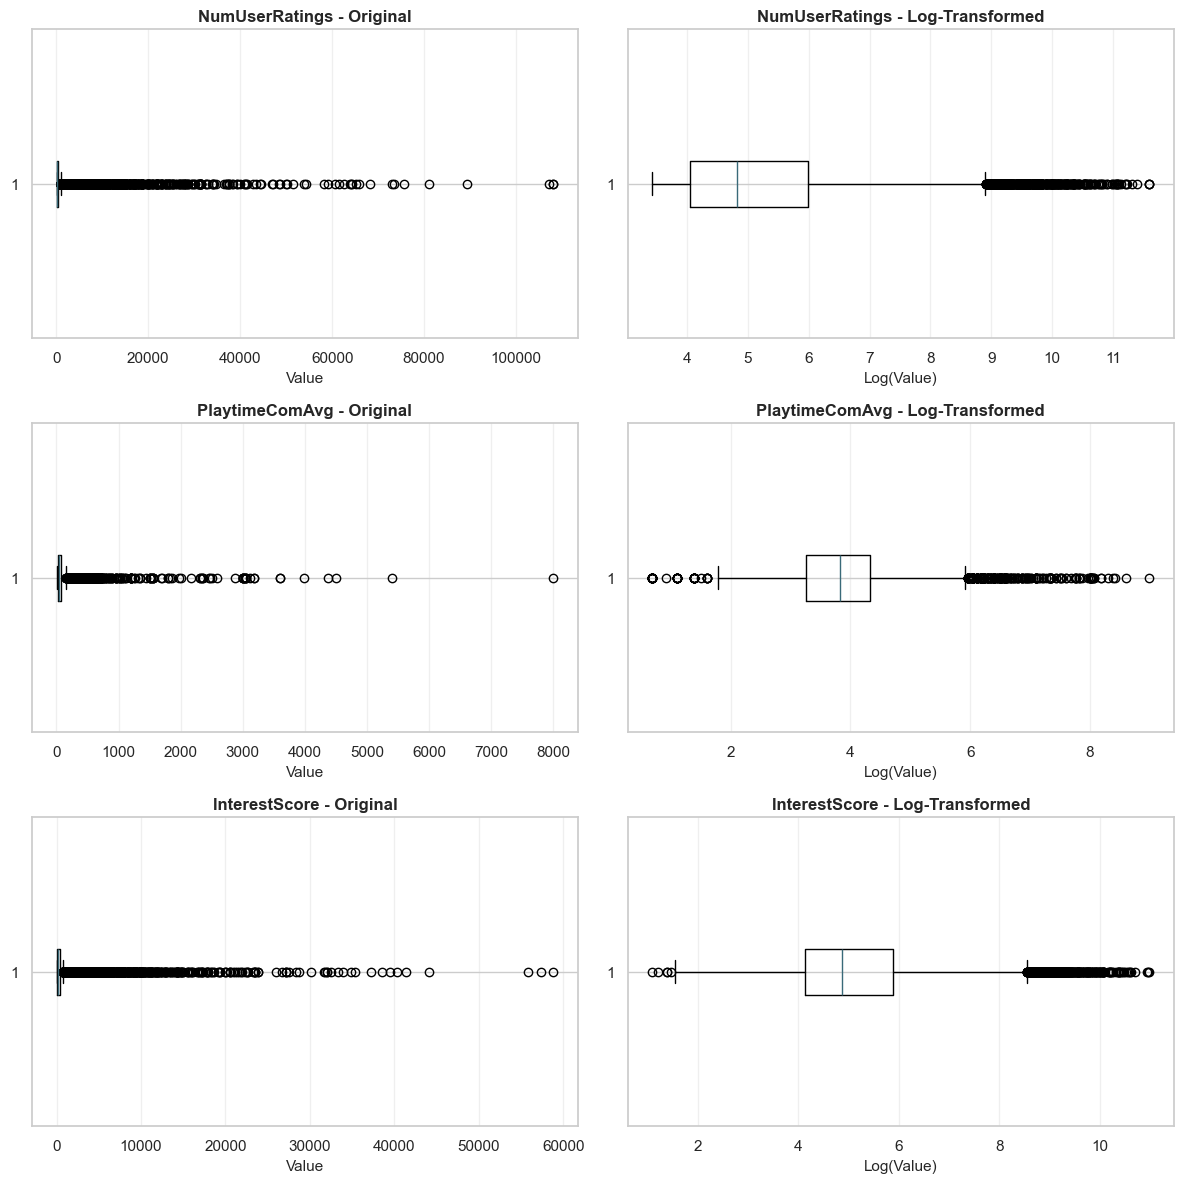

✓ Plots saved: 'kde_comparison.png' and 'boxplot_comparison.png'
✓ Visualized 7 features in KDE plot
✓ Detailed comparison for 3 features in boxplot


In [148]:
features_to_transform = [
    'PlaytimeComAvg', 
    'InterestScore', 
    'NumUserRatings', 
    'NumWeightVotes', 
    'NumAlternates', 
    'NumExpansions', 
    'NumImplementations'
]

# ============================================
# PLOT 1: KDE PLOTS (Before and After Log Transform)
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(features_to_transform)))
# colors = tab10


# Subplot A: Original distributions
for idx, feature in enumerate(features_to_transform):
    if feature in df.columns:
        # Filter out zeros to avoid log(0) issues in visualization
        data = df[df[feature] > 0][feature]
        sns.kdeplot(data, ax=axes[0], label=feature, alpha=0.6, linewidth=3, color=colors[idx])

axes[0].set_xlabel('Value', fontsize=12)
axes[0].set_xscale('log')
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('(a) KDE Original Distributions', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ← NASCONDI minor ticks
axes[0].tick_params(axis='x', which='minor', length=0)  # Lunghezza 0 = invisibili
axes[0].grid(True, which='major', alpha=0.3)

# Subplot B: Log-transformed distributions
for idx, feature in enumerate(features_to_transform):
    if feature in df.columns:
        data = df[df[feature] > 0][feature]
        log_data = np.log1p(data)  # log1p = log(1+x) to handle zeros
        sns.kdeplot(log_data, ax=axes[1], label=feature, alpha=0.6, linewidth=3, color=colors[idx])

axes[1].set_xlabel('Log(Value)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('(b) KDE Log-Transformed Distributions', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('kde_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# PLOT 3: BOXPLOT COMPARISON
# ============================================

# Select 2-3 representative features
selected_features = ['NumUserRatings', 'PlaytimeComAvg', 'InterestScore']

fig, axes = plt.subplots(len(selected_features), 2, figsize=(12, 4*len(selected_features)))

for idx, feature in enumerate(selected_features):
    if feature in df.columns:
        # Original distribution
        data_original = df[df[feature] > 0][feature]
        axes[idx, 0].boxplot(data_original, vert=False)
        axes[idx, 0].set_xlabel('Value', fontsize=11)
        axes[idx, 0].set_title(f'{feature} - Original', fontsize=12, fontweight='bold')
        axes[idx, 0].grid(alpha=0.3, axis='x')
        
        # Log-transformed distribution
        data_log = np.log1p(data_original)
        axes[idx, 1].boxplot(data_log, vert=False)
        axes[idx, 1].set_xlabel('Log(Value)', fontsize=11)
        axes[idx, 1].set_title(f'{feature} - Log-Transformed', fontsize=12, fontweight='bold')
        axes[idx, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('boxplot_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

#print("✓ Plots saved: 'kde_comparison.png' and 'boxplot_comparison.png'")
print(f"✓ Visualized {len(features_to_transform)} features in KDE plot")
print(f"✓ Detailed comparison for {len(selected_features)} features in boxplot")

In [151]:
# # # Transform the dataframe to a CSV file
df.to_csv('official_finaldataset.csv', index=False)